# Curso de Machine Learning 2026
# Parte 2B — Los modelos

Segunda mitad de la Parte 2. La **Parte 2A** dejó los datos preparados y construyó el criterio con
el que se juzga a un modelo: la fuga de información, el sobreajuste y la validación cruzada. Acá se
entrenan seis algoritmos con ese criterio y se los compara.

**Qué necesita para arrancar**

El archivo `datos_modelado.csv` que produjo la **Parte 2A**. No hace falta que lo tengas descargado:
por defecto el cuaderno lo lee del repositorio de GitHub del proyecto, así que se abre y se ejecuta.
El punto 0.2 explica las dos alternativas.

**Qué hace este cuaderno**

1. Recupera el estado que dejó la Parte 2A y lo verifica.
2. Arma la maquinaria de evaluación: un catálogo de modelos, un único bloque de métricas para
   todos y una regla común para ajustar hiperparámetros (punto 7).
3. Entrena y evalúa seis modelos —Regresión Logística, KNN, Árbol de Decisión, Random Forest,
   XGBoost y SVM— con tres tratamientos de escala cada uno (puntos 8 a 13).
4. Los compara en una docena de vistas y arma un ranking, con sus limitaciones a la vista
   (punto 14).

**Una decisión de diseño importante**

El cuaderno está armado para que agregar un modelo nuevo cueste tres líneas y que ese modelo
aparezca automáticamente en todas las tablas y gráficos comparativos del final. El punto 7.5 explica
cómo.

**Las librerías se importan por bloques**, justo antes de la sección que las usa. Este cuaderno carga
solamente las que necesita: varias de las que aparecían en la Parte 2A —`train_test_split`,
`LabelEncoder`, `learning_curve`, `SelectKBest`— eran de las demostraciones de esos puntos y acá no
se usan, así que no están.

---

# Índice — Parte 2B

### Parte 0 — Retomar el estado
- [0.1 Qué necesita este cuaderno](#sec-0-1)
- [0.2 Cargar el archivo de la Parte 2A](#sec-0-2)
- [0.3 Configuración global](#sec-0-3)
- [0.4 Reconstrucción y verificación del estado](#sec-0-4)
- [0.5 Librerías de gráficos y estilo](#sec-0-5)

### 7. La arquitectura del cuaderno
- [7.1 Los escaladores y el esquema de validación](#sec-7-1)
- [7.2 El catálogo de modelos](#sec-7-2)
- [7.3 El cálculo de métricas](#sec-7-3)
- [7.4 El bloque de resultados](#sec-7-4)
- [7.5 Cómo agregar un modelo nuevo](#sec-7-5)
- [7.6 Cómo se ajustan los hiperparámetros](#sec-7-6)

### Los modelos

Todos siguen el mismo orden: presentación, hiperparámetros, optimización y ejecución en el
catálogo. Los que necesitan una búsqueda suman, entre la optimización y el catálogo, el código de
la búsqueda y su resultado.

- [8. Modelo 1 — Regresión Logística](#sec-8) ·
  [8.1](#sec-8-1) Presentación · [8.2](#sec-8-2) Hiperparámetros · [8.3](#sec-8-3) Optimización ·
  [8.4](#sec-8-4) Ejecución en el catálogo
- [9. Modelo 2 — K-Nearest Neighbors](#sec-9) ·
  [9.1](#sec-9-1) Presentación · [9.2](#sec-9-2) Hiperparámetros · [9.3](#sec-9-3) Optimización ·
  [9.4](#sec-9-4) Código de la búsqueda · [9.5](#sec-9-5) Resultado de la búsqueda ·
  [9.6](#sec-9-6) Ejecución en el catálogo
- [10. Modelo 3 — Árbol de Decisión](#sec-10) ·
  [10.1](#sec-10-1) Presentación · [10.2](#sec-10-2) Hiperparámetros · [10.3](#sec-10-3) Optimización ·
  [10.4](#sec-10-4) Código de la búsqueda · [10.5](#sec-10-5) Resultado de la búsqueda ·
  [10.6](#sec-10-6) Ejecución en el catálogo
- [11. Modelo 4 — Random Forest](#sec-11) ·
  [11.1](#sec-11-1) Presentación · [11.2](#sec-11-2) Hiperparámetros · [11.3](#sec-11-3) Optimización ·
  [11.4](#sec-11-4) Ejecución en el catálogo
- [12. Modelo 5 — XGBoost](#sec-12) ·
  [12.1](#sec-12-1) Presentación · [12.2](#sec-12-2) Hiperparámetros · [12.3](#sec-12-3) Optimización ·
  [12.4](#sec-12-4) Código de la búsqueda · [12.5](#sec-12-5) Resultado de la búsqueda ·
  [12.6](#sec-12-6) Ejecución en el catálogo
- [13. Modelo 6 — Máquina de Vectores de Soporte (SVM)](#sec-13) ·
  [13.1](#sec-13-1) Presentación · [13.2](#sec-13-2) Hiperparámetros · [13.3](#sec-13-3) Optimización ·
  [13.4](#sec-13-4) Código de la búsqueda · [13.5](#sec-13-5) Resultado de la búsqueda ·
  [13.6](#sec-13-6) Ejecución en el catálogo

### 14. Comparativa exhaustiva y ranking
- [14.1 Tabla maestra](#sec-14-1)
- [14.2 La mejor variante de cada modelo](#sec-14-2)
- [14.3 Curvas ROC superpuestas](#sec-14-3)
- [14.4 El efecto de la normalización](#sec-14-4)
- [14.5 Estabilidad entre pliegues](#sec-14-5)
- [14.6 Diagnóstico de ajuste comparado](#sec-14-6)
- [14.7 Ranking final](#sec-14-7)
- [14.8 Veredicto y limitaciones](#sec-14-8)

### Cierre
- [Resumen de lo hecho](#sec-cierre)

**Los puntos 1 a 6** —el marco, la transformación de datos, la división del dataset, la fuga de
información, el sobreajuste y la validación cruzada— están en la **Parte 2A**.

---
# Parte 0 — Retomar el estado

<a id="sec-0-1"></a>
## 0.1 Qué necesita este cuaderno

**La entrada:** el archivo `datos_modelado.csv` que dejó la Parte 2A. Tiene 171 filas y nueve
columnas:

| Columna | Qué es |
|---|---|
| `TAG` | La etiqueta original, con las clases `AFI` y `NEG` |
| `T0` … `T6` | Las siete variables predictoras, sin escalar |
| `y` | La misma etiqueta codificada a 0 y 1 |

**Qué se le hizo en la Parte 2A**

  * Revalidada la entrada: sin nulos, sin duplicados, dos clases, rangos posibles
  * Evaluadas y descartadas las variables derivadas
  * **Codificada la etiqueta a 0 y 1**, fijando a mano cuál es la clase positiva
  * Verificado que el escalado no se aplique todavía: va adentro del `Pipeline`

**Qué hay que reconstruir acá.** Un cuaderno nuevo arranca con la memoria vacía: el archivo trae los
datos, pero no las variables de Python ni las decisiones. Hay tres grupos y se recuperan de tres
maneras distintas, que es lo que hacen los puntos 0.2 a 0.4:

| Qué | Cómo se recupera |
|---|---|
| Los datos: `X`, `y`, las clases | **Del archivo.** Se leen y se derivan de sus columnas |
| Las decisiones: semilla, clase positiva, pliegues, umbrales | **Declaradas de nuevo** en el punto 0.3, en una sola celda |
| El esquema de validación: el objeto `cv` | **Reconstruido.** Con la misma semilla y los mismos pliegues sale idéntico al de 6.3 |

Las decisiones se vuelven a escribir en lugar de viajar en un archivo de configuración, y eso tiene
un riesgo: que queden distintas de las de la Parte 2A sin que nadie se dé cuenta. El punto 0.4 lo
controla en lo que se puede controlar —la clase positiva se verifica contra la codificación del
archivo, y el archivo `metadatos_parte2a.txt` guarda los seis valores tal como quedaron allá—.

**Orden de arriba a abajo.** Primero el archivo, después la configuración, después la verificación.
No es caprichoso: la verificación necesita saber cuál se supone que es la clase positiva para poder
comprobarla.

<a id="sec-0-2"></a>
## 0.2 Cargar el archivo de la Parte 2A

Las mismas dos opciones que en la Parte 2A, y por las mismas razones. Todo termina en una variable
`RUTA_DATOS` con la ubicación del archivo.

| | Opción | Cuándo conviene |
|---|---|---|
| **A** | **GitHub** *(activa)* | `datos_modelado.csv` está subido al repositorio. Quien abre el cuaderno no descarga ni sube nada |
| **B** | Subir a mano | Acabás de correr la Parte 2A y bajaste el archivo. Se pierde al reiniciarse la sesión de Colab |

Si corriste la Parte 2A en **esta misma sesión** de Colab, el archivo ya está en el disco de la
máquina virtual y no hace falta ninguna de las dos: la lectura tiene un respaldo que, si la URL
falla, prueba con el archivo local del mismo nombre.

In [4]:
NOMBRE_ARCHIVO = "datos_modelado.csv"   # <-- el que exportó la Parte 2A

# ---------------------------------------------------------------------
# OPCIÓN A — Desde GitHub   (ACTIVA)
# ---------------------------------------------------------------------
USUARIO = "FerCipriani"            # <-- cambiar si usás otro repositorio
REPO    = "CursoML_Proyecto_IVE"   # <-- cambiar si usás otro repositorio
RAMA    = "main"                   # GitHub usa 'main' por defecto desde 2020

RUTA_DATOS = f"https://raw.githubusercontent.com/{USUARIO}/{REPO}/{RAMA}/{NOMBRE_ARCHIVO}"

# ---------------------------------------------------------------------
# OPCIÓN B — Subir el archivo a mano   (solo Colab)
# ---------------------------------------------------------------------
# from google.colab import files
# RUTA_DATOS = list(files.upload().keys())[0]

# print(f"Ruta configurada: {RUTA_DATOS}")

Ahora las librerías de datos y la lectura. Son las únicas dos que necesita todo el cuaderno;
scikit-learn se va importando por partes, en el punto que usa cada pieza.

In [5]:
# --- Librerías de manipulación de datos ---
import numpy as np
import pandas as pd

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print()


# --- Lectura: elige la función según la extensión ---
def leer_datos(ruta):
    if str(ruta).lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(ruta)
    return pd.read_csv(ruta)


try:
    df = leer_datos(RUTA_DATOS)
except Exception as error:
    print(f"[AVISO] No se pudo leer: {RUTA_DATOS}")
    print(f"        {type(error).__name__}: {str(error)[:110]}")
    print(f"        Reintentando con el archivo local '{NOMBRE_ARCHIVO}'...")
    df = leer_datos(NOMBRE_ARCHIVO)
    RUTA_DATOS = NOMBRE_ARCHIVO

print("=" * 70)
print("  LECTURA")
print("=" * 70)
print(f"  Archivo     : {RUTA_DATOS}")
print(f"  Dimensiones : {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"  Columnas    : {list(df.columns)}")
print()
display(df.head())

NumPy  : 2.1.3
Pandas : 2.2.3

  LECTURA
  Archivo     : https://raw.githubusercontent.com/FerCipriani/CursoML_Proyecto_IVE/main/datos_modelado.csv
  Dimensiones : 171 filas x 9 columnas
  Columnas    : ['TAG', 'T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'y']



,TAG,T0,T1,T2,T3,T4,T5,T6,y
0,AFI,0.022825,0.207035,0.381847,0.274705,0.000269,0.113050,0.000269,1
1,AFI,0.006774,0.003968,0.049423,0.176527,0.031185,0.442240,0.289883,1
2,AFI,0.127329,0.000518,0.199793,0.333851,0.025880,0.015010,0.297619,1
3,AFI,0.208518,0.127773,0.090506,0.202307,0.143301,0.000444,0.227152,1
4,AFI,0.000429,0.393822,0.192621,0.270699,0.000429,0.000429,0.141570,1


<a id="sec-0-3"></a>
## 0.3 Configuración global

Los seis valores que la Parte 2A tenía en su punto 0.4, vueltos a declarar acá. **Tienen que
coincidir con los de allá**, y el archivo `metadatos_parte2a.txt` los guarda escritos tal como
quedaron, justamente para poder copiarlos sin depender de la memoria.

| Constante | Qué controla | Qué pasa si no coincide con la Parte 2A |
|---|---|---|
| `SEMILLA` | El azar de los pliegues y de los modelos | Los pliegues salen distintos. Nada se rompe y los resultados de este cuaderno siguen siendo consistentes entre sí, pero no son comparables número a número con los de 6.4 |
| `CLASE_POSITIVA` | Respecto de qué clase se calculan precisión, recall y F1 | **Sí importa, y mucho.** El punto 0.4 lo detecta y avisa |
| `N_PLIEGUES` | En cuántas partes se divide el dataset para evaluar | Cambia la escala de todas las métricas. Es el único parámetro de los pliegues: de acá lo toma todo el cuaderno |
| `BRECHA_SOBREAJUSTE`, `DESVIO_INESTABLE`, `SCORE_SUBAJUSTE` | Los umbrales del diagnóstico automático de ajuste | Cambian los avisos, no las métricas. Están explicados en el punto 5.5 de la Parte 2A |

**Dónde se cambian los pliegues.** Acá y en ningún otro lado. `N_PLIEGUES` alimenta el objeto `cv`
del punto 0.4, los encabezados de las tablas y los títulos de los gráficos; no hay un `5` ni un `10`
escrito en ninguna celda posterior.

In [6]:
# =====================================================================
#  LOS SEIS VALORES QUE TIENEN QUE COINCIDIR CON LA PARTE 2A
#  (están escritos en metadatos_parte2a.txt)
# =====================================================================

# --- Reproducibilidad ---
SEMILLA = 65

# --- El problema ---
CLASE_POSITIVA = "AFI"    # la otra pasa a ser la negativa

# --- Validación cruzada: el ÚNICO lugar donde se elige la cantidad de pliegues ---
N_PLIEGUES = 10

# --- Umbrales del diagnóstico de ajuste (punto 5.5 de la Parte 2A) ---
BRECHA_SOBREAJUSTE = 0.10   # score entrenamiento - score validación por encima de esto
DESVIO_INESTABLE   = 0.08   # desvío entre pliegues por encima de esto
SCORE_SUBAJUSTE    = 0.70   # score de validación por debajo de esto

# --- Formato de la salida ---
import warnings
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
warnings.filterwarnings("ignore")

print("Configuración cargada.")
print(f"  Semilla           : {SEMILLA}")
print(f"  Clase positiva    : {CLASE_POSITIVA}")
print(f"  Pliegues (K-Fold) : {N_PLIEGUES}")
print(f"  Umbral sobreajuste: {BRECHA_SOBREAJUSTE}")
print(f"  Umbral desvío     : {DESVIO_INESTABLE}")
print(f"  Umbral subajuste  : {SCORE_SUBAJUSTE}")

Configuración cargada.
  Semilla           : 65
  Clase positiva    : AFI
  Pliegues (K-Fold) : 10
  Umbral sobreajuste: 0.1
  Umbral desvío     : 0.08
  Umbral subajuste  : 0.7


<a id="sec-0-4"></a>
## 0.4 Reconstrucción y verificación del estado

Acá se rearman las variables que el resto del cuaderno da por existentes, y se comprueba que el
archivo sea el que se espera. Son ocho controles; los dos primeros son los que de verdad pueden
fallar:

1. **Están las dos columnas de la etiqueta**, `TAG` y `y`. Si falta alguna, el archivo no es el que
   exportó la Parte 2A.
2. **La codificación coincide con `CLASE_POSITIVA`.** Se compara fila por fila que `y == 1` sea
   exactamente donde `TAG == CLASE_POSITIVA`. Es la verificación que justifica que el CSV lleve la
   etiqueta dos veces: detecta el único error de configuración que produciría métricas plausibles y
   equivocadas.
3. Las predictoras son **todas las columnas que no son la etiqueta**, y todas numéricas.
4. Sin valores faltantes, sin duplicados, exactamente dos clases, rangos posibles.

Y al final se reconstruye el objeto `cv`. No viaja en ningún archivo porque no hace falta: un
`StratifiedKFold` con la misma semilla y la misma cantidad de pliegues produce **exactamente** las
mismas particiones. Es el mismo esquema del punto 6.3 de la Parte 2A, y la tabla de abajo lo imprime
pliegue por pliegue para poder compararlo con el de allá.

También se recalcula la **línea de base**: el porcentaje que se acierta respondiendo siempre la clase
mayoritaria. Es el número que cualquier modelo tiene que superar para justificar su existencia, y el
punto 14 lo usa como referencia.

In [7]:
from sklearn.model_selection import StratifiedKFold

print("=" * 78)
print("  RECONSTRUCCIÓN Y VERIFICACIÓN DEL ESTADO")
print("=" * 78)

objetivo           = "TAG"   # la etiqueta original, en texto
COLUMNA_CODIFICADA = "y"     # la misma etiqueta en 0/1, que dejó el punto 2.2

problemas = []

# 1. ¿Están las dos columnas de la etiqueta?
faltantes = [c for c in (objetivo, COLUMNA_CODIFICADA) if c not in df.columns]
if faltantes:
    problemas.append(f"faltan las columnas {faltantes}")
    print(f"  [ERROR] Faltan las columnas {faltantes}. Columnas leídas: {list(df.columns)}")
    print("          ¿Es el archivo que exportó la Parte 2A?")
else:
    print(f"  [OK] Columnas de la etiqueta presentes: '{objetivo}' y '{COLUMNA_CODIFICADA}'")

# 2. Las predictoras: todo lo que no es la etiqueta
predictoras = [c for c in df.columns
               if c not in (objetivo, COLUMNA_CODIFICADA)
               and pd.api.types.is_numeric_dtype(df[c])]
no_numericas = [c for c in df.columns
                if c not in (objetivo, COLUMNA_CODIFICADA) and c not in predictoras]
print(f"  [OK] Variables predictoras numéricas: {len(predictoras)}  ->  {predictoras}")
if no_numericas:
    problemas.append(f"columnas no numéricas fuera de la etiqueta: {no_numericas}")
    print(f"  [AVISO] Columnas no numéricas que quedan fuera: {no_numericas}")

# 3. Nulos y duplicados
nulos = int(df.isna().sum().sum())
if nulos:
    problemas.append(f"{nulos} valores faltantes")
    print(f"  [ERROR] Hay {nulos} valores faltantes. Volvé a la Parte 2A.")
else:
    print("  [OK] Sin valores faltantes")

duplicados = int(df.duplicated().sum())
print(f"  [{'AVISO' if duplicados else 'OK'}] "
      f"{'Hay ' + str(duplicados) + ' filas duplicadas' if duplicados else 'Sin filas duplicadas'}")

# 4. Clases
clases = sorted(df[objetivo].astype(str).unique())
if len(clases) != 2:
    problemas.append(f"la etiqueta tiene {len(clases)} clases, no 2")
    print(f"  [ERROR] La etiqueta tiene {len(clases)} clases: {clases}")
    print("          Este cuaderno está armado para clasificación BINARIA.")
else:
    print(f"  [OK] Clasificación binaria: {clases}")

# 5. LA VERIFICACIÓN QUE IMPORTA: la codificación contra CLASE_POSITIVA
if CLASE_POSITIVA not in clases:
    problemas.append(f"CLASE_POSITIVA='{CLASE_POSITIVA}' no está entre las clases {clases}")
    print(f"  [ERROR] CLASE_POSITIVA = '{CLASE_POSITIVA}' no existe en los datos: {clases}")
    clase_negativa = clases[0]
else:
    clase_negativa = [c for c in clases if c != CLASE_POSITIVA][0]
    coincide = bool(((df[objetivo] == CLASE_POSITIVA) == (df[COLUMNA_CODIFICADA] == 1)).all())
    if coincide:
        print(f"  [OK] La codificación del archivo coincide con la configuración:")
        print(f"       {CLASE_POSITIVA} -> 1 (positiva),  {clase_negativa} -> 0 (negativa)")
    else:
        problemas.append("la codificación del archivo está invertida respecto de CLASE_POSITIVA")
        print(f"  [ERROR] En el archivo, '{CLASE_POSITIVA}' NO está codificada como 1.")
        print(f"          Corregí CLASE_POSITIVA en el punto 0.3, o volvé a exportar")
        print(f"          desde la Parte 2A. Si no, precisión, recall y F1 van a")
        print(f"          reportarse respecto de la clase equivocada.")

# 6. Las matrices
X = df[predictoras].copy()
y = df[COLUMNA_CODIFICADA].astype(int)

minimo = X.to_numpy().min()
maximo = X.to_numpy().max()
print(f"  [OK] Rango de las predictoras: {minimo:.6f} a {maximo:.6f}  (SIN escalar)")
if np.allclose(X.sum(axis=1), 1.0, atol=1e-6):
    print("  [OK] Las filas suman 1: las variables son proporciones de un total fijo")

print()
if problemas:
    print(f"  RESULTADO: {len(problemas)} problema(s) -> {problemas}")
    print("  Revisá la Parte 2A antes de seguir.")
else:
    print("  RESULTADO: el estado se reconstruyó sin problemas. Se puede modelar.")

# --- Reparto de clases y línea de base ---
print()
print("  REPARTO DE CLASES")
print("  " + "-" * 74)
conteo = df[objetivo].value_counts()
proporcion = df[objetivo].value_counts(normalize=True)
for clase in conteo.index:
    print(f"    {clase:>5} : {conteo[clase]:>4} casos ({proporcion[clase]:.1%})")
linea_base = proporcion.max()
clase_mayoritaria = proporcion.idxmax()
print(f"  LÍNEA DE BASE: {linea_base:.2%}  (responder siempre '{clase_mayoritaria}')")

# --- El esquema de validación, idéntico al del punto 6.3 de la Parte 2A ---
cv = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)

print()
print(f"  ESQUEMA DE VALIDACIÓN: StratifiedKFold con {N_PLIEGUES} pliegues, "
      f"semilla {SEMILLA}")
print("  " + "-" * 74)
print(f"  {'Pliegue':>8} {'Entrena':>9} {'Prueba':>8} {'% pos. entrena':>16} {'% pos. prueba':>15}")
for i, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    print(f"  {i:>8} {len(idx_tr):>9} {len(idx_te):>8} "
          f"{y.iloc[idx_tr].mean():>15.1%} {y.iloc[idx_te].mean():>15.1%}")
print()
print(f"  Proporción de la clase positiva en el dataset completo: {y.mean():.1%}")
print("  Si esta tabla es igual a la del punto 6.3 de la Parte 2A, la semilla y los")
print("  pliegues coinciden y los resultados de los dos cuadernos son comparables.")
print()
print(f"  X : {X.shape[0]} filas x {X.shape[1]} columnas")
print(f"  y : {len(y)} etiquetas  ->  {int((y == 1).sum())} de clase 1 ({CLASE_POSITIVA}), "
      f"{int((y == 0).sum())} de clase 0 ({clase_negativa})")

  RECONSTRUCCIÓN Y VERIFICACIÓN DEL ESTADO
  [OK] Columnas de la etiqueta presentes: 'TAG' y 'y'
  [OK] Variables predictoras numéricas: 7  ->  ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']
  [OK] Sin valores faltantes
  [OK] Sin filas duplicadas
  [OK] Clasificación binaria: ['AFI', 'NEG']
  [OK] La codificación del archivo coincide con la configuración:
       AFI -> 1 (positiva),  NEG -> 0 (negativa)
  [OK] Rango de las predictoras: 0.000120 a 0.714286  (SIN escalar)
  [OK] Las filas suman 1: las variables son proporciones de un total fijo

  RESULTADO: el estado se reconstruyó sin problemas. Se puede modelar.

  REPARTO DE CLASES
  --------------------------------------------------------------------------
      AFI :   95 casos (55.6%)
      NEG :   76 casos (44.4%)
  LÍNEA DE BASE: 55.56%  (responder siempre 'AFI')

  ESQUEMA DE VALIDACIÓN: StratifiedKFold con 10 pliegues, semilla 65
  --------------------------------------------------------------------------
   Pliegue   Entrena   P

<a id="sec-0-5"></a>
## 0.5 Librerías de gráficos y estilo

El mismo bloque que la Parte 2A, con los mismos colores por clase. Que `AFI` sea siempre azul y
`NEG` siempre rojo en los dos cuadernos no es decoración: hace que dos gráficos de partes distintas
se puedan comparar de un vistazo sin volver a leer la leyenda.

In [8]:
# --- Librerías de gráficos ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- Estilo global ---
sns.set_theme(style="whitegrid", palette="deep")
mpl.rcParams["figure.figsize"] = (10, 5)
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["font.size"] = 10

# --- Colores fijos ---
COLOR_CLASE = {"AFI": "#1f77b4", "NEG": "#d62728"}

print(f"Matplotlib : {mpl.__version__}")
print(f"Seaborn    : {sns.__version__}")
print()
print("Colores por clase:", COLOR_CLASE)

Matplotlib : 3.10.0
Seaborn    : 0.13.2

Colores por clase: {'AFI': '#1f77b4', 'NEG': '#d62728'}


---
# 7. La arquitectura del cuaderno

Vamos a evaluar 6 modelos con tres escalados cada uno. Son 18 combinaciones, cada una con una docena de métricas y media docena de gráficos.

Escribir eso a mano sería tedioso y cualquier ajuste habría que replicarlo en todos lados, y a la primera distracción dos modelos quedarían evaluados con criterios distintos —con lo cual la comparación final no valdría nada—.

La solución es separar **qué modelos se evalúan** de **cómo se los evalúa**:

```
CATALOGO_MODELOS  ──►  evaluar_modelo()  ──►  RESULTADOS  ──►  comparativa (punto 14)
  (una entrada          (el mismo             (tabla que        (lee de RESULTADOS,
   por modelo)          procedimiento          se va             sin saber cuántos
                        para todos)            llenando)          modelos hay)
```

Las tres consecuencias que importan:

1. **Todos los modelos se miden con exactamente el mismo código.** No hay forma de que uno quede
   evaluado con un criterio distinto.
2. **Agregar un modelo cuesta una entrada en el catálogo.**.
3. **La comparativa final lo toma solo.** No hay ninguna lista de modelos escrita a mano en el punto 14.

Los puntos 7.1 a 7.4 construyen esa maquinaria, el 7.5 explica cómo sumar un modelo y el 7.6 fija
la regla con la que se ajustan los hiperparámetros. Es la parte más compleja del cuaderno; a partir
del punto 8 todo se vuelve repetitivo.

<a id="sec-7-1"></a>
## 7.1 Los escaladores y el esquema de validación

Definimos los tres tratamientos de escala que vamos a comparar. El esquema de validación cruzada `cv` quedó armado en el punto 0.4, reproduciendo exactamente el del punto 6.3 de la Parte 2A.

Que sea **el mismo objeto `cv`** para todos no es un detalle: garantiza que los pliegues sean idénticos en todas las evaluaciones, y por lo tanto que las diferencias entre modelos se deban a los modelos y no a que a uno le tocó una partición más fácil.

In [9]:
# Los escaladores: en la Parte 2A se importaron en 2.3, acá se usan en serio
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Los tres tratamientos de escala a comparar
ESCALADORES = {
    "Sin escalar": None,
    "Min-Max":     MinMaxScaler(),
    "Z-score":     StandardScaler(),
}

# Métricas que se calculan en cada pliegue, para el diagnóstico de ajuste
METRICAS_CV = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
}

print("Escaladores a comparar :", list(ESCALADORES.keys()))
print(f"Validación cruzada     : StratifiedKFold({N_PLIEGUES}, shuffle=True, "
      f"random_state={SEMILLA})")
print("Métricas por pliegue   :", list(METRICAS_CV.keys()))
print()
print("El mismo objeto cv para todos los modelos: los pliegues son idénticos en")
print("todas las evaluaciones, así que las diferencias son atribuibles al modelo.")

Escaladores a comparar : ['Sin escalar', 'Min-Max', 'Z-score']
Validación cruzada     : StratifiedKFold(10, shuffle=True, random_state=65)
Métricas por pliegue   : ['accuracy', 'f1_macro', 'roc_auc']

El mismo objeto cv para todos los modelos: los pliegues son idénticos en
todas las evaluaciones, así que las diferencias son atribuibles al modelo.


<a id="sec-7-2"></a>
## 7.2 El catálogo de modelos

El catálogo es un diccionario donde cada entrada describe un modelo. Los campos:

| Campo | Qué es |
|---|---|
| `estimador` | El objeto de scikit-learn, sin entrenar |
| `escalados` | Qué tratamientos de escala probarle. Los árboles no lo necesitan, pero se lo aplicamos igual para *verificar* que efectivamente no cambia nada |
| `color` | Un color fijo, para que el modelo se reconozca en todos los gráficos |
| `nota` | Una línea que recuerda qué representa ese modelo |
| `grafico_extra` | Opcional: una función que dibuja algo propio del modelo (coeficientes, importancias, el árbol). Si es `None`, no se dibuja nada |
| `busqueda` | Opcional: el resultado de la búsqueda de hiperparámetros del punto 7.6, si el modelo pasó por una. Si es `None`, el modelo usa valores fijos |
| `ajustado` | Se completa solo: `True` si el modelo pasó por una búsqueda. Esa marca viaja hasta la comparativa del punto 14 |

`RESULTADOS` es la lista donde se acumulan las métricas de cada combinación, y `PREDICCIONES`
guarda las probabilidades predichas de cada una, que el punto 14 necesita para superponer las
curvas ROC.

`construir_pipeline()` es la función que arma el `Pipeline` del punto 4.6 de la Parte 2A: escalador —si
corresponde— más modelo. **Ningún modelo de este cuaderno se evalúa fuera de un pipeline.**

In [10]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline

CATALOGO_MODELOS = {}      # nombre -> configuración
RESULTADOS = []            # una fila por (modelo, escalado)
PREDICCIONES = {}          # (modelo, escalado) -> predicciones y detalle


def registrar_modelo(nombre, estimador, escalados=None, color="#4c72b0",
                     nota="", grafico_extra=None, busqueda=None):
    CATALOGO_MODELOS[nombre] = {
        "estimador": estimador,
        "escalados": escalados if escalados is not None else list(ESCALADORES.keys()),
        "color": color,
        "nota": nota,
        "grafico_extra": grafico_extra,
        "busqueda": busqueda,
        "ajustado": busqueda is not None,
    }
    print(f"Registrado: {nombre}")
    print(f"    escalados a probar : {CATALOGO_MODELOS[nombre]['escalados']}")
    if busqueda is not None:
        print(f"    hiperparámetros    : {busqueda['elegidos']}  (búsqueda del punto 7.6)")
    else:
        print("    hiperparámetros    : fijos, sin búsqueda")
    if nota:
        print(f"    {nota}")


def construir_pipeline(nombre_modelo, nombre_escalado):
    # Arma el Pipeline: escalador (si corresponde) + modelo.
    # Se clona todo para que cada combinación entrene su propia copia limpia.
    pasos = []
    escalador = ESCALADORES[nombre_escalado]
    if escalador is not None:
        pasos.append(("escalador", clone(escalador)))
    pasos.append(("modelo", clone(CATALOGO_MODELOS[nombre_modelo]["estimador"])))
    return Pipeline(pasos)


print("Catálogo inicializado (vacío).")

Catálogo inicializado (vacío).


<a id="sec-7-3"></a>
## 7.3 El cálculo de métricas

Acá se define, de una vez y para siempre, **qué se mide**. Estas dos funciones son las que hacen
que los seis modelos sean comparables.

**`calcular_metricas()`** recibe las etiquetas reales, las predichas y las probabilidades, y
devuelve un diccionario con todo. Agrupadas por lo que responden:

*Rendimiento general*
- **Accuracy** — proporción de aciertos sobre el total. Intuitiva, pero engañosa si las clases
  están desbalanceadas.
- **Balanced accuracy** — el promedio del recall de cada clase. Corrige ese sesgo.

*Rendimiento sobre la clase positiva*
- **Precisión** — de los que predije positivos, cuántos lo eran.
- **Recall** — de los que realmente eran positivos, cuántos detecté.
- **F1-score** — la media armónica de las dos anteriores. Si una es baja, el F1 es bajo.
- **F1 macro** — el promedio simple del F1 de cada clase; trata a las dos por igual.

*Calidad del ordenamiento (sin depender del umbral)*
- **ROC-AUC** — la probabilidad de que el modelo le asigne mayor puntaje a un caso positivo tomado
  al azar que a uno negativo. 0,5 es azar puro, 1 es perfecto.
- **Average precision** — el área bajo la curva precisión-recall. Más informativa que el AUC cuando
  la clase positiva es minoritaria.

*Acuerdo corregido por azar*
- **Coeficiente de Matthews (MCC)** — considera las cuatro celdas de la matriz de confusión. Va de
  -1 a +1 y es la métrica más honesta con clases desbalanceadas.
- **Kappa de Cohen** — mide el acuerdo descontando el que se lograría por azar.

*Calidad de las probabilidades*
- **Log loss** — castiga las predicciones seguras y equivocadas. **Más bajo es mejor**.
- **Brier score** — el error cuadrático medio de las probabilidades. **Más bajo es mejor**. Un modelo puede clasificar bien y estimar mal las probabilidades; estas dos lo detectan.

**`diagnosticar_ajuste()`** aplica lo del punto 5 de la Parte 2A: compara el rendimiento en entrenamiento contra
el de validación, mira el desvío entre pliegues y emite el veredicto, usando los umbrales que
declaramos en el punto 0.3.

In [12]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss,
)


def calcular_metricas(y_real, y_pred, y_proba):
    return {
        # Rendimiento general
        "accuracy":          accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        # Clase positiva
        "precision":         precision_score(y_real, y_pred, zero_division=0),
        "recall":            recall_score(y_real, y_pred, zero_division=0),
        "f1":                f1_score(y_real, y_pred, zero_division=0),
        # Promediadas entre clases
        "precision_macro":   precision_score(y_real, y_pred, average="macro", zero_division=0),
        "recall_macro":      recall_score(y_real, y_pred, average="macro", zero_division=0),
        "f1_macro":          f1_score(y_real, y_pred, average="macro", zero_division=0),
        "f1_weighted":       f1_score(y_real, y_pred, average="weighted", zero_division=0),
        # Independientes del umbral
        "roc_auc":           roc_auc_score(y_real, y_proba),
        "average_precision": average_precision_score(y_real, y_proba),
        # Corregidas por azar
        "mcc":               matthews_corrcoef(y_real, y_pred),
        "kappa":             cohen_kappa_score(y_real, y_pred),
        # Calidad de las probabilidades
        "log_loss":          log_loss(y_real, np.clip(y_proba, 1e-12, 1 - 1e-12)),
        "brier":             brier_score_loss(y_real, y_proba),
    }


def diagnosticar_ajuste(score_entrena, score_valida, desvio_valida):
    brecha = score_entrena - score_valida
    avisos = []

    if brecha > BRECHA_SOBREAJUSTE:
        avisos.append(
            f"SOBREAJUSTE: la brecha entre entrenamiento ({score_entrena:.4f}) y "
            f"validación ({score_valida:.4f}) es de {brecha:.4f}, por encima del umbral "
            f"de {BRECHA_SOBREAJUSTE:.2f}. El modelo memoriza más de lo que generaliza."
        )
    elif brecha > BRECHA_SOBREAJUSTE / 2:
        avisos.append(
            f"Sobreajuste leve: brecha de {brecha:.4f}. Todavía tolerable, pero conviene "
            f"no aumentar la complejidad del modelo."
        )

    if score_valida < SCORE_SUBAJUSTE:
        avisos.append(
            f"SUBAJUSTE: el rendimiento en validación ({score_valida:.4f}) está por debajo "
            f"de {SCORE_SUBAJUSTE:.2f}. El modelo puede ser demasiado simple para el problema."
        )

    if desvio_valida > DESVIO_INESTABLE:
        avisos.append(
            f"INESTABILIDAD: el desvío entre pliegues es {desvio_valida:.4f}, por encima de "
            f"{DESVIO_INESTABLE:.2f}. El rendimiento depende mucho de qué datos le toquen; "
            f"la media es poco confiable."
        )

    if not avisos:
        avisos.append(
            f"AJUSTE CORRECTO: brecha de {brecha:.4f} y desvío entre pliegues de "
            f"{desvio_valida:.4f}, los dos dentro de lo aceptable. El modelo generaliza bien."
        )

    return brecha, avisos


ejemplo_metricas = calcular_metricas(np.array([0, 1]), np.array([0, 1]), np.array([0.1, 0.9]))
print(f"Funciones definidas. calcular_metricas() devuelve {len(ejemplo_metricas)} métricas:")
for clave in ejemplo_metricas:
    print(f"    {clave}")

Funciones definidas. calcular_metricas() devuelve 15 métricas:
    accuracy
    balanced_accuracy
    precision
    recall
    f1
    precision_macro
    recall_macro
    f1_macro
    f1_weighted
    roc_auc
    average_precision
    mcc
    kappa
    log_loss
    brier


<a id="sec-7-4"></a>
## 7.4 El bloque de resultados

`evaluar_modelo()` es el corazón del cuaderno. Es **el mismo procedimiento para todos los
modelos**, y lo que hace, en orden:

1. Para cada escalado registrado, arma el `Pipeline` y lo evalúa con validación cruzada.
2. Obtiene las predicciones **fuera de pliegue** con `cross_val_predict`: cada caso se predice con
   un modelo que no lo vio durante su entrenamiento. Así las métricas y la matriz de confusión se
   calculan sobre las 171 filas, pero sin fuga.
3. Corre `cross_validate` con `return_train_score=True` para tener el rendimiento en entrenamiento
   y en validación pliegue por pliegue, que es lo que alimenta el diagnóstico del punto 5 de la Parte 2A.
4. Guarda todo en `RESULTADOS` y `PREDICCIONES`, con la marca de si el modelo pasó por una
   búsqueda de hiperparámetros (punto 7.6).
5. Imprime la tabla comparativa de los escalados, elige el mejor por ROC-AUC y, sobre esa variante,
   despliega el bloque completo: métricas detalladas, diagnóstico de ajuste, reporte de
   clasificación y seis gráficos.
6. Si el modelo trae un `grafico_extra`, lo dibuja al final, claramente separado del bloque común.

**Sobre `cross_val_predict`.** Es lo que permite tener una matriz de confusión con los 171 casos en
lugar de con los 34 de una única partición de prueba. Cada predicción proviene de un modelo que no
vio ese caso, así que sigue siendo una estimación honesta.

In [13]:
from sklearn.model_selection import cross_val_predict, cross_validate

def evaluar_modelo(nombre, mostrar_graficos=True):
    configuracion = CATALOGO_MODELOS[nombre]
    color_modelo = configuracion["color"]

    print("=" * 88)
    print(f"  {nombre.upper()}")
    if configuracion["nota"]:
        print(f"  {configuracion['nota']}")
    print("=" * 88)

    filas_modelo = []

    # ---------- 1. Evaluar cada escalado ----------
    for nombre_escalado in configuracion["escalados"]:
        pipeline = construir_pipeline(nombre, nombre_escalado)

        y_pred = cross_val_predict(pipeline, X, y, cv=cv, method="predict")
        # a probabilidad predicha de pertenecer a la clase positiva (1) para cada observación.
        y_proba = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]

        metricas = calcular_metricas(y, y_pred, y_proba)

        detalle = cross_validate(pipeline, X, y, cv=cv, scoring=METRICAS_CV,
                                 return_train_score=True, n_jobs=1)

        for clave in METRICAS_CV:
            metricas[f"cv_{clave}_entrena"] = detalle[f"train_{clave}"].mean()
            metricas[f"cv_{clave}_media"] = detalle[f"test_{clave}"].mean()
            metricas[f"cv_{clave}_desvio"] = detalle[f"test_{clave}"].std()
            metricas[f"cv_{clave}_min"] = detalle[f"test_{clave}"].min()
            metricas[f"cv_{clave}_max"] = detalle[f"test_{clave}"].max()

        brecha, avisos = diagnosticar_ajuste(
            metricas["cv_f1_macro_entrena"],
            metricas["cv_f1_macro_media"],
            metricas["cv_f1_macro_desvio"],
        )
        metricas["brecha_ajuste"] = brecha
        metricas["diagnostico"] = avisos[0].split(":")[0]

        fila = {"modelo": nombre, "escalado": nombre_escalado, "color": color_modelo,
                "ajustado": configuracion["ajustado"]}
        fila.update(metricas)
        filas_modelo.append(fila)

        RESULTADOS.append(fila)
        PREDICCIONES[(nombre, nombre_escalado)] = {
            "y_pred": y_pred, "y_proba": y_proba,
            "por_pliegue": detalle, "avisos": avisos,
        }

    tabla_modelo = pd.DataFrame(filas_modelo)

    # ---------- 2. Comparación de escalados ----------
    print()
    print("  EFECTO DEL ESCALADO")
    print("  " + "-" * 84)
    resumen_escalado = tabla_modelo[[
        "escalado", "accuracy", "balanced_accuracy", "f1_macro",
        "roc_auc", "cv_f1_macro_desvio", "brecha_ajuste",
    ]].rename(columns={"cv_f1_macro_desvio": "desvio_pliegues", "brecha_ajuste": "brecha"})
    display(resumen_escalado.set_index("escalado"))

    rango_auc = tabla_modelo["roc_auc"].max() - tabla_modelo["roc_auc"].min()
    if rango_auc < 1e-9:
        print("  El escalado NO cambia absolutamente nada en este modelo.")
        print("  Es lo esperado en modelos basados en árboles: los cortes se hacen por")
        print("  umbrales, y Min-Max y Z-score son transformaciones monótonas que no")
        print("  alteran el orden de los valores, así que los cortes caen en el mismo lugar.")
    else:
        print(f"  Diferencia entre el mejor y el peor escalado (ROC-AUC): {rango_auc:.4f}")

    # ---------- 3. La mejor variante ----------
    mejor = tabla_modelo.sort_values("roc_auc", ascending=False).iloc[0]
    escalado_elegido = mejor["escalado"]
    guardado = PREDICCIONES[(nombre, escalado_elegido)]
    y_pred = guardado["y_pred"]
    y_proba = guardado["y_proba"]
    detalle = guardado["por_pliegue"]

    print()
    print(f"  MEJOR VARIANTE: {nombre} + {escalado_elegido}")
    print("  " + "=" * 84)

    # ---------- 4. Métricas detalladas ----------
    print()
    print("  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)")
    print("  " + "-" * 84)
    bloques = [
        ("Rendimiento general", [
            ("Accuracy", "accuracy", "proporción de aciertos sobre el total"),
            ("Balanced accuracy", "balanced_accuracy", "promedio del recall de cada clase"),
        ]),
        (f"Clase positiva ({CLASE_POSITIVA})", [
            ("Precisión", "precision", "de los predichos positivos, cuántos lo eran"),
            ("Recall", "recall", "de los positivos reales, cuántos detectó"),
            ("F1-score", "f1", "media armónica de precisión y recall"),
        ]),
        ("Promediadas entre clases", [
            ("Precisión macro", "precision_macro", "promedio simple entre clases"),
            ("Recall macro", "recall_macro", "promedio simple entre clases"),
            ("F1 macro", "f1_macro", "trata a las dos clases por igual"),
            ("F1 ponderado", "f1_weighted", "pondera por la frecuencia de cada clase"),
        ]),
        ("Independientes del umbral", [
            ("ROC-AUC", "roc_auc", "capacidad de ordenar; 0,5 = azar"),
            ("Average precision", "average_precision", "área bajo la curva precisión-recall"),
        ]),
        ("Corregidas por azar", [
            ("Matthews (MCC)", "mcc", "de -1 a +1; usa las cuatro celdas"),
            ("Kappa de Cohen", "kappa", "acuerdo descontando el azar"),
        ]),
        ("Calidad de las probabilidades", [
            ("Log loss", "log_loss", "más bajo es mejor"),
            ("Brier score", "brier", "más bajo es mejor"),
        ]),
    ]
    for titulo, items in bloques:
        print(f"    {titulo}")
        for etiqueta, clave, ayuda in items:
            print(f"      {etiqueta:<20} {mejor[clave]:>8.4f}    {ayuda}")

    # ---------- 5. Diagnóstico de ajuste ----------
    print()
    print("  DIAGNÓSTICO DE AJUSTE  (F1 macro por pliegue)")
    print("  " + "-" * 84)
    print(f"    {'Pliegue':>8} {'Entrenamiento':>15} {'Validación':>13} {'Brecha':>10}")
    for i, (tr, te) in enumerate(zip(detalle["train_f1_macro"], detalle["test_f1_macro"]), 1):
        print(f"    {i:>8} {tr:>15.4f} {te:>13.4f} {tr - te:>10.4f}")
    print(f"    {'MEDIA':>8} {detalle['train_f1_macro'].mean():>15.4f} "
          f"{detalle['test_f1_macro'].mean():>13.4f} "
          f"{detalle['train_f1_macro'].mean() - detalle['test_f1_macro'].mean():>10.4f}")
    print(f"    {'DESVÍO':>8} {detalle['train_f1_macro'].std():>15.4f} "
          f"{detalle['test_f1_macro'].std():>13.4f}")
    print()
    print(f"    Estimación final: F1 macro = {detalle['test_f1_macro'].mean():.4f} "
          f"± {detalle['test_f1_macro'].std():.4f}")
    print(f"    Rango entre pliegues: {detalle['test_f1_macro'].min():.4f} a "
          f"{detalle['test_f1_macro'].max():.4f}")
    print()
    for aviso in guardado["avisos"]:
        print(f"    >> {aviso}")

    # ---------- 6. Reporte de clasificación ----------
    print()
    print("  REPORTE DE CLASIFICACIÓN")
    print("  " + "-" * 84)
    print(classification_report(
        y, y_pred,
        target_names=[f"{clase_negativa} (0)", f"{CLASE_POSITIVA} (1)"],
        digits=4, zero_division=0,
    ))

    if not mostrar_graficos:
        return tabla_modelo

    # ---------- 7. Gráficos ----------
    fig = plt.figure(figsize=(16, 9.5))
    rejilla = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.28)

    # (a) Matriz de confusión, conteos
    eje = fig.add_subplot(rejilla[0, 0])
    matriz = confusion_matrix(y, y_pred)
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=[clase_negativa, CLASE_POSITIVA],
                yticklabels=[clase_negativa, CLASE_POSITIVA], ax=eje,
                annot_kws={"size": 15, "weight": "bold"})
    eje.set_xlabel("predicho"); eje.set_ylabel("real")
    eje.set_title("Matriz de confusión (casos)")
    vn, fp, fn, vp = matriz.ravel()
    eje.text(0.5, -0.30, f"VN={vn}  FP={fp}  FN={fn}  VP={vp}",
             transform=eje.transAxes, ha="center", fontsize=9, style="italic")

    # (b) Matriz normalizada
    eje = fig.add_subplot(rejilla[0, 1])
    matriz_norm = confusion_matrix(y, y_pred, normalize="true")
    sns.heatmap(matriz_norm, annot=True, fmt=".2%", cmap="Greens", cbar=False, square=True,
                xticklabels=[clase_negativa, CLASE_POSITIVA],
                yticklabels=[clase_negativa, CLASE_POSITIVA], ax=eje,
                annot_kws={"size": 12, "weight": "bold"})
    eje.set_xlabel("predicho"); eje.set_ylabel("real")
    eje.set_title("Matriz normalizada por clase real")

    # (c) Curva ROC
    eje = fig.add_subplot(rejilla[0, 2])
    fpr, tpr, _ = roc_curve(y, y_proba)
    eje.plot(fpr, tpr, color=color_modelo, linewidth=2.4,
             label=f"AUC = {mejor['roc_auc']:.4f}")
    eje.fill_between(fpr, tpr, alpha=0.12, color=color_modelo)
    eje.plot([0, 1], [0, 1], "k--", linewidth=1, label="azar (AUC = 0,5)")
    eje.set_xlabel("tasa de falsos positivos")
    eje.set_ylabel("tasa de verdaderos positivos")
    eje.set_title("Curva ROC")
    eje.legend(loc="lower right", fontsize=9)

    # (d) Curva precisión-recall
    eje = fig.add_subplot(rejilla[1, 0])
    prec, rec, _ = precision_recall_curve(y, y_proba)
    eje.plot(rec, prec, color=color_modelo, linewidth=2.4,
             label=f"AP = {mejor['average_precision']:.4f}")
    eje.fill_between(rec, prec, alpha=0.12, color=color_modelo)
    eje.axhline(y.mean(), color="black", linestyle="--", linewidth=1,
                label=f"azar = {y.mean():.3f}")
    eje.set_xlabel("recall"); eje.set_ylabel("precisión")
    eje.set_title("Curva precisión-recall")
    eje.legend(loc="lower left", fontsize=9)

    # (e) Distribución de las probabilidades
    eje = fig.add_subplot(rejilla[1, 1])
    for valor, etiqueta in [(0, clase_negativa), (1, CLASE_POSITIVA)]:
        sns.histplot(y_proba[y == valor], bins=22, ax=eje, alpha=0.55,
                     label=f"real = {etiqueta}", color=COLOR_CLASE.get(etiqueta), kde=True)
    eje.axvline(0.5, color="black", linestyle="--", linewidth=1.4, label="umbral 0,5")
    eje.set_xlabel(f"probabilidad predicha de {CLASE_POSITIVA}")
    eje.set_ylabel("casos")
    eje.set_title("Separación de las probabilidades")
    eje.legend(fontsize=8)

    # (f) Rendimiento por pliegue
    eje = fig.add_subplot(rejilla[1, 2])
    pliegues = np.arange(1, N_PLIEGUES + 1)
    ancho = 0.38
    eje.bar(pliegues - ancho / 2, detalle["train_f1_macro"], ancho,
            label="entrenamiento", color="#d62728", alpha=0.75,
            edgecolor="black", linewidth=0.5)
    eje.bar(pliegues + ancho / 2, detalle["test_f1_macro"], ancho,
            label="validación", color=color_modelo, alpha=0.9,
            edgecolor="black", linewidth=0.5)
    eje.axhline(detalle["test_f1_macro"].mean(), color="black", linestyle="--", linewidth=1.2,
                label=f"media = {detalle['test_f1_macro'].mean():.3f}")
    eje.set_xlabel("pliegue"); eje.set_ylabel("F1 macro")
    eje.set_title("Entrenamiento vs. validación por pliegue")
    eje.set_xticks(pliegues)
    eje.set_ylim(0, 1.08)
    eje.legend(fontsize=8, loc="lower right")

    fig.suptitle(f"{nombre}  —  escalado: {escalado_elegido}",
                 fontsize=14, fontweight="bold", y=0.98)
    plt.show()

    # ---------- 8. Gráfico propio del modelo ----------
    if configuracion["grafico_extra"] is not None:
        print()
        print("  ANÁLISIS ESPECÍFICO DE ESTE MODELO")
        print("  " + "-" * 84)
        pipeline_final = construir_pipeline(nombre, escalado_elegido)
        pipeline_final.fit(X, y)
        configuracion["grafico_extra"](pipeline_final, color_modelo)

    return tabla_modelo


print("Función evaluar_modelo() definida.")
print("Es la misma para cada modelo: ninguno puede quedar evaluado")
print("con un criterio distinto.")

Función evaluar_modelo() definida.
Es la misma para cada modelo: ninguno puede quedar evaluado
con un criterio distinto.


<a id="sec-7-5"></a>
## 7.5 Cómo agregar un modelo nuevo

Esta es la parte práctica de toda la arquitectura. Para sumar un modelo al cuaderno:

**Paso 1 — Importarlo.**

```python
from sklearn.naive_bayes import GaussianNB
```

**Paso 2 — Registrarlo en el catálogo.**

```python
registrar_modelo(
    "Naive Bayes",
    GaussianNB(),
    color="#8c564b",
    nota="Supone independencia entre variables; muy rápido, buena línea de base.",
)
```

**Paso 3 — Evaluarlo.**

```python
evaluar_modelo("Naive Bayes")
```

Eso es todo. El modelo queda con exactamente el mismo bloque de métricas que los demás, y la
comparativa del punto 14 lo incluye automáticamente porque lee de `RESULTADOS`, sin ninguna lista
escrita a mano.

**Tres cosas a tener en cuenta:**

- El estimador tiene que exponer `predict_proba()`. La mayoría de los clasificadores de
  scikit-learn lo hace. `SVC` lo hace solo si se lo crea con `probability=True` (punto 13).
- Si el modelo no necesita escalado, se le puede pasar `escalados=["Sin escalar"]` para no evaluar
  tres veces lo mismo. Nosotros igual se lo aplicamos a los árboles, porque verificarlo es parte de
  lo que queremos mostrar.
- Si el modelo tiene hiperparámetros que no se pueden dejar en el valor por defecto, antes del paso 2
  se buscan con la regla del punto 7.6, y el resultado se le pasa al catálogo en `busqueda=`.

**Un ejemplo completo, listo para descomentar:**

In [ ]:
# ---------------------------------------------------------------------
# EJEMPLO: agregar un séptimo modelo. Descomentá y corré.
# ---------------------------------------------------------------------

# from sklearn.naive_bayes import GaussianNB
#
# registrar_modelo(
#     "Naive Bayes",
#     GaussianNB(),
#     escalados=["Sin escalar", "Z-score"],
#     color="#8c564b",
#     nota="Supone independencia entre variables; muy rápido, buena línea de base.",
# )
# evaluar_modelo("Naive Bayes")
#
# Después de correr esto, volvé a ejecutar el punto 14:
# el modelo nuevo aparece en todas las tablas, gráficos y en el ranking.

print("El catálogo está listo para recibir modelos.")
print(f"Modelos registrados hasta ahora: {len(CATALOGO_MODELOS)}")

<a id="sec-7-6"></a>
## 7.6 Cómo se ajustan los hiperparámetros

Algunos modelos traen hiperparámetros que no se pueden dejar en el valor por defecto: el *k* de KNN,
la poda del árbol, la profundidad y la cantidad de árboles de XGBoost, el `C` y el `gamma` de la SVM.
Este punto fija cómo se eligen. Cada modelo después aplica la regla y remite acá.

**La regla, en tres pasos**

1. **Se busca solo si el modelo lo pide.** La regresión logística y el Random Forest funcionan bien
   con valores fijos, y cada uno explica por qué en su punto de optimización (8.3 y 11.3). Los otros
   cuatro, no.
2. **La búsqueda usa la misma validación cruzada que la evaluación final**: el objeto `cv` del punto
   0.4, con sus `N_PLIEGUES` pliegues, y el mismo puntaje, F1 macro. No hay un esquema de validación
   aparte para elegir hiperparámetros.
3. **El modelo entra al catálogo con los valores elegidos**, y el catálogo deja registrado que pasó
   por una búsqueda. Esa marca llega hasta la comparativa del punto 14.

**El costo de esta regla, dicho de frente.** Elegir y evaluar con los mismos datos es la forma 4 de
fuga del punto 4.3 de la Parte 2A. Cuando se prueban muchas combinaciones, la ganadora suele ser una
combinación buena que **además tuvo suerte** con esos pliegues; después el catálogo la vuelve a medir
en el mismo terreno donde ganó, y esa suerte queda adentro de la métrica. Por eso las métricas de los
modelos ajustados son algo optimistas frente a las de los que no se ajustaron.

Usar otros pliegues para la búsqueda no lo arreglaría: el problema no son los pliegues, sino que los
datos son los mismos. La solución rigurosa es la **validación cruzada anidada** —un bucle interno para
elegir y uno externo para evaluar—, que este cuaderno deja afuera para no duplicar su complejidad. Lo
que sí hace es **achicar** el optimismo con las dos medidas que siguen y **dejarlo a la vista** en la
comparativa.

### Primera medida: grillas chicas

Cada combinación que se prueba es una oportunidad más de que alguna gane por suerte. Cuantas más
combinaciones, más optimista la ganadora. Con 171 casos, además, muchas diferencias entre
combinaciones vecinas son más chicas que el ruido de la medición: afinar no compra nada.

Los criterios que siguen las cuatro búsquedas del cuaderno:

- **Uno o dos hiperparámetros por modelo**: los que controlan la complejidad. El resto queda fijo en
  valores sensatos, y cada modelo dice en su punto de optimización cuáles fija y por qué.
- **Los continuos, en escala logarítmica y con pocos valores** —por ejemplo 0,1 / 1 / 10 / 100—. Con
  estos datos lo que se puede distinguir es el orden de magnitud; la diferencia entre 3 y 4 es ruido.
- **Los enteros, espaciados**: entre cinco y nueve valores que vayan del extremo complejo al simple.
- **Un tope de unas 20 combinaciones por modelo.**

| Modelo | Se busca | Combinaciones |
|---|---|:---:|
| KNN | `n_neighbors` | 9 |
| Árbol de Decisión | `max_depth`, `min_samples_leaf` | 20 |
| XGBoost | `max_depth`, `n_estimators` | 20 |
| SVM | `C`, `gamma` | 16 |

### Segunda medida: la más simple dentro de un error estándar

**El problema.** La búsqueda devuelve, para cada combinación, el promedio de F1 macro sobre los
pliegues. Ese promedio tiene ruido: los pliegues no dan todos lo mismo. Si dos combinaciones
difieren menos de lo que ese ruido permite distinguir, los datos no alcanzan para decir cuál es
mejor, y quedarse con el máximo es, en buena parte, elegir por suerte.

**Cuánto ruido tiene un promedio.** Hay dos medidas, y conviene no confundirlas:

- El **desvío entre pliegues** dice cuánto varía el puntaje **de un pliegue a otro**. Es el que ya
  aparece en las bandas sombreadas y en el diagnóstico de ajuste.
- El **error estándar** dice cuánto varía **el promedio**. Un promedio de varias mediciones oscila
  menos que cada medición suelta, y la cuenta es

$$EE = \frac{\text{desvío entre pliegues}}{\sqrt{\text{cantidad de pliegues}}}$$

Con 10 pliegues, por ejemplo, el error estándar es alrededor de un tercio del desvío: un desvío de
0,060 da un error estándar de 0,019. Como lo que se compara entre combinaciones son **promedios**,
la medida que corresponde es el error estándar.

Una salvedad honesta: los pliegues comparten casi todos sus datos de entrenamiento, así que no son
mediciones del todo independientes, y el error estándar subestima un poco la incertidumbre real. Es
una aproximación aceptada, no una medida exacta.

**El criterio, paso a paso**

1. Se toma la combinación con mejor F1 macro promedio —el **máximo**— y su error estándar.
2. Se fija un **umbral**: el F1 del máximo menos su error estándar. Toda combinación que quede por
   encima está en **empate técnico** con el máximo: la diferencia no se puede distinguir del ruido.
3. Dentro de esa franja se elige **la más simple**.

**Por qué la más simple.** Si el rendimiento es indistinguible, el modelo más simple tiene menos
lugar para memorizar ruido y por eso suele sostenerse mejor con datos nuevos; además es más fácil de
interpretar y más rápido. Es el mismo argumento de la brecha entre entrenamiento y validación del
punto 5 de la Parte 2A, aplicado a la elección. Y tiene un beneficio extra: deja de premiar a la
combinación que ganó por un margen que puede ser suerte, así que también achica el optimismo descrito
arriba.

**Qué es "más simple" se define por modelo**, con un orden explícito: primero el hiperparámetro que
más controla la complejidad y, si dos combinaciones empatan en ese, el segundo.

| Modelo | Más simple significa | Si empatan |
|---|---|---|
| KNN | más vecinos (*k* mayor): frontera más suave | — |
| Árbol de Decisión | menos profundidad | hojas más grandes |
| XGBoost | árboles menos profundos | menos árboles |
| SVM | `gamma` menor: frontera menos sinuosa | `C` menor: calle más ancha |

El criterio tiene nombre: es la **regla de un error estándar**, que Breiman, Friedman, Olshen y Stone
propusieron en 1984 para podar árboles de decisión. Hoy se usa también para elegir la fuerza de la
regularización en modelos lineales.

### El código

`buscar_hiperparametros()` aplica la regla completa y la imprime igual para los cuatro modelos:

- Corre `GridSearchCV` con el objeto `cv` del punto 0.4 y F1 macro, guardando también el puntaje de
  entrenamiento para poder calcular la brecha.
- Arma una tabla con una fila por combinación: F1 en entrenamiento y en validación, desvío, error
  estándar y brecha.
- Marca el máximo, calcula el umbral, ordena la franja de la más simple a la más compleja y elige la
  primera.
- Muestra la franja y las cinco combinaciones con más sobreajuste.
- Avisa si la elegida quedó en el **borde simple** de la grilla. Como el criterio empuja hacia lo
  simple, pasa seguido, y no siempre es un problema: `max_depth=1` no tiene nada más simple. Pero si
  el borde no es un límite natural, el aviso dice que tal vez convenga extender la grilla hacia ese
  lado.

Lleva `refit=False`: la búsqueda **no se queda con ningún modelo entrenado**, solo devuelve los
valores elegidos. El que entrena y evalúa es el catálogo, igual que con cualquier otro modelo.

`dibujar_mapa_busqueda()` dibuja las búsquedas de dos hiperparámetros como mapa de calor, con el
máximo en un recuadro punteado y la elegida en uno lleno.

In [14]:
from sklearn.model_selection import GridSearchCV


def _valor_nativo(valor):
    # La grilla vuelve con tipos de NumPy; se pasan a tipos de Python para imprimirlos limpios
    return valor.item() if hasattr(valor, "item") else valor


def _clave_simplicidad(valor):
    # None significa "sin límite" (por ejemplo max_depth=None): es lo más complejo posible
    return np.inf if valor is None else float(valor)


def buscar_hiperparametros(estimador, grilla, orden_simplicidad, titulo):
    # orden_simplicidad: lista de (hiperparámetro, "menor" o "mayor"), indicando hacia qué
    # lado es más simple. El primero manda; el segundo desempata.
    busqueda = GridSearchCV(estimador, grilla, scoring="f1_macro", cv=cv, n_jobs=1,
                            return_train_score=True, refit=False)
    busqueda.fit(X, y)
    crudo = pd.DataFrame(busqueda.cv_results_)

    # ---------- 1. La tabla, con un nombre corto por parámetro ("modelo__C" -> "C") ----------
    nombres = {p: p.split("__")[-1] for p in grilla}
    parametros = list(nombres.values())
    tabla = pd.DataFrame({
        nombres[p]: pd.Series([_valor_nativo(v) for v in crudo[f"param_{p}"]], dtype=object)
        for p in grilla
    })
    tabla["f1_entrena"] = crudo["mean_train_score"]
    tabla["f1_validacion"] = crudo["mean_test_score"]
    tabla["desvio"] = crudo["std_test_score"]
    tabla["error_estandar"] = tabla["desvio"] / np.sqrt(N_PLIEGUES)
    tabla["brecha"] = tabla["f1_entrena"] - tabla["f1_validacion"]

    # ---------- 2. El máximo y la franja de empate técnico ----------
    i_maximo = tabla["f1_validacion"].idxmax()
    f1_maximo = tabla.loc[i_maximo, "f1_validacion"]
    ee_maximo = tabla.loc[i_maximo, "error_estandar"]
    umbral = f1_maximo - ee_maximo
    tabla["en_franja"] = tabla["f1_validacion"] >= umbral

    # ---------- 3. De la más simple a la más compleja; se elige la primera de la franja ----------
    claves, ascendente = [], []
    for posicion, (parametro, lado_simple) in enumerate(orden_simplicidad):
        tabla[f"_orden{posicion}"] = tabla[parametro].map(_clave_simplicidad)
        claves.append(f"_orden{posicion}")
        ascendente.append(lado_simple == "menor")
    por_simplicidad = tabla.sort_values(claves + ["f1_validacion"],
                                        ascending=ascendente + [False])
    i_elegida = por_simplicidad[por_simplicidad["en_franja"]].index[0]
    tabla = tabla.drop(columns=claves)

    tabla["marca"] = ""
    tabla.loc[i_maximo, "marca"] = "máximo"
    tabla.loc[i_elegida, "marca"] = ("máximo y ELEGIDA" if i_elegida == i_maximo
                                     else "ELEGIDA")
    elegidos = {p: tabla.loc[i_elegida, p] for p in parametros}
    maximo = {p: tabla.loc[i_maximo, p] for p in parametros}
    f1_elegida = tabla.loc[i_elegida, "f1_validacion"]

    # ---------- 4. El informe, igual para todos los modelos ----------
    print("=" * 78)
    print(f"  BÚSQUEDA DE HIPERPARÁMETROS — {titulo}")
    print("=" * 78)
    print(f"  Hiperparámetros buscados   : {parametros}")
    print(f"  Combinaciones evaluadas    : {len(tabla)}")
    print(f"  Ajustes realizados         : {len(tabla) * N_PLIEGUES}")
    print(f"  Validación                 : el cv del punto 0.4 ({N_PLIEGUES} pliegues), F1 macro")
    print()
    print(f"  Máximo                     : {maximo}")
    print(f"      F1 macro               : {f1_maximo:.4f}")
    print(f"      error estándar         : {ee_maximo:.4f}  "
          f"(desvío {tabla.loc[i_maximo, 'desvio']:.4f} / raíz de {N_PLIEGUES})")
    print(f"  Umbral de empate técnico   : {umbral:.4f}")
    print(f"  Combinaciones en la franja : {int(tabla['en_franja'].sum())} de {len(tabla)}")
    print()
    print(f"  ELEGIDA (la más simple)    : {elegidos}")
    print(f"      F1 macro               : {f1_elegida:.4f}")
    if i_elegida == i_maximo:
        print("      La combinación más simple de la franja es el propio máximo.")
    else:
        print(f"      Cede {f1_maximo - f1_elegida:.4f} de F1 frente al máximo: menos que un "
              f"error estándar,")
        print("      así que la diferencia no se distingue del ruido.")

    # Aviso: si la elegida quedó en el extremo simple de la grilla, no se probó nada más simple
    for parametro, lado_simple in orden_simplicidad:
        valores = sorted(tabla[parametro].unique(), key=_clave_simplicidad)
        extremo = valores[0] if lado_simple == "menor" else valores[-1]
        if elegidos[parametro] == extremo:
            print(f"      Borde de la grilla: {parametro} = {extremo} es el valor más simple probado.")

    columnas = parametros + ["f1_entrena", "f1_validacion", "error_estandar", "brecha", "marca"]
    print()
    print("  La franja de empate técnico, de la más simple a la más compleja:")
    indices_franja = por_simplicidad[por_simplicidad["en_franja"]].index
    display(tabla.loc[indices_franja, columnas].reset_index(drop=True))
    print("  Las cinco combinaciones con MÁS sobreajuste (mayor brecha):")
    display(tabla.nlargest(5, "brecha")[columnas].reset_index(drop=True))

    return {
        "titulo": titulo, "tabla": tabla, "parametros": parametros,
        "elegidos": elegidos, "maximo": maximo, "umbral": umbral,
        "error_estandar": ee_maximo, "i_elegida": i_elegida, "i_maximo": i_maximo,
    }


def _etiqueta(valor):
    return "sin límite" if valor is None else str(valor)


def dibujar_mapa_busqueda(eje, resultado, param_filas, param_columnas,
                          valor="f1_validacion", cmap="RdYlGn", barra=True):
    tabla = resultado["tabla"]
    filas = sorted(tabla[param_filas].unique(), key=_clave_simplicidad)
    columnas = sorted(tabla[param_columnas].unique(), key=_clave_simplicidad)

    matriz = pd.DataFrame(index=[_etiqueta(f) for f in filas],
                          columns=[_etiqueta(c) for c in columnas], dtype=float)
    for _, fila in tabla.iterrows():
        matriz.loc[_etiqueta(fila[param_filas]), _etiqueta(fila[param_columnas])] = fila[valor]

    sns.heatmap(matriz, annot=True, fmt=".3f", cmap=cmap, ax=eje, linewidths=0.5, cbar=barra,
                cbar_kws={"label": valor} if barra else None)

    # Recuadros: el máximo punteado, la elegida llena
    for indice, estilo, grosor in [(resultado["i_maximo"], "--", 2),
                                   (resultado["i_elegida"], "-", 3.2)]:
        f = filas.index(tabla.loc[indice, param_filas])
        c = columnas.index(tabla.loc[indice, param_columnas])
        eje.add_patch(plt.Rectangle((c, f), 1, 1, fill=False, edgecolor="black",
                                    linestyle=estilo, linewidth=grosor))
    eje.set_xlabel(param_columnas)
    eje.set_ylabel(param_filas)


print("Funciones definidas: buscar_hiperparametros() y dibujar_mapa_busqueda().")
print("Regla: misma validación cruzada que la evaluación, F1 macro, y la combinación")
print("más simple dentro de un error estándar del máximo.")

Funciones definidas: buscar_hiperparametros() y dibujar_mapa_busqueda().
Regla: misma validación cruzada que la evaluación, F1 macro, y la combinación
más simple dentro de un error estándar del máximo.


---
<a id="sec-8"></a>
# 8. Modelo 1 — Regresión Logística

<a id="sec-8-1"></a>
## 8.1 Presentación del modelo

**Cómo funciona.** La regresión logística calcula una combinación lineal de las variables —igual
que la regresión lineal— pero después pasa ese resultado por una función **sigmoide**, que aplasta
cualquier número real al intervalo entre 0 y 1:

$$P(y=1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}$$

La salida no es una clase sino una **probabilidad**. Para convertirla en decisión se aplica un
**umbral de corte**, habitualmente 0,5: por encima se predice la clase positiva, por debajo la
negativa.

Esa probabilidad es más rica que una respuesta binaria. Una empresa no solo sabe *si* un cliente
va a cancelar: sabe *qué tan probable* es, y puede priorizar. Y si el costo de equivocarse no es
simétrico —perder un cliente cuesta más que llamarlo de más— el umbral se puede mover sin volver a
entrenar nada.

**Qué significan los coeficientes.** Cada β es el cambio en el **logaritmo de la razón de momios**
(*log-odds*) por unidad de la variable. En castellano: el signo dice hacia qué clase empuja la
variable, y la magnitud, con cuánta fuerza. `exp(β)` da el factor por el que se multiplican los
momios. Ninguno de los otros cinco modelos de este cuaderno da algo tan directo de leer.

**Por qué es el primer modelo.** Tres razones:

1. **Es interpretable.** Cada variable tiene un coeficiente que dice cuánto pesa y en qué
   dirección.
2. **Es estable.** No tiene hiperparámetros críticos que ajustar y con pocos datos se comporta
   bien.
3. **Es la vara.** Cualquier modelo más complejo tiene que superarla para justificar su
   complejidad. Si un bosque de 400 árboles empata con una logística, el que conviene poner en
   producción es la logística.

### Ventajas y desventajas

| A favor | En contra |
|---|---|
| Interpretable coeficiente por coeficiente | Solo puede dibujar una frontera **lineal** |
| Devuelve probabilidades bien calibradas | Si la separación real es curva, subajusta y no hay hiperparámetro que lo arregle |
| Rápida de entrenar y de predecir | Sensible a variables muy correlacionadas entre sí |
| Regularizada de fábrica: sobreajusta poco | Necesita escalado |
| Estable con pocos datos | No captura interacciones entre variables salvo que se las fabriquemos a mano |

### Dónde se usa en la práctica

Es probablemente el clasificador más usado del mundo fuera del ámbito académico, y no por inercia:
en dominios regulados **hay que poder explicar la decisión**. Scoring crediticio —el banco tiene
que justificar por qué rechazó un crédito—, epidemiología y ensayos clínicos, evaluación de riesgo
en seguros, modelos de propensión en marketing. En todos esos casos un modelo un poco menos preciso
pero auditable le gana a uno mejor que nadie puede explicar.

<a id="sec-8-2"></a>
## 8.2 Los hiperparámetros

**Hiperparámetros y parámetros no son lo mismo.** Los β —`coef_` e `intercept_` en
scikit-learn— son los **parámetros**: el modelo los calcula al entrenar. Los **hiperparámetros**
son los que se eligen antes de entrenar, como la fuerza de la regularización, y deciden *cómo* se
calculan los β. La tabla de abajo es de hiperparámetros.

| Parámetro | Qué controla | Efecto de subirlo |
|---|---|---|
| `C` | El inverso de la fuerza de la regularización | Menos regularización: coeficientes más grandes, más riesgo de sobreajuste. `C=np.inf` la desactiva por completo |
| `l1_ratio` | La forma de la penalización: `0` es L2, `1` es L1, un valor intermedio es *elastic-net* (una mezcla de las dos) | Hacia 1, más coeficientes van a cero exacto: el modelo selecciona variables solo |
| `solver` | El algoritmo de optimización | No cambia la solución, pero **no todos aceptan todas las penalizaciones** (ver la tabla de abajo) |
| `class_weight` | Cuánto pesa cada clase | `"balanced"` compensa el desbalance dándole más peso a la clase minoritaria |
| `max_iter` | Cuántas iteraciones puede usar el optimizador | Evita el aviso de no convergencia; subirlo no cambia el resultado, solo lo deja llegar |

### Cómo se sobreajusta este modelo

Poco, y ese es su mérito. Sobreajusta cuando hay **más variables que filas**, o cuando se sube `C`
a valores muy grandes —en el extremo, `C=np.inf`— y la regularización deja de actuar. Con 7
variables y 171 filas estamos muy lejos de esa zona.

### Qué optimizador acepta qué penalización

Verificado con scikit-learn 1.9:

| `solver` | L2 (`l1_ratio=0`) | L1 (`l1_ratio=1`) | Elastic-net (entre 0 y 1) | Sin penalizar (`C=np.inf`) |
|---|:---:|:---:|:---:|:---:|
| `lbfgs` *(por defecto)* | ✓ | — | — | ✓ |
| `newton-cg`, `newton-cholesky`, `sag` | ✓ | — | — | ✓ |
| `liblinear` | ✓ | ✓ | — | — |
| `saga` | ✓ | ✓ | ✓ | ✓ |

`saga` es el único que acepta todo, pero converge más lento y necesita los datos escalados.



<a id="sec-8-3"></a>
## 8.3 Optimización

**Sin búsqueda.** Es el primer paso de la regla del punto 7.6: se busca solo si el modelo lo pide, y
este no lo pide. El único hiperparámetro que controla su complejidad es `C`, y con 7 variables y 171
filas el modelo está lejos de la zona donde `C` importa (punto 8.2). Buscarlo agregaría el optimismo
descrito en el 7.6 sin una mejora esperable. El modelo entra al catálogo **sin la marca de ajustado**,
y en la comparativa del punto 14 funciona como referencia de lo que se logra sin búsqueda.

**Lo que queda fijo, y por qué**

- **Regularización L2 con `C=1.0`**: son los valores por defecto (`l1_ratio=0`, `C=1.0`), así que
  no hace falta escribirlos. Como vimos en el punto 5.6 de la Parte 2A, la regularización penaliza
  los coeficientes grandes, lo que previene el sobreajuste y —importante en este dataset—
  **estabiliza el modelo frente a la dependencia entre las variables**: las siete columnas suman 1
  en cada fila, lo que las vuelve linealmente dependientes. Sin regularización (`C=np.inf`) esa
  dependencia haría que los coeficientes fueran indeterminados: infinitas combinaciones de β darían
  exactamente la misma predicción. Con ella, el modelo elige una solución concreta y reproducible.
- **El optimizador por defecto, `lbfgs`**, que alcanza para L2. Habría que cambiarlo solo si se
  quisiera L1 o elastic-net.
- `max_iter=5000` — el optimizador por defecto a veces no converge en 100 iteraciones y emite un
  aviso. Subirlo es gratis.
- `class_weight` sin tocar: las clases están 56/44, no hay un desbalance que compensar.
- `random_state=SEMILLA` — por coherencia con el resto del cuaderno. Con `lbfgs` no tiene efecto,
  porque es determinista: solo lo usan `liblinear`, `sag` y `saga`.

**Necesita escalado**: la penalización L2 castiga todos los coeficientes por igual, así que con
variables en escalas muy distintas la penalización sería injusta con las de números chicos. El
catálogo le prueba igual los tres tratamientos.

<a id="sec-8-4"></a>
## 8.4 Ejecución en el catálogo

El gráfico propio de este modelo son sus **coeficientes**: hacia qué clase empuja cada variable y
con cuánta fuerza.

In [15]:
# Acá es el primer modelo en serio, así que se importa de nuevo.
from sklearn.linear_model import LogisticRegression

def grafico_coeficientes(pipeline_ajustado, color):
    modelo = pipeline_ajustado.named_steps["modelo"]
    coeficientes = pd.Series(modelo.coef_[0], index=predictoras).sort_values()

    fig, ejes = plt.subplots(1, 2, figsize=(14, 4.4))

    colores = [COLOR_CLASE[CLASE_POSITIVA] if v > 0 else COLOR_CLASE[clase_negativa]
               for v in coeficientes.values]
    ejes[0].barh(coeficientes.index, coeficientes.values, color=colores,
                 edgecolor="black", linewidth=0.6)
    ejes[0].axvline(0, color="black", linewidth=1)
    ejes[0].set_xlabel("coeficiente")
    ejes[0].set_title(f"Coeficientes  (positivo empuja hacia {CLASE_POSITIVA})")

    magnitud = coeficientes.abs().sort_values(ascending=True)
    ejes[1].barh(magnitud.index, magnitud.values, color=color,
                 edgecolor="black", linewidth=0.6)
    ejes[1].set_xlabel("|coeficiente|")
    ejes[1].set_title("Importancia por magnitud")

    plt.tight_layout()
    plt.show()

    print("  Lectura de los coeficientes:")
    for variable, valor in coeficientes.sort_values(key=abs, ascending=False).items():
        direccion = CLASE_POSITIVA if valor > 0 else clase_negativa
        print(f"    {variable:<12} {valor:>+8.4f}   empuja hacia {direccion}")
    print()
    print(f"  Intercepto: {modelo.intercept_[0]:+.4f}")
    print()
    print("  Recordatorio: como las siete columnas suman 1, los coeficientes son")
    print("  relativos entre sí. La regularización L2 elige una solución concreta y")
    print("  reproducible, pero la magnitud individual hay que leerla con esa cautela.")


registrar_modelo(
    "Regresión Logística",
    LogisticRegression(max_iter=5000, random_state=SEMILLA),
    color="#1f77b4",
    nota="Frontera lineal; devuelve probabilidades; interpretable. Es la vara de comparación.",
    grafico_extra=grafico_coeficientes,
)

Registrado: Regresión Logística
    escalados a probar : ['Sin escalar', 'Min-Max', 'Z-score']
    hiperparámetros    : fijos, sin búsqueda
    Frontera lineal; devuelve probabilidades; interpretable. Es la vara de comparación.


Y ahora el bloque de resultados. Es exactamente el mismo que van a recibir los otros cinco modelos.

  REGRESIÓN LOGÍSTICA
  Frontera lineal; devuelve probabilidades; interpretable. Es la vara de comparación.

  EFECTO DEL ESCALADO
  ------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,f1_macro,roc_auc,desvio_pliegues,brecha
escalado,,,,,,
Sin escalar,0.9006,0.8961,0.8986,0.9673,0.0692,0.0005
Min-Max,0.9064,0.9026,0.9047,0.9655,0.0703,0.0053
Z-score,0.9006,0.8987,0.8992,0.9626,0.0637,0.0150


  Diferencia entre el mejor y el peor escalado (ROC-AUC): 0.0047

  MEJOR VARIANTE: Regresión Logística + Sin escalar

  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)
  ------------------------------------------------------------------------------------
    Rendimiento general
      Accuracy               0.9006    proporción de aciertos sobre el total
      Balanced accuracy      0.8961    promedio del recall de cada clase
    Clase positiva (AFI)
      Precisión              0.8900    de los predichos positivos, cuántos lo eran
      Recall                 0.9368    de los positivos reales, cuántos detectó
      F1-score               0.9128    media armónica de precisión y recall
    Promediadas entre clases
      Precisión macro        0.9027    promedio simple entre clases
      Recall macro           0.8961    promedio simple entre clases
      F1 macro               0.8986    trata a las dos clases por igual
      F1 ponderado           0.9002    pondera por la f

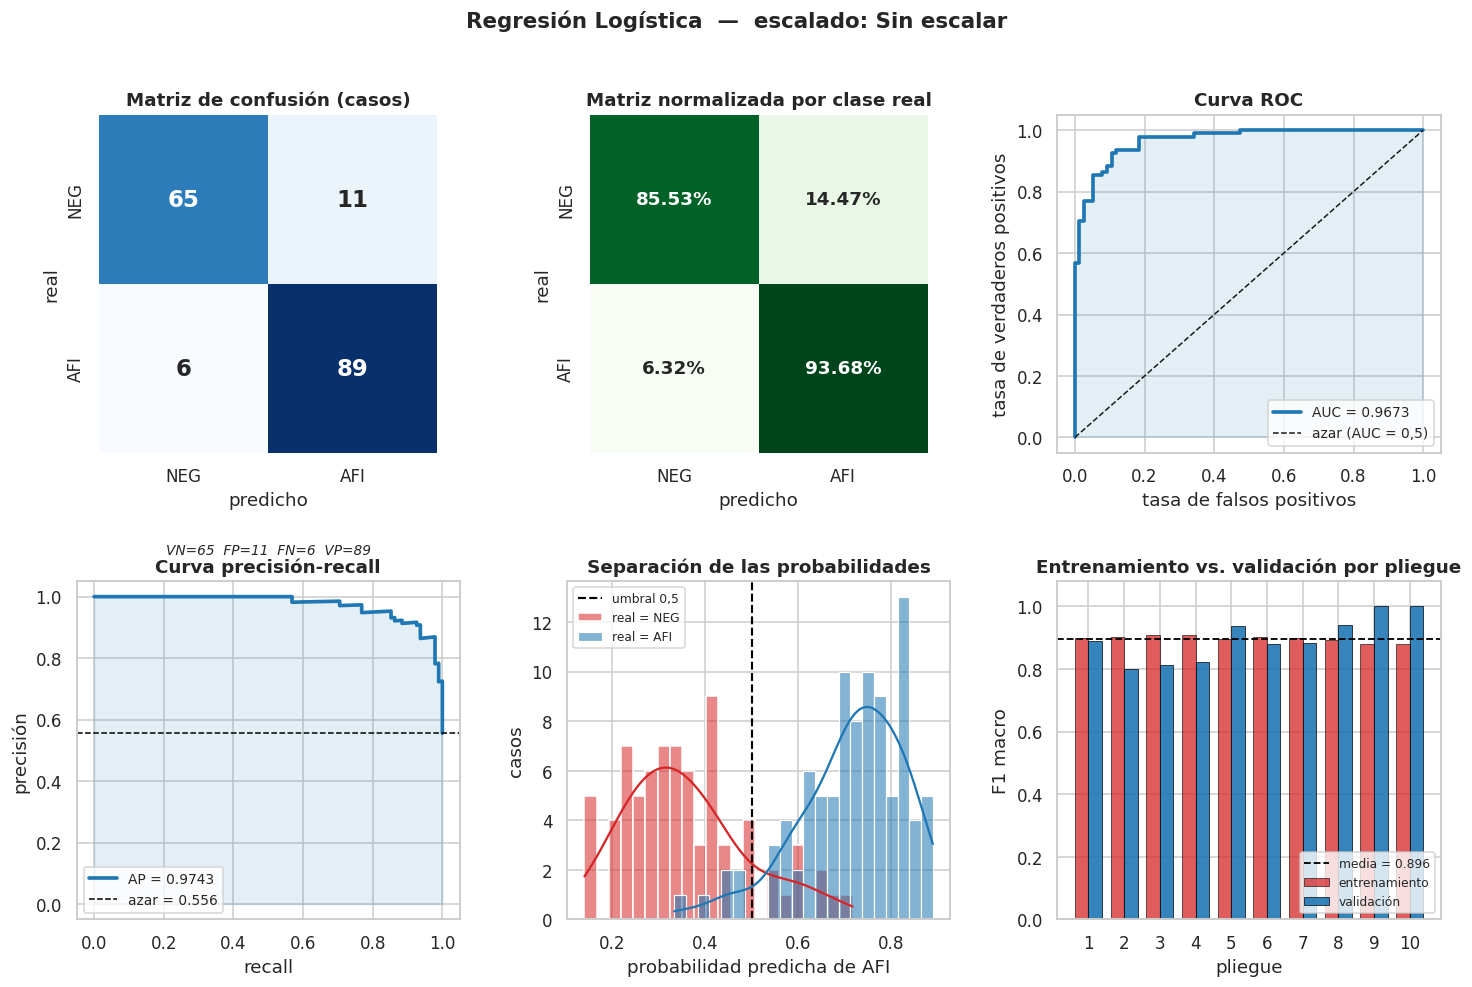


  ANÁLISIS ESPECÍFICO DE ESTE MODELO
  ------------------------------------------------------------------------------------


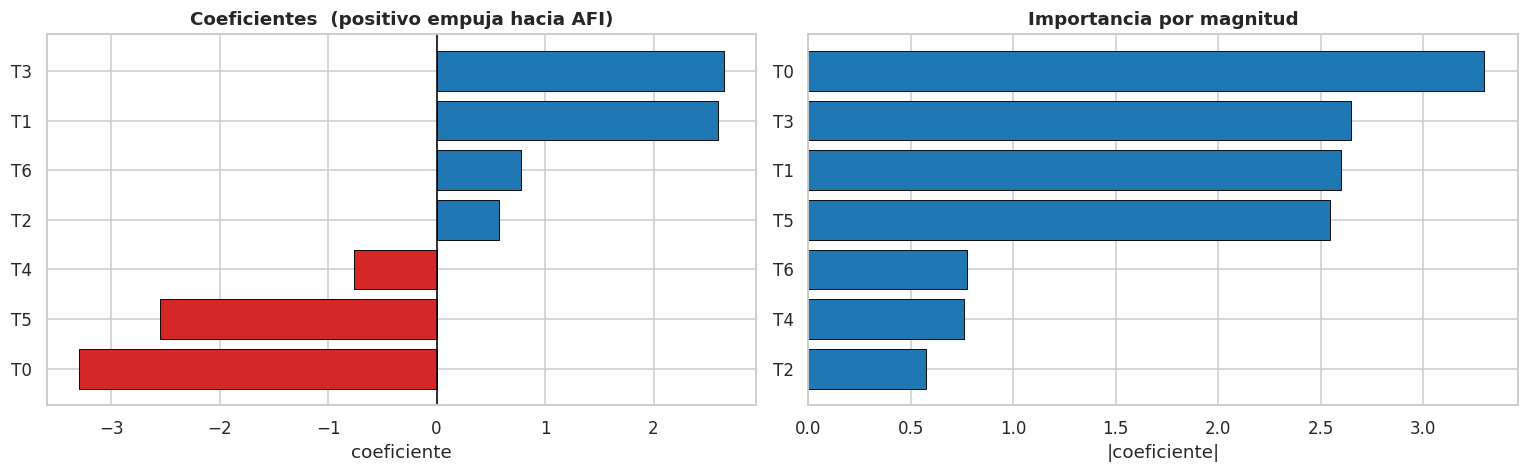

  Lectura de los coeficientes:
    T0            -3.2987   empuja hacia NEG
    T3            +2.6496   empuja hacia AFI
    T1            +2.5982   empuja hacia AFI
    T5            -2.5464   empuja hacia NEG
    T6            +0.7757   empuja hacia AFI
    T4            -0.7607   empuja hacia NEG
    T2            +0.5723   empuja hacia AFI

  Intercepto: +0.0429

  Recordatorio: como las siete columnas suman 1, los coeficientes son
  relativos entre sí. La regularización L2 elige una solución concreta y
  reproducible, pero la magnitud individual hay que leerla con esa cautela.


In [16]:
tabla_logistica = evaluar_modelo("Regresión Logística")

---
<a id="sec-9"></a>
# 9. Modelo 2 — K-Nearest Neighbors

<a id="sec-9-1"></a>
## 9.1 Presentación del modelo

**Cómo funciona.** KNN no ajusta ninguna fórmula. Guarda los datos de entrenamiento y, cuando
tiene que clasificar un caso nuevo, calcula la **distancia** entre ese caso y todos los demás,
toma los *k* más cercanos y **vota por mayoría**.

Si *k*=5 y de los cinco vecinos más cercanos tres son de clase 1 y dos de clase 0, predice
clase 1.

**Es un modelo perezoso** (*lazy learner*), y eso lo hace distinto de los demás. No hay
entrenamiento propiamente dicho: `fit()` se limita a guardar los datos. Todo el trabajo ocurre en
`predict()`, cuando hay que medir distancias contra el dataset entero. La consecuencia práctica es
que entrena instantáneamente y predice lento, justo al revés que los demás.

Y no tiene un modelo del mundo: no hay coeficientes, no hay reglas, no hay nada que uno pueda leer
para entender qué aprendió. Lo único que hay es el dataset. Por eso se dice que es un método
**basado en instancias**.

**La distancia es el corazón del modelo.** La habitual es la **euclidiana** —la distancia en línea
recta—, que es la que usa scikit-learn por defecto. También existen la de **Manhattan** (como
moverse por una cuadrícula, solo en ángulos rectos) y la de **Minkowski**, que generaliza a las
dos con un parámetro `p`: con `p=1` es Manhattan, con `p=2` es euclidiana.

**El escalado no es opcional acá, es imprescindible.** Si una variable va de 0 a 1 y otra de 0 a
100.000, la segunda domina por completo el cálculo de la distancia: no porque sea más importante
sino porque sus números son más grandes. Es un sesgo puramente artificial. En nuestro dataset las
siete variables ya están en el mismo rango, así que el efecto va a ser chico —pero lo vamos a
medir igual, que es distinto de suponerlo—.

### Ventajas y desventajas

| A favor | En contra |
|---|---|
| No supone ninguna forma para la frontera: la dibuja como los datos lo pidan | Predecir es caro: hay que medir contra todo el dataset |
| Entrena instantáneamente | Hay que guardar el dataset entero para poder predecir |
| Fácil de explicar: "se parece a estos cinco casos" | No produce ningún modelo legible ni importancia de variables |
| Funciona en problemas multiclase sin cambios | **Imprescindible** escalar |
| Un solo hiperparámetro importante | Sufre la maldición de la dimensionalidad |

Sobre esa última fila: con muchas variables, todos los puntos terminan más o menos igual de lejos
entre sí y la noción de "vecino cercano" pierde sentido. KNN funciona bien con pocas variables
—como acá, que son siete— y se degrada rápido cuando son decenas.

### Dónde se usa en la práctica

Sistemas de recomendación sencillos ("usuarios parecidos al tuyo eligieron esto"), imputación de
valores faltantes (`KNNImputer` completa un dato con el promedio de sus vecinos), detección de
anomalías —un caso cuyo vecino más cercano está muy lejos es raro por definición—, y
reconocimiento de patrones con pocas variables bien elegidas.

<a id="sec-9-2"></a>
## 9.2 Los hiperparámetros

| Parámetro | Qué controla | Efecto de subirlo |
|---|---|---|
| `n_neighbors` (*k*) | Cuántos vecinos votan | Más estabilidad, menos detalle local. Es el mando de la complejidad |
| `weights` | Si todos los vecinos pesan igual (`"uniform"`) o según su distancia (`"distance"`) | `"distance"` le da más voz al vecino más cercano; suele ayudar con *k* grande |
| `metric` / `p` | Cómo se mide la distancia | `p=1` Manhattan, `p=2` euclidiana |
| `algorithm` | La estructura de datos para buscar vecinos (`ball_tree`, `kd_tree`, `brute`) | No cambia el resultado, solo la velocidad |

### Elegir *k* es el compromiso central del modelo

Y es un ejemplo perfecto de lo que vimos en el punto 5 de la Parte 2A:

- ***k* muy bajo** (por ejemplo 1): el modelo decide en base a un único vecino, que puede ser
  atípico o estar mal etiquetado. Es muy sensible al ruido y tiende al **sobreajuste**.
- ***k* muy alto** (por ejemplo 50): gana estabilidad pero pierde capacidad de captar patrones
  locales. En el extremo, con *k* igual al tamaño del dataset, predice siempre la clase
  mayoritaria. Tiende al **subajuste**.

Dicho en los términos del 5.2: *k* es el mando del compromiso sesgo–varianza de este modelo. No hay
un valor universal: lo correcto es probarlo y medirlo, que es lo que hacen los puntos 9.3 a 9.5.

### Cómo se sobreajusta este modelo

Con *k* chico, y de la manera más literal posible. Con *k*=1 el vecino más cercano de cada caso de
entrenamiento es él mismo, así que el rendimiento en entrenamiento es perfecto por construcción: el
caso más puro de memorización que existe. La búsqueda del 9.4 lo mide junto con la brecha para todos
los valores de *k*: es la **forma 2** de detección del punto 5.4 de la Parte 2A, aplicada a un
hiperparámetro que no es la profundidad de un árbol.

<a id="sec-9-3"></a>
## 9.3 Optimización

Este modelo sí pide búsqueda: el *k* por defecto de scikit-learn (5) es una convención, no una
elección para estos datos. Se aplica la regla del punto 7.6.

**Qué se busca**

| Hiperparámetro | Valores | Por qué esos |
|---|---|---|
| `n_neighbors` | 1, 3, 5, 7, 11, 15, 21, 31, 45 | Impares, para que no haya empates en la votación. Más densos donde la curva cambia rápido (*k* chico) y más espaciados después. Van del extremo que memoriza (*k*=1) a uno que ya promedia casi un tercio de cada pliegue de entrenamiento |

Son 9 combinaciones.

**Qué queda fijo, y por qué**

- `weights="uniform"`: pesar por distancia es otra manera de mover el mismo mando —cuánto pesa lo
  local—. Buscarlo duplicaría la grilla sin cambiar lo que el modelo enseña.
- `metric` euclidiana: las siete variables son proporciones en la misma escala, no hay motivo para
  medir la distancia de otra forma.
- `algorithm`: no cambia el resultado, solo la velocidad.

**Con qué escalado se busca.** Con Z-score, dentro de un `Pipeline`: KNN no se puede evaluar sin
escalar, y el escalador tiene que ir adentro de cada pliegue para no filtrar información (punto 4.6
de la Parte 2A). Después, en el catálogo, el *k* elegido se prueba con los tres tratamientos.

**Más simple significa *k* mayor**: más vecinos votan, la frontera se suaviza y el modelo depende
menos de cada caso suelto.

<a id="sec-9-4"></a>
## 9.4 Código de la búsqueda

La grilla y la llamada a la función del punto 7.6. Todo lo demás —el máximo, el umbral, la franja y
la elección— lo hace la función, igual que para los otros modelos.

In [17]:
from sklearn.neighbors import KNeighborsClassifier

grilla_knn = {
    "modelo__n_neighbors": [1, 3, 5, 7, 11, 15, 21, 31, 45],
}

busqueda_knn = buscar_hiperparametros(
    Pipeline([
        ("escalador", StandardScaler()),
        ("modelo", KNeighborsClassifier()),
    ]),
    grilla_knn,
    orden_simplicidad=[("n_neighbors", "mayor")],
    titulo="KNN (con Z-score)",
)

  BÚSQUEDA DE HIPERPARÁMETROS — KNN (con Z-score)
  Hiperparámetros buscados   : ['n_neighbors']
  Combinaciones evaluadas    : 9
  Ajustes realizados         : 90
  Validación                 : el cv del punto 0.4 (10 pliegues), F1 macro

  Máximo                     : {'n_neighbors': 7}
      F1 macro               : 0.8914
      error estándar         : 0.0172  (desvío 0.0543 / raíz de 10)
  Umbral de empate técnico   : 0.8743
  Combinaciones en la franja : 5 de 9

  ELEGIDA (la más simple)    : {'n_neighbors': 45}
      F1 macro               : 0.8840
      Cede 0.0075 de F1 frente al máximo: menos que un error estándar,
      así que la diferencia no se distingue del ruido.
      Borde de la grilla: n_neighbors = 45 es el valor más simple probado.

  La franja de empate técnico, de la más simple a la más compleja:


,n_neighbors,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,45,0.8943,0.8840,0.0207,0.0103,ELEGIDA
1,31,0.8947,0.8898,0.0215,0.0049,
2,11,0.8993,0.8801,0.0242,0.0192,
3,7,0.9084,0.8914,0.0172,0.0169,máximo
4,5,0.9097,0.8914,0.0210,0.0184,


  Las cinco combinaciones con MÁS sobreajuste (mayor brecha):


,n_neighbors,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,1,1.0000,0.8675,0.0191,0.1325,
1,3,0.9357,0.8687,0.0190,0.0670,
2,15,0.8906,0.8611,0.0263,0.0295,
3,11,0.8993,0.8801,0.0242,0.0192,
4,5,0.9097,0.8914,0.0210,0.0184,


<a id="sec-9-5"></a>
## 9.5 Resultado de la búsqueda

Dos gráficos. A la izquierda, F1 macro en entrenamiento y en validación para cada *k*, con el error
estándar de cada promedio y la línea del umbral: todo punto de validación por encima de esa línea
está en empate técnico con el máximo. A la derecha, la brecha entre entrenamiento y validación.

Qué mirar: la brecha enorme con *k*=1, cómo se cierra al subir *k*, y cuánto más a la derecha queda
el *k* elegido respecto del máximo.

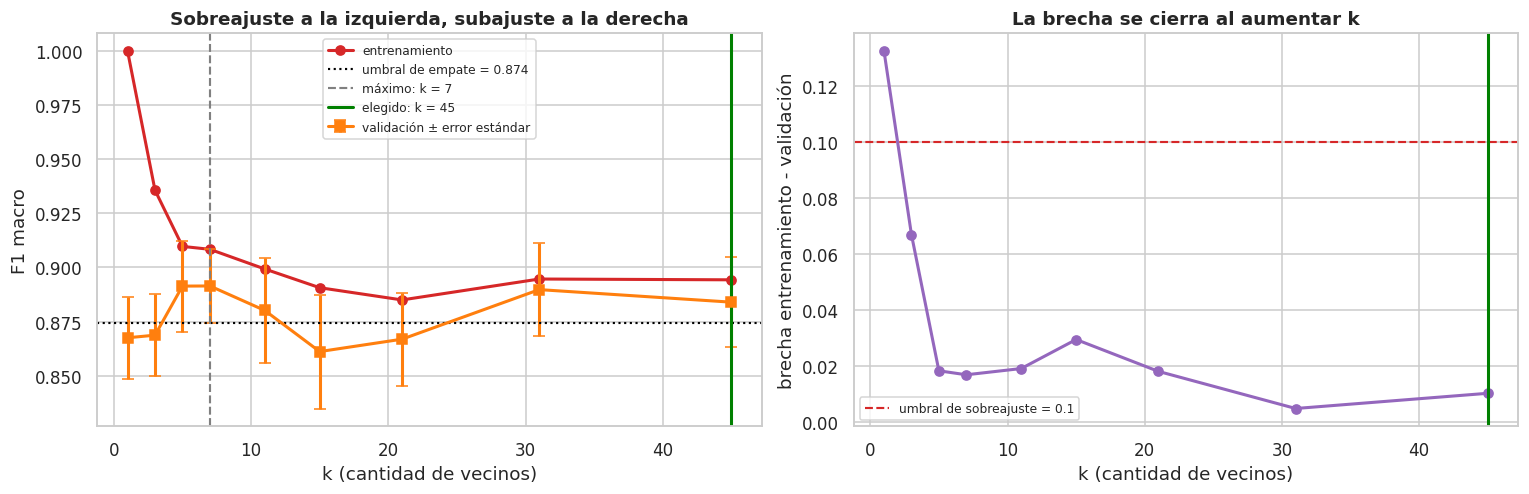

  Con k = 1 la brecha es de 0.1325: el modelo acierta casi todo en
  entrenamiento porque el vecino más cercano de cada caso es él mismo.
  Al aumentar k la brecha se cierra y el modelo empieza a generalizar.

  El máximo está en k = 7, pero k = 45 queda dentro de la franja
  de empate técnico y es más simple: promedia más vecinos y depende menos de
  cada caso suelto. Con estos datos, las dos opciones no se pueden distinguir.


In [18]:
tabla_k = busqueda_knn["tabla"].sort_values("n_neighbors")
k_maximo = busqueda_knn["maximo"]["n_neighbors"]
k_elegido = busqueda_knn["elegidos"]["n_neighbors"]

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))

ejes[0].plot(tabla_k["n_neighbors"], tabla_k["f1_entrena"], "o-", color="#d62728",
             linewidth=2, label="entrenamiento")
ejes[0].errorbar(tabla_k["n_neighbors"], tabla_k["f1_validacion"],
                 yerr=tabla_k["error_estandar"], fmt="s-", color="#ff7f0e", linewidth=2,
                 capsize=4, label="validación ± error estándar")
ejes[0].axhline(busqueda_knn["umbral"], color="black", linestyle=":", linewidth=1.4,
                label=f"umbral de empate = {busqueda_knn['umbral']:.3f}")
ejes[0].axvline(k_maximo, color="gray", linestyle="--", linewidth=1.4,
                label=f"máximo: k = {k_maximo}")
ejes[0].axvline(k_elegido, color="green", linestyle="-", linewidth=2,
                label=f"elegido: k = {k_elegido}")
ejes[0].set_xlabel("k (cantidad de vecinos)")
ejes[0].set_ylabel("F1 macro")
ejes[0].set_title("Sobreajuste a la izquierda, subajuste a la derecha")
ejes[0].legend(fontsize=8)

ejes[1].plot(tabla_k["n_neighbors"], tabla_k["brecha"], "o-", color="#9467bd", linewidth=2)
ejes[1].axhline(BRECHA_SOBREAJUSTE, color="#d62728", linestyle="--", linewidth=1.4,
                label=f"umbral de sobreajuste = {BRECHA_SOBREAJUSTE}")
ejes[1].axvline(k_elegido, color="green", linestyle="-", linewidth=2)
ejes[1].set_xlabel("k (cantidad de vecinos)")
ejes[1].set_ylabel("brecha entrenamiento - validación")
ejes[1].set_title("La brecha se cierra al aumentar k")
ejes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

brecha_k1 = tabla_k.loc[tabla_k["n_neighbors"] == 1, "brecha"].iloc[0]
print(f"  Con k = 1 la brecha es de {brecha_k1:.4f}: el modelo acierta casi todo en")
print("  entrenamiento porque el vecino más cercano de cada caso es él mismo.")
print("  Al aumentar k la brecha se cierra y el modelo empieza a generalizar.")
print()
if k_elegido == k_maximo:
    print(f"  El máximo (k = {k_maximo}) es también el k más grande de la franja de empate.")
else:
    print(f"  El máximo está en k = {k_maximo}, pero k = {k_elegido} queda dentro de la franja")
    print("  de empate técnico y es más simple: promedia más vecinos y depende menos de")
    print("  cada caso suelto. Con estos datos, las dos opciones no se pueden distinguir.")

<a id="sec-9-6"></a>
## 9.6 Ejecución en el catálogo

Con *k* elegido, registramos el modelo. Su gráfico propio es la curva de validación de la búsqueda:
deja registrado, junto al bloque de resultados, de dónde salió el valor.

Registrado: KNN (k=45)
    escalados a probar : ['Sin escalar', 'Min-Max', 'Z-score']
    hiperparámetros    : {'n_neighbors': 45}  (búsqueda del punto 7.6)
    Decide por proximidad; frontera flexible; el escalado es imprescindible.
  KNN (K=45)
  Decide por proximidad; frontera flexible; el escalado es imprescindible.

  EFECTO DEL ESCALADO
  ------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,f1_macro,roc_auc,desvio_pliegues,brecha
escalado,,,,,,
Sin escalar,0.8947,0.8908,0.8928,0.9650,0.0727,0.0064
Min-Max,0.8889,0.8829,0.8863,0.9647,0.0656,0.0096
Z-score,0.8889,0.8829,0.8863,0.9599,0.0656,0.0103


  Diferencia entre el mejor y el peor escalado (ROC-AUC): 0.0051

  MEJOR VARIANTE: KNN (k=45) + Sin escalar

  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)
  ------------------------------------------------------------------------------------
    Rendimiento general
      Accuracy               0.8947    proporción de aciertos sobre el total
      Balanced accuracy      0.8908    promedio del recall de cada clase
    Clase positiva (AFI)
      Precisión              0.8889    de los predichos positivos, cuántos lo eran
      Recall                 0.9263    de los positivos reales, cuántos detectó
      F1-score               0.9072    media armónica de precisión y recall
    Promediadas entre clases
      Precisión macro        0.8958    promedio simple entre clases
      Recall macro           0.8908    promedio simple entre clases
      F1 macro               0.8928    trata a las dos clases por igual
      F1 ponderado           0.8944    pondera por la frecuencia

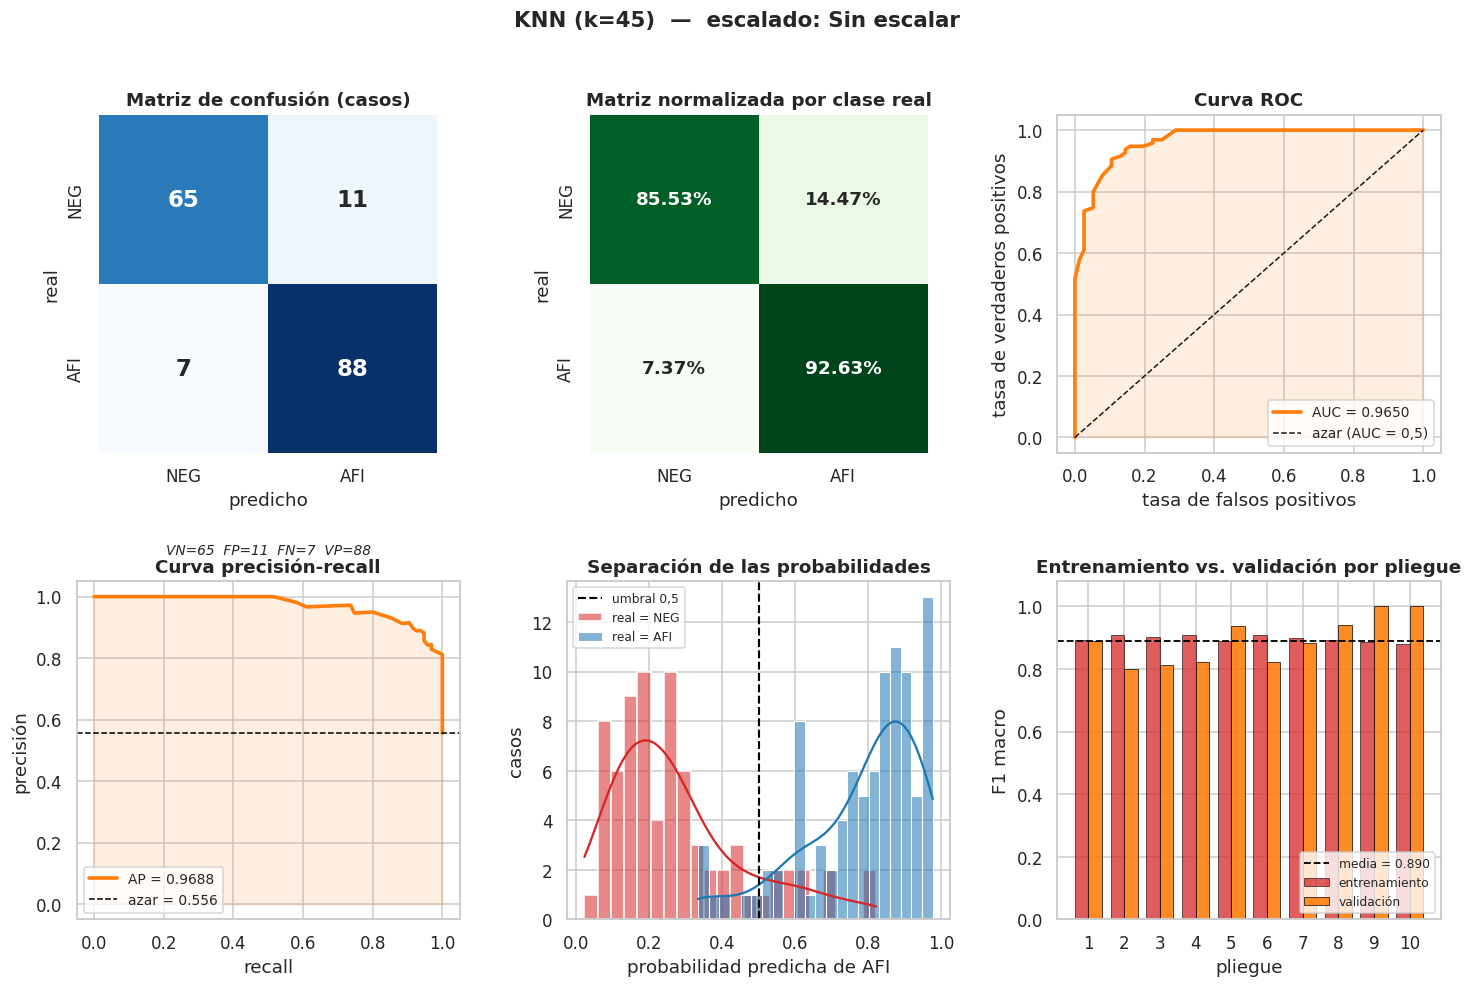


  ANÁLISIS ESPECÍFICO DE ESTE MODELO
  ------------------------------------------------------------------------------------


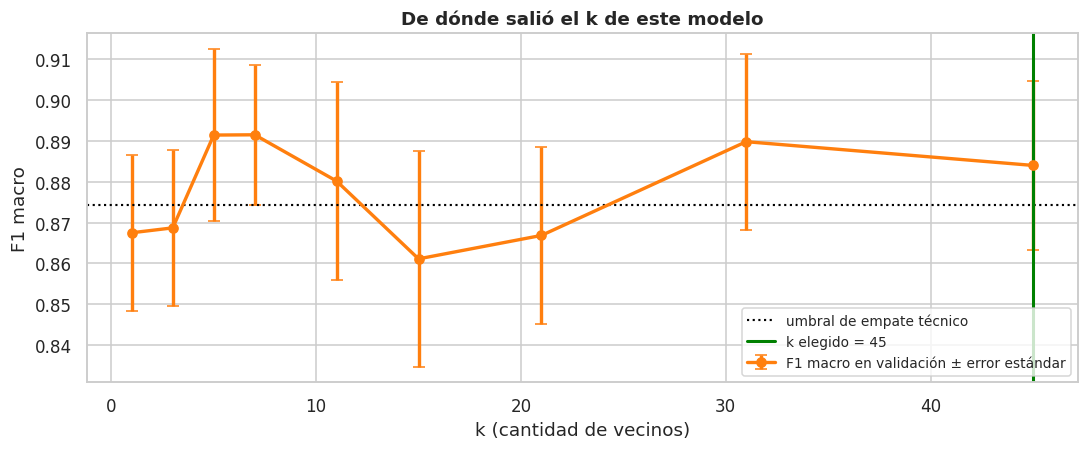

  k = 45: el más grande dentro de un error estándar del máximo,
  entre los valores [1, 3, 5, 7, 11, 15, 21, 31, 45].


In [19]:
def grafico_curva_k(pipeline_ajustado, color):
    k_usado = pipeline_ajustado.named_steps["modelo"].n_neighbors
    tabla = busqueda_knn["tabla"].sort_values("n_neighbors")

    fig, eje = plt.subplots(figsize=(10, 4.2))
    eje.errorbar(tabla["n_neighbors"], tabla["f1_validacion"], yerr=tabla["error_estandar"],
                 fmt="o-", color=color, linewidth=2.2, capsize=4,
                 label="F1 macro en validación ± error estándar")
    eje.axhline(busqueda_knn["umbral"], color="black", linestyle=":", linewidth=1.4,
                label="umbral de empate técnico")
    eje.axvline(k_usado, color="green", linestyle="-", linewidth=2,
                label=f"k elegido = {k_usado}")
    eje.set_xlabel("k (cantidad de vecinos)")
    eje.set_ylabel("F1 macro")
    eje.set_title("De dónde salió el k de este modelo")
    eje.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"  k = {k_usado}: el más grande dentro de un error estándar del máximo,")
    print(f"  entre los valores {list(tabla['n_neighbors'])}.")


nombre_knn = f"KNN (k={k_elegido})"

registrar_modelo(
    nombre_knn,
    KNeighborsClassifier(**busqueda_knn["elegidos"]),
    color="#ff7f0e",
    nota="Decide por proximidad; frontera flexible; el escalado es imprescindible.",
    grafico_extra=grafico_curva_k,
    busqueda=busqueda_knn,
)

tabla_knn = evaluar_modelo(nombre_knn)

---
<a id="sec-10"></a>
# 10. Modelo 3 — Árbol de Decisión

<a id="sec-10-1"></a>
## 10.1 Presentación del modelo

**Cómo funciona.** Un árbol de decisión aprende una secuencia de preguntas del tipo *"¿esta
variable es mayor que tal valor?"*. Cada pregunta parte los datos en dos, y el proceso se repite
sobre cada mitad hasta llegar a grupos lo más homogéneos posible en cuanto a la clase.

El resultado es literalmente un árbol: una raíz, nodos internos que preguntan, y **hojas** que
responden. Para clasificar un caso nuevo se lo hace caer desde la raíz respondiendo cada pregunta,
y la hoja donde termina da la predicción.

### Cómo elige cada corte

En cada nodo el algoritmo prueba **todas las variables y todos los umbrales posibles**, y se queda
con el corte que más "ordena" los datos. Ordenar se mide con una función de **impureza**:

| Criterio | Qué mide | Fórmula | Vale 0 cuando |
|---|---|---|---|
| **Gini** (por defecto) | La probabilidad de clasificar mal un caso tomado al azar | $1 - \sum p_i^2$ | El nodo tiene una sola clase |
| **Entropía** | La incertidumbre del nodo, en bits | $-\sum p_i \log_2 p_i$ | El nodo tiene una sola clase |

Los dos dan resultados casi idénticos en la práctica; Gini es un poco más rápido porque no calcula
logaritmos. El corte elegido es el que produce la mayor **reducción de impureza**, pesada por
cuántos casos van a cada lado. Ese mismo número, acumulado a lo largo de todo el árbol, es lo que
después se reporta como **importancia de la variable**.

Es un algoritmo **voraz**: elige el mejor corte en cada paso sin mirar a futuro. No garantiza el
mejor árbol posible, pero encontrar ese árbol óptimo es computacionalmente inviable.

### Qué aporta que los otros no tienen

- **Captura relaciones no lineales e interacciones** entre variables sin que haya que decírselo.
  Si la clase depende de "el tópico 3 es alto **y además** el tópico 5 es bajo", el árbol lo
  encuentra solo; la regresión logística necesitaría que le fabricáramos esa variable.
- **Es completamente legible.** Se puede dibujar el árbol entero y seguir el camino de cualquier
  caso hasta su predicción. No es una caja negra, y por eso lo vamos a graficar.
- **No necesita escalado**, y eso nos sirve como control: si al aplicarle Min-Max o Z-score el
  resultado cambiara aunque sea un poco, habría un error en nuestra maquinaria de evaluación. Un
  árbol corta por umbrales, y las dos transformaciones son monótonas —no cambian el orden de los
  valores—, así que los cortes deben caer exactamente en los mismos lugares.
- **Tolera variables irrelevantes**: simplemente no las usa, y se nota en la importancia.

### Ventajas y desventajas

| A favor | En contra |
|---|---|
| Legible de punta a punta | Muy inestable: chico cambio en los datos, otro árbol |
| Capta no linealidades e interacciones | Sobreajusta por defecto |
| Indiferente a la escala | Fronteras siempre perpendiculares a los ejes: una diagonal la aproxima con escalones |
| Maneja variables numéricas y categóricas | Tiende a favorecer variables con muchos valores distintos |
| Rápido de entrenar y de predecir | Rara vez es el mejor modelo por sí solo |

### Dónde se usa en la práctica

Como modelo final, sobre todo donde la decisión tiene que poder explicarse en una reunión:
protocolos de triage médico, reglas de negocio, criterios de elegibilidad. Y como **componente**,
que es su uso más frecuente hoy: los árboles son los ladrillos del Random Forest, del Gradient
Boosting y de XGBoost, que son los modelos que suelen ganar en datos tabulares.

<a id="sec-10-2"></a>
## 10.2 Los hiperparámetros

Todos son formas de podar, es decir, de frenar el crecimiento:

| Parámetro | Qué controla | Por defecto |
|---|---|---|
| `max_depth` | Cuántas preguntas encadenadas como máximo | `None`: **sin límite** |
| `min_samples_leaf` | Cuántos casos tiene que tener una hoja como mínimo | 1 |
| `min_samples_split` | Cuántos casos hacen falta para partir un nodo | 2 |
| `max_features` | Cuántas variables se consideran en cada corte | todas |
| `criterion` | Gini o entropía | `"gini"` |
| `ccp_alpha` | Poda posterior por costo-complejidad | 0: sin poda |
| `class_weight` | Peso de cada clase | ninguno |

**Los valores por defecto sobreajustan.** Un `DecisionTreeClassifier()` recién creado crece hasta
que cada hoja sea pura, aunque eso signifique una hoja por caso. Es el único de los seis modelos que
viene de fábrica en el extremo de la complejidad: sin una búsqueda, el árbol que entraría al catálogo
sería el que memoriza.

### Cómo se sobreajusta este modelo: la inestabilidad

Un árbol crecido sin restricciones memoriza el entrenamiento, como se vio en el punto 5.7 de la
Parte 2A. Y es muy sensible: cambiando unos pocos casos, el árbol resultante puede ser
**completamente distinto** —no un poco distinto: otro árbol, con otra variable en la raíz—. En los
términos del punto 5.2 de la Parte 2A, es un modelo de **varianza muy alta**.

Eso tiene una consecuencia incómoda para la interpretabilidad: el árbol es legible, sí, pero lo
que se lee puede ser un accidente de la muestra. Un árbol entrenado con otras 171 filas contaría
otra historia igual de convincente.

Por eso hay que **podarlo**, limitando su complejidad. Y por eso existe el Random Forest del punto
siguiente, que es la respuesta directa a este problema.

<a id="sec-10-3"></a>
## 10.3 Optimización

Este modelo pide búsqueda más que ninguno (punto 10.2). Se aplica la regla del punto 7.6.

**Qué se busca**

| Hiperparámetro | Valores | Por qué esos |
|---|---|---|
| `max_depth` | 2, 3, 4, 6, sin límite | Cuántas preguntas encadenadas. De un árbol de tres o cuatro hojas a uno que crece hasta donde quiera |
| `min_samples_leaf` | 1, 5, 10, 20 | Cuántos casos debe tener cada hoja como mínimo. De la hoja de un solo caso a hojas con más del 10 % de cada pliegue de entrenamiento |

Son 20 combinaciones. Los dos son frenos complementarios: uno limita la profundidad, el otro impide
hojas que representen a un puñado de casos. La grilla incluye **a propósito** la combinación "sin
límite" con hojas de 1 caso: es el árbol por defecto, y verlo encabezar la tabla de sobreajuste es
parte de la lección.

**Qué queda fijo, y por qué**

- `criterion="gini"`: gini y entropía dan árboles casi idénticos (punto 10.1). Incluirlo duplicaría
  la grilla sin cambiar nada de lo que el modelo enseña.
- `min_samples_split`: es redundante con `min_samples_leaf`; los dos frenan lo mismo.
- `max_features` en todas las variables: limitar las variables por corte es la idea del bosque, y
  queda para el punto 11.
- `ccp_alpha=0`: es otra forma de podar; con dos frenos alcanza.
- `class_weight` sin tocar: las clases están 56/44.

**Sin escalado**: el árbol es indiferente a la escala, así que la búsqueda se hace sobre los datos tal
como vienen.

**Más simple significa menos profundidad** y, si dos combinaciones tienen la misma, **hojas más
grandes**.

<a id="sec-10-4"></a>
## 10.4 Código de la búsqueda

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

grilla_arbol = {
    "max_depth": [2, 3, 4, 6, None],
    "min_samples_leaf": [1, 5, 10, 20],
}

busqueda_arbol = buscar_hiperparametros(
    DecisionTreeClassifier(random_state=SEMILLA),
    grilla_arbol,
    orden_simplicidad=[("max_depth", "menor"), ("min_samples_leaf", "mayor")],
    titulo="ÁRBOL DE DECISIÓN",
)

  BÚSQUEDA DE HIPERPARÁMETROS — ÁRBOL DE DECISIÓN
  Hiperparámetros buscados   : ['max_depth', 'min_samples_leaf']
  Combinaciones evaluadas    : 20
  Ajustes realizados         : 200
  Validación                 : el cv del punto 0.4 (10 pliegues), F1 macro

  Máximo                     : {'max_depth': 6, 'min_samples_leaf': 5}
      F1 macro               : 0.8618
      error estándar         : 0.0296  (desvío 0.0937 / raíz de 10)
  Umbral de empate técnico   : 0.8322
  Combinaciones en la franja : 12 de 20

  ELEGIDA (la más simple)    : {'max_depth': 3, 'min_samples_leaf': 10}
      F1 macro               : 0.8458
      Cede 0.0160 de F1 frente al máximo: menos que un error estándar,
      así que la diferencia no se distingue del ruido.

  La franja de empate técnico, de la más simple a la más compleja:


,max_depth,min_samples_leaf,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,3,10,0.8851,0.8458,0.0186,0.0393,ELEGIDA
1,3,5,0.9067,0.8335,0.0277,0.0732,
2,3,1,0.9295,0.8402,0.0215,0.0893,
3,4,10,0.8875,0.8518,0.0222,0.0357,
4,4,5,0.9329,0.8612,0.0332,0.0717,
5,4,1,0.9635,0.8526,0.0347,0.1109,
6,6,10,0.8875,0.8518,0.0222,0.0357,
7,6,5,0.9361,0.8618,0.0296,0.0743,máximo
8,6,1,0.9901,0.8430,0.0298,0.1471,
9,None,10,0.8875,0.8518,0.0222,0.0357,


  Las cinco combinaciones con MÁS sobreajuste (mayor brecha):


,max_depth,min_samples_leaf,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,None,1,1.0000,0.8371,0.0271,0.1629,
1,6,1,0.9901,0.8430,0.0298,0.1471,
2,4,1,0.9635,0.8526,0.0347,0.1109,
3,3,1,0.9295,0.8402,0.0215,0.0893,
4,3,20,0.8436,0.7667,0.0290,0.0769,


<a id="sec-10-5"></a>
## 10.5 Resultado de la búsqueda

La grilla completa como dos mapas de calor: F1 macro en validación a la izquierda y brecha a la
derecha. El recuadro punteado es el máximo; el lleno, la combinación elegida.

Qué mirar: la fila de "sin límite" con hojas de 1 caso —el árbol por defecto— tiene la brecha más
alta; y en el mapa de validación, varias celdas de árboles chicos quedan a la par de las de árboles
grandes.

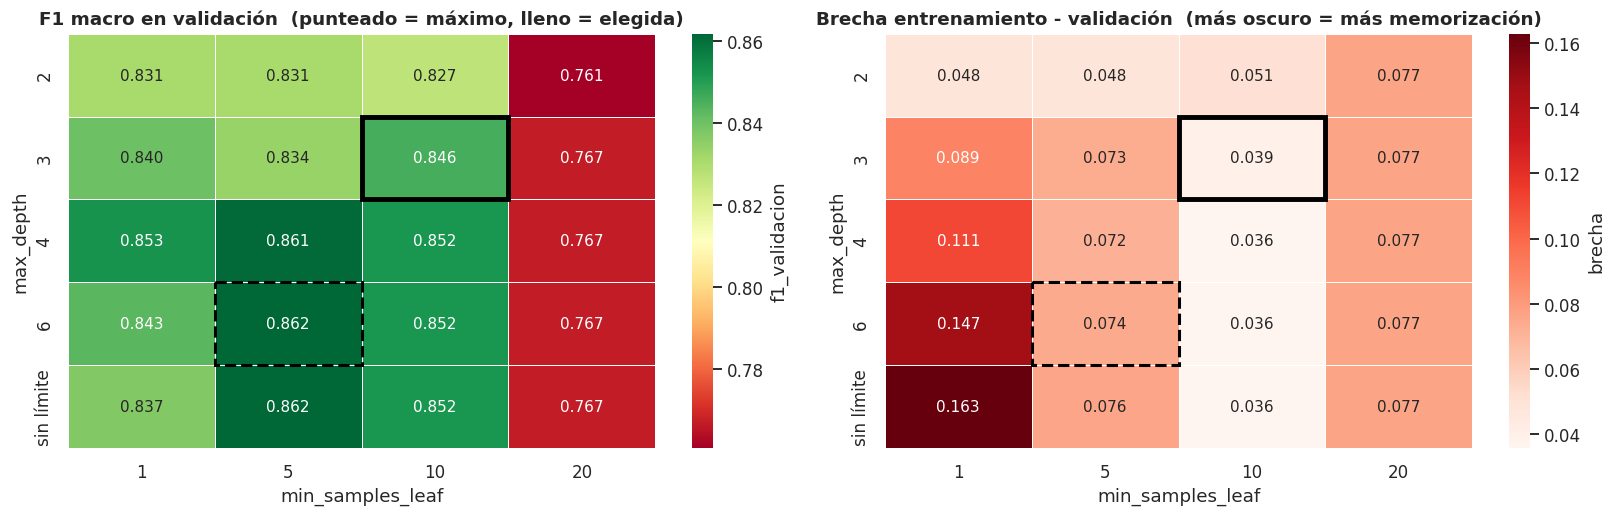

  El árbol por defecto (sin límite, hojas de 1 caso): brecha 0.1629,
  F1 en validación 0.8371.
  El elegido {'max_depth': 3, 'min_samples_leaf': 10}: brecha 0.0393,
  F1 en validación 0.8458.
  Podar le baja el puntaje de entrenamiento y casi no le cuesta en validación:
  lo que pierde es, en su mayor parte, memoria.


In [21]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
dibujar_mapa_busqueda(ejes[0], busqueda_arbol, "max_depth", "min_samples_leaf")
ejes[0].set_title("F1 macro en validación  (punteado = máximo, lleno = elegida)")
dibujar_mapa_busqueda(ejes[1], busqueda_arbol, "max_depth", "min_samples_leaf",
                      valor="brecha", cmap="Reds")
ejes[1].set_title("Brecha entrenamiento - validación  (más oscuro = más memorización)")
plt.tight_layout()
plt.show()

tabla_arbol_busqueda = busqueda_arbol["tabla"]
por_defecto = tabla_arbol_busqueda[(tabla_arbol_busqueda["max_depth"].isna()) &
                                   (tabla_arbol_busqueda["min_samples_leaf"] == 1)].iloc[0]
elegida = tabla_arbol_busqueda.loc[busqueda_arbol["i_elegida"]]
print(f"  El árbol por defecto (sin límite, hojas de 1 caso): brecha {por_defecto['brecha']:.4f},")
print(f"  F1 en validación {por_defecto['f1_validacion']:.4f}.")
print(f"  El elegido {busqueda_arbol['elegidos']}: brecha {elegida['brecha']:.4f},")
print(f"  F1 en validación {elegida['f1_validacion']:.4f}.")
print("  Podar le baja el puntaje de entrenamiento y casi no le cuesta en validación:")
print("  lo que pierde es, en su mayor parte, memoria.")

<a id="sec-10-6"></a>
## 10.6 Ejecución en el catálogo

Registramos el árbol con los valores elegidos. Su gráfico propio es el árbol dibujado más la
importancia de cada variable.

La **importancia** de una variable en un árbol es cuánto contribuyó a reducir la impureza a lo
largo de todos los cortes en los que participó. Es una medida distinta del coeficiente de la
logística —no tiene signo, no dice hacia qué clase empuja— pero responde la misma pregunta de
fondo: qué variables está usando el modelo.

Registrado: Árbol de Decisión
    escalados a probar : ['Sin escalar', 'Min-Max', 'Z-score']
    hiperparámetros    : {'max_depth': 3, 'min_samples_leaf': 10}  (búsqueda del punto 7.6)
    Reglas explícitas; capta no linealidades; indiferente a la escala.
  ÁRBOL DE DECISIÓN
  Reglas explícitas; capta no linealidades; indiferente a la escala.

  EFECTO DEL ESCALADO
  ------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,f1_macro,roc_auc,desvio_pliegues,brecha
escalado,,,,,,
Sin escalar,0.8538,0.8447,0.8492,0.8855,0.0589,0.0393
Min-Max,0.8538,0.8447,0.8492,0.8855,0.0589,0.0393
Z-score,0.8538,0.8447,0.8492,0.8855,0.0589,0.0393


  El escalado NO cambia absolutamente nada en este modelo.
  Es lo esperado en modelos basados en árboles: los cortes se hacen por
  umbrales, y Min-Max y Z-score son transformaciones monótonas que no
  alteran el orden de los valores, así que los cortes caen en el mismo lugar.

  MEJOR VARIANTE: Árbol de Decisión + Sin escalar

  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)
  ------------------------------------------------------------------------------------
    Rendimiento general
      Accuracy               0.8538    proporción de aciertos sobre el total
      Balanced accuracy      0.8447    promedio del recall de cada clase
    Clase positiva (AFI)
      Precisión              0.8302    de los predichos positivos, cuántos lo eran
      Recall                 0.9263    de los positivos reales, cuántos detectó
      F1-score               0.8756    media armónica de precisión y recall
    Promediadas entre clases
      Precisión macro        0.8612    promedio sim

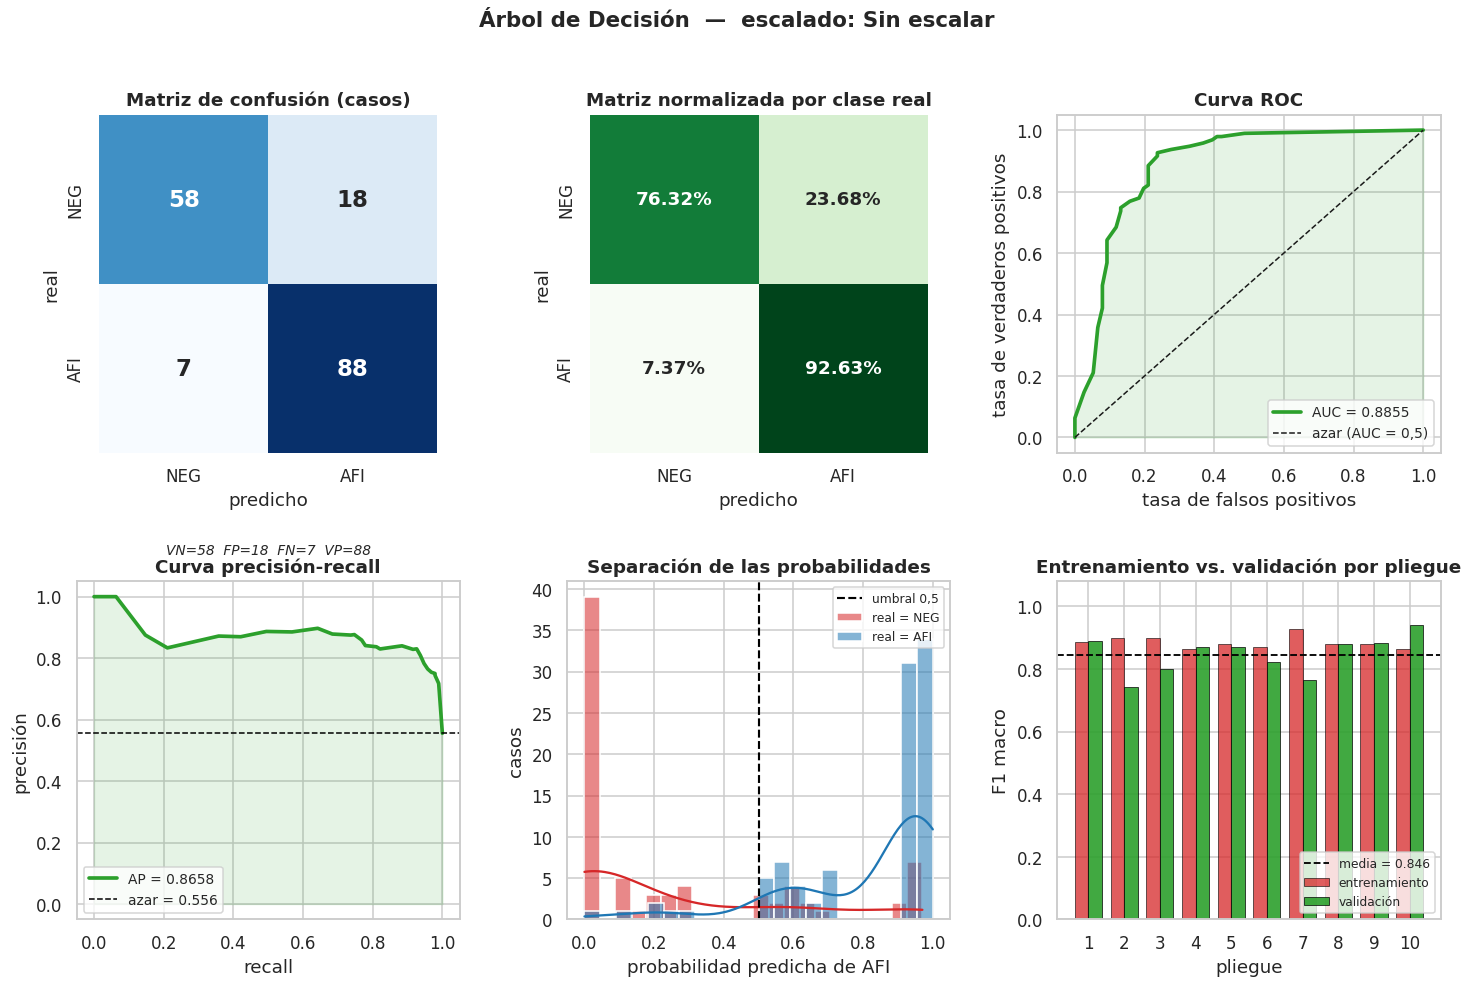


  ANÁLISIS ESPECÍFICO DE ESTE MODELO
  ------------------------------------------------------------------------------------


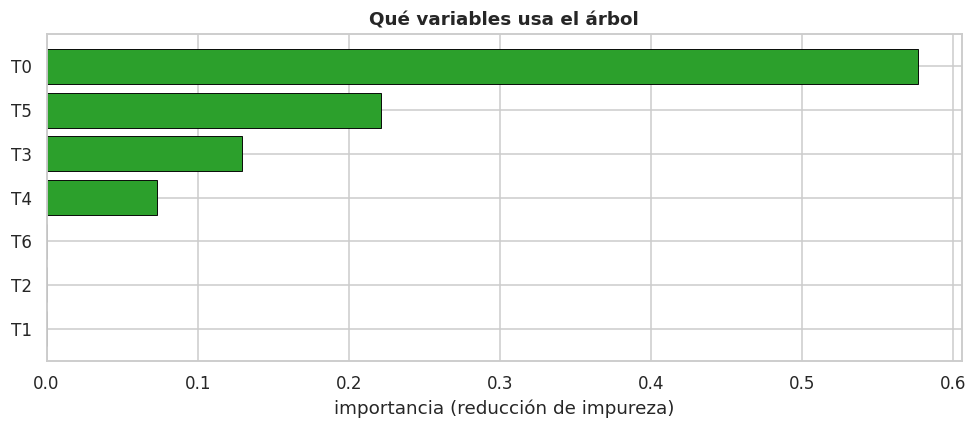

  El árbol usa 4 de las 7 variables disponibles.
  Variables ordenadas por importancia:
    T0            0.5767
    T5            0.2210
    T3            0.1292
    T4            0.0731
    T6            0.0000   (no usada)
    T1            0.0000   (no usada)
    T2            0.0000   (no usada)


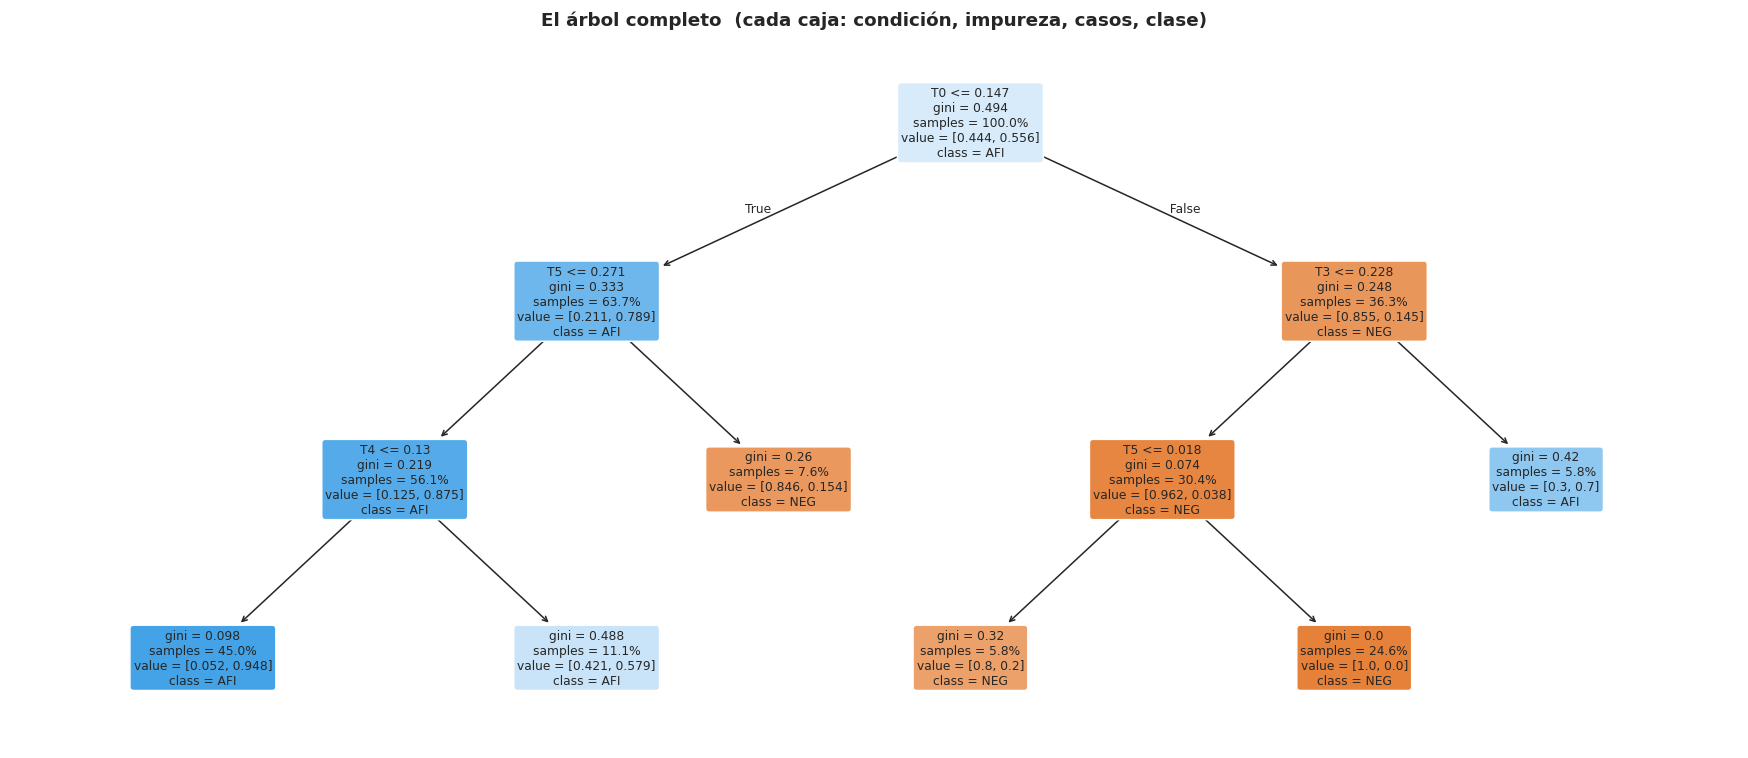

  Profundidad del árbol : 3
  Hojas terminales      : 6

  Cómo leer cada caja: arriba la condición que se evalúa (si es verdadera se
  va a la izquierda), después la impureza, la proporción de casos que llegan
  a ese nodo, el reparto entre clases y la clase mayoritaria. El color indica
  qué clase domina y su intensidad, cuán pura es la hoja.


In [22]:
def grafico_arbol(pipeline_ajustado, color):
    modelo = pipeline_ajustado.named_steps["modelo"]

    importancias = pd.Series(modelo.feature_importances_, index=predictoras)
    importancias = importancias.sort_values(ascending=True)

    fig, eje = plt.subplots(figsize=(9, 4))
    eje.barh(importancias.index, importancias.values, color=color,
             edgecolor="black", linewidth=0.6)
    eje.set_xlabel("importancia (reducción de impureza)")
    eje.set_title("Qué variables usa el árbol")
    plt.tight_layout()
    plt.show()

    usadas = int((importancias > 0).sum())
    print(f"  El árbol usa {usadas} de las {len(predictoras)} variables disponibles.")
    print("  Variables ordenadas por importancia:")
    for variable, valor in importancias.sort_values(ascending=False).items():
        marca = "" if valor > 0 else "   (no usada)"
        print(f"    {variable:<12} {valor:>7.4f}{marca}")

    fig, eje = plt.subplots(figsize=(16, 7))
    plot_tree(modelo, feature_names=predictoras,
              class_names=[str(clase_negativa), str(CLASE_POSITIVA)],
              filled=True, rounded=True, fontsize=8, proportion=True, ax=eje)
    eje.set_title("El árbol completo  (cada caja: condición, impureza, casos, clase)",
                  fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Profundidad del árbol : {modelo.get_depth()}")
    print(f"  Hojas terminales      : {modelo.get_n_leaves()}")
    print()
    print("  Cómo leer cada caja: arriba la condición que se evalúa (si es verdadera se")
    print("  va a la izquierda), después la impureza, la proporción de casos que llegan")
    print("  a ese nodo, el reparto entre clases y la clase mayoritaria. El color indica")
    print("  qué clase domina y su intensidad, cuán pura es la hoja.")


registrar_modelo(
    "Árbol de Decisión",
    DecisionTreeClassifier(random_state=SEMILLA, **busqueda_arbol["elegidos"]),
    color="#2ca02c",
    nota="Reglas explícitas; capta no linealidades; indiferente a la escala.",
    grafico_extra=grafico_arbol,
    busqueda=busqueda_arbol,
)

tabla_arbol = evaluar_modelo("Árbol de Decisión")

---
<a id="sec-11"></a>
# 11. Modelo 4 — Random Forest

<a id="sec-11-1"></a>
## 11.1 Presentación del modelo

Un **Random Forest** (bosque aleatorio) es un **conjunto** (*ensemble*) de muchos árboles de
decisión que votan. Es la respuesta directa al problema que dejó planteado el punto 10: el árbol
capta bien las relaciones no lineales, pero es tan inestable que no se puede confiar en ninguno en
particular.

La idea de fondo es de sentido común: si un experto es bueno pero errático, no se le pregunta a
uno solo. Se le pregunta a cuatrocientos y se promedia. Los errores erráticos —que por definición
van para cualquier lado— se cancelan entre sí; el acierto sistemático, que va siempre para el
mismo lado, sobrevive al promedio.

### Las dos dosis de azar

Para que los árboles cometan errores **distintos** hay que hacerlos distintos, y el bosque usa dos
mecanismos:

**1. *Bagging* (muestreo bootstrap).** Cada árbol se entrena sobre una muestra distinta, tomada
del dataset **con reposición** y del mismo tamaño que el original. Como se saca con reposición,
algunas filas aparecen repetidas y otras no aparecen: en promedio, cada árbol ve cerca del 63 % de
las filas distintas. Las que quedan afuera se llaman ***out-of-bag*** y sirven para estimar el
rendimiento gratis, sin conjunto de prueba —es el parámetro `oob_score`—.

**2. Submuestreo de variables.** En **cada corte** de cada árbol, el algoritmo no puede elegir
entre todas las variables sino solo entre un subconjunto al azar. Esto parece un desperdicio, y es
lo que hace que el bosque funcione: sin esto, si hay una variable claramente mejor que las demás,
todos los árboles la elegirían en la raíz y terminarían pareciéndose mucho. Promediar modelos
parecidos no cancela nada. Forzar la variedad es lo que vuelve útil el promedio.

En los términos del punto 5.2 de la Parte 2A: el bosque **conserva el bajo sesgo del árbol y le
cancela la varianza**. De los modelos vistos hasta acá, es el único que mejora en las dos columnas a
la vez.

### Ventajas y desventajas

| A favor | En contra |
|---|---|
| Suele rendir muy bien sin ajustar nada | Deja de ser interpretable |
| Muy robusto al sobreajuste | Más lento de entrenar y de predecir |
| Indiferente a la escala | Ocupa mucha más memoria: hay que guardar todos los árboles |
| Da importancia de variables | La importancia se reparte mal entre variables correlacionadas |
| Tolera outliers y variables irrelevantes | No extrapola: nunca predice fuera del rango que vio |
| Paraleliza sin esfuerzo | Sus buenos resultados por defecto invitan a no pensar |

### Dónde se usa en la práctica

Es el caballo de batalla de los datos tabulares: detección de fraude, scoring de riesgo, predicción
de abandono de clientes, bioinformática, teledetección. En competencias y en producción suele ser
la primera línea de base seria que se prueba después de la logística, y en muchos casos es también
la última: la diferencia contra modelos más sofisticados no siempre justifica el trabajo extra.

<a id="sec-11-2"></a>
## 11.2 Los hiperparámetros

| Parámetro | Qué controla | Comentario |
|---|---|---|
| `n_estimators` | Cuántos árboles | Más es mejor o igual; solo cuesta tiempo. 100 a 500 es lo habitual |
| `max_features` | Cuántas variables se consideran en cada corte | Es **el** parámetro del bosque: controla cuán distintos son los árboles entre sí |
| `max_depth`, `min_samples_leaf` | La poda de cada árbol individual | Suele dejarse sin límite: el promedio ya controla la varianza |
| `bootstrap` | Si se muestrea con reposición | `True` por defecto; ponerlo en `False` desactiva el *bagging* |
| `oob_score` | Estimar el rendimiento con las filas que quedaron afuera | Una validación gratis, aunque optimista con datasets chicos |
| `n_jobs` | Cuántos núcleos usar | Los árboles son independientes: paraleliza perfecto |
| `class_weight` | Peso de cada clase | `"balanced"` para clases desbalanceadas |

### Cómo se sobreajusta este modelo: casi no lo hace

Es una propiedad que sorprende: **agregar árboles nunca empeora el modelo**. Más árboles es
siempre mejor o igual, y solo cuesta tiempo de cómputo. La razón es que los árboles no se suman,
se **promedian**: agregar uno más reduce la varianza del promedio, no aumenta la complejidad de la
función aprendida.

El "casi" existe igual. Un bosque puede sobreajustar si los datos tienen mucho ruido y los árboles
crecen sin límite, y si el dataset es muy chico el promedio de árboles que vieron casi las mismas
filas no cancela tanto como uno esperaría. Con 171 filas conviene no dar por sentado que es
inmune, y por eso lo pasamos por el mismo diagnóstico que a los demás.

Lo que sí pierde, y no es poco, es la legibilidad: 400 árboles no se leen. Lo único que queda es
la **importancia de las variables**, y ni siquiera eso es del todo confiable cuando hay variables
correlacionadas entre sí, porque la importancia se reparte entre ellas.

<a id="sec-11-3"></a>
## 11.3 Optimización

**Sin búsqueda**, por el primer paso de la regla del punto 7.6. Este modelo no la pide:

- `n_estimators` **no se busca, se elige grande**. Como más árboles nunca empeora (punto 11.2), no
  hay un óptimo que encontrar: alcanza con que sean suficientes. Usamos 400.
- `max_features` queda en su valor por defecto, la raíz cuadrada de la cantidad de variables: con 7
  variables, cada corte elige entre 2 al azar. Es el valor que funciona bien en la gran mayoría de
  los problemas de clasificación.
- `max_depth` y `min_samples_leaf` quedan **sin límite**, como es habitual: la poda de cada árbol la
  reemplaza el promedio.
- `class_weight` sin tocar (clases 56/44), `n_jobs=1` y la `SEMILLA`, como todos los demás.

Hay además una razón de diseño. Junto con la logística, el bosque es una de las dos **referencias
sin búsqueda** de la comparativa: muestra cuánto se consigue con un modelo potente y valores por
defecto. Si un modelo ajustado no les gana con claridad, la búsqueda no compró nada.

**Sin escalado necesario**: como el árbol, es indiferente a la escala. El catálogo le aplica igual los
tres tratamientos, para verificarlo.

<a id="sec-11-4"></a>
## 11.4 Ejecución en el catálogo

Este punto deja ver lo que cuesta agregar un modelo a este cuaderno:

```python
registrar_modelo("Random Forest", RandomForestClassifier(...), color="#9467bd")
evaluar_modelo("Random Forest")
```

Dos líneas, y el modelo queda con el mismo bloque de métricas que los demás y entra
automáticamente en toda la comparativa del punto 14. Eso es lo que compra la arquitectura del
punto 7.

Su gráfico propio es la **importancia de las variables**, con una barra de error que muestra cuánto
varía entre los árboles del bosque.

Registrado: Random Forest
    escalados a probar : ['Sin escalar', 'Min-Max', 'Z-score']
    hiperparámetros    : fijos, sin búsqueda
    Conjunto de árboles; corrige la inestabilidad del árbol único; no es legible.
  RANDOM FOREST
  Conjunto de árboles; corrige la inestabilidad del árbol único; no es legible.

  EFECTO DEL ESCALADO
  ------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,f1_macro,roc_auc,desvio_pliegues,brecha
escalado,,,,,,
Sin escalar,0.9006,0.8974,0.8989,0.9596,0.0580,0.1038
Min-Max,0.9006,0.8974,0.8989,0.9596,0.0580,0.1038
Z-score,0.9006,0.8974,0.8989,0.9596,0.0580,0.1038


  El escalado NO cambia absolutamente nada en este modelo.
  Es lo esperado en modelos basados en árboles: los cortes se hacen por
  umbrales, y Min-Max y Z-score son transformaciones monótonas que no
  alteran el orden de los valores, así que los cortes caen en el mismo lugar.

  MEJOR VARIANTE: Random Forest + Sin escalar

  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)
  ------------------------------------------------------------------------------------
    Rendimiento general
      Accuracy               0.9006    proporción de aciertos sobre el total
      Balanced accuracy      0.8974    promedio del recall de cada clase
    Clase positiva (AFI)
      Precisión              0.8980    de los predichos positivos, cuántos lo eran
      Recall                 0.9263    de los positivos reales, cuántos detectó
      F1-score               0.9119    media armónica de precisión y recall
    Promediadas entre clases
      Precisión macro        0.9010    promedio simple 

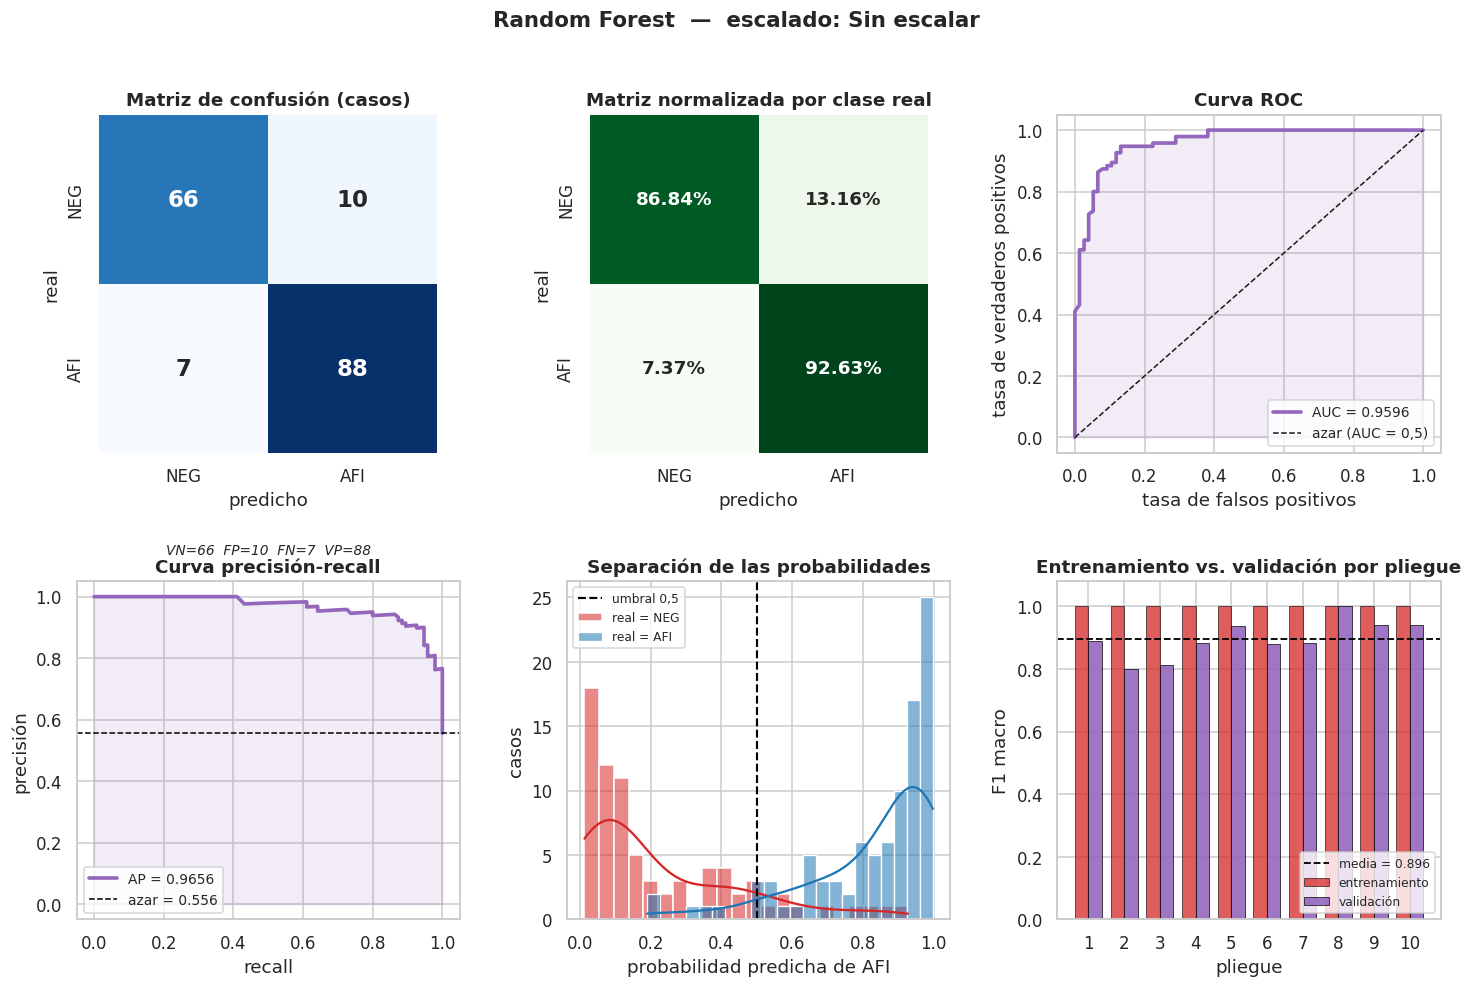


  ANÁLISIS ESPECÍFICO DE ESTE MODELO
  ------------------------------------------------------------------------------------


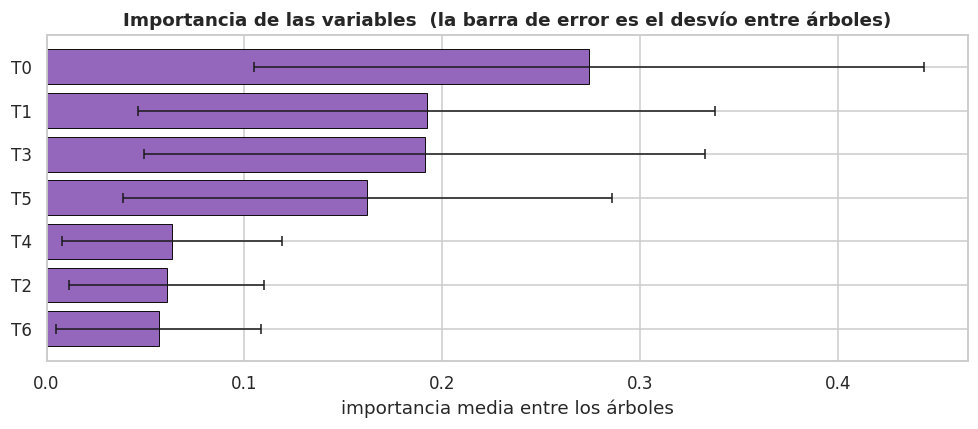

  El bosque tiene 400 árboles.
  Variables ordenadas por importancia:
    T0            0.2741  ± 0.1692
    T1            0.1920  ± 0.1457
    T3            0.1910  ± 0.1415
    T5            0.1619  ± 0.1235
    T4            0.0636  ± 0.0556
    T2            0.0606  ± 0.0494
    T6            0.0567  ± 0.0518

  Comparado con el árbol único del punto 10, el bosque reparte la
  importancia entre más variables: cada árbol ve solo un subconjunto en cada
  corte, así que las variables secundarias tienen oportunidad de mostrar lo
  que aportan.


In [23]:
from sklearn.ensemble import RandomForestClassifier


def grafico_bosque(pipeline_ajustado, color):
    modelo = pipeline_ajustado.named_steps["modelo"]

    importancias = pd.DataFrame({
        "variable": predictoras,
        "importancia": modelo.feature_importances_,
        "desvio": np.std([arbol.feature_importances_ for arbol in modelo.estimators_], axis=0),
    }).sort_values("importancia", ascending=True)

    fig, eje = plt.subplots(figsize=(9, 4))
    eje.barh(importancias["variable"], importancias["importancia"],
             xerr=importancias["desvio"], color=color,
             edgecolor="black", linewidth=0.6, capsize=3, error_kw={"linewidth": 1})
    eje.set_xlabel("importancia media entre los árboles")
    eje.set_title("Importancia de las variables  (la barra de error es el desvío entre árboles)")
    plt.tight_layout()
    plt.show()

    print(f"  El bosque tiene {len(modelo.estimators_)} árboles.")
    print("  Variables ordenadas por importancia:")
    for _, fila in importancias.sort_values("importancia", ascending=False).iterrows():
        print(f"    {fila['variable']:<12} {fila['importancia']:>7.4f}  ± {fila['desvio']:.4f}")
    print()
    print("  Comparado con el árbol único del punto 10, el bosque reparte la")
    print("  importancia entre más variables: cada árbol ve solo un subconjunto en cada")
    print("  corte, así que las variables secundarias tienen oportunidad de mostrar lo")
    print("  que aportan.")


registrar_modelo(
    "Random Forest",
    RandomForestClassifier(n_estimators=400, random_state=SEMILLA, n_jobs=1),
    color="#9467bd",
    nota="Conjunto de árboles; corrige la inestabilidad del árbol único; no es legible.",
    grafico_extra=grafico_bosque,
)

tabla_bosque = evaluar_modelo("Random Forest")

---
<a id="sec-12"></a>
# 12. Modelo 5 — XGBoost

<a id="sec-12-1"></a>
## 12.1 Presentación del modelo

**Cómo funciona.** XGBoost (*eXtreme Gradient Boosting*) también es un conjunto de árboles, como el
Random Forest, pero los arma con la lógica opuesta:

| | Random Forest (*bagging*) | XGBoost (*boosting*) |
|---|---|---|
| Cómo se construyen los árboles | En paralelo, independientes entre sí | **En secuencia**: cada uno depende de los anteriores |
| Qué aprende cada árbol | La clase, sobre una muestra distinta | **Los errores** que dejaron los árboles anteriores |
| Cómo son los árboles | Profundos, sin podar | Chicos: de 1 a 6 niveles |
| Cómo se combinan | Votan, y todos pesan igual | Se **suman**, cada uno achicado por la tasa de aprendizaje |
| Qué ataca | La varianza | El sesgo |
| ¿Agregar árboles puede empeorarlo? | No | **Sí** |

La idea del *boosting*: el primer árbol hace una predicción floja, apenas mejor que el azar. El
segundo no aprende la clase sino **en qué se equivocó el primero**, y su salida se suma a la del
primero. El tercero aprende lo que todavía queda mal después de los dos, y así sucesivamente. Cada
árbol es un "aprendiz débil"; la suma es fuerte.

### El *gradient* del nombre

Lo que aprende cada árbol nuevo es el **gradiente de la función de pérdida** —para clasificación
binaria, el *log loss* del punto 7.3—. En castellano: para cada caso, cuánto y hacia dónde habría
que mover la predicción para que la pérdida baje. Para el log loss ese gradiente es simplemente
$p - y$, la diferencia entre la probabilidad predicha y la clase real. Así que cada árbol nuevo
apunta a los casos en los que el conjunto se está equivocando, y con la fuerza de cuánto se
equivoca. Es descenso por gradiente, pero en lugar de mover coeficientes se agregan árboles.

La predicción final es una suma en la escala de los *log-odds* —la misma escala de la regresión
logística del punto 8—, que después pasa por la sigmoide:

$$F(x) = F_0 + \eta \sum_{m=1}^{M} f_m(x) \qquad\qquad P(y=1 \mid x) = \frac{1}{1 + e^{-F(x)}}$$

donde cada $f_m$ es un árbol, $M$ es la cantidad de árboles (`n_estimators`) y $\eta$ es la **tasa de
aprendizaje** (`learning_rate`).

### Qué agrega XGBoost sobre el *gradient boosting* clásico

(scikit-learn tiene el clásico como `GradientBoostingClassifier`.)

1. **Regularización dentro del objetivo.** Además de la pérdida, penaliza la cantidad de hojas
   (`gamma`) y el tamaño de los valores de cada hoja (`reg_lambda` es L2, `reg_alpha` es L1). Es la
   misma idea de la L2 de la logística, aplicada a árboles.
2. **Usa también la segunda derivada de la pérdida** (un paso de Newton, no solo la pendiente). Elige
   cortes y valores de hoja con más información, y por eso converge con menos árboles.
3. **Ingeniería.** Histogramas para buscar cortes rápido, paralelismo dentro de cada árbol y manejo
   nativo de valores faltantes. Es la razón por la que dominó las competencias de datos tabulares
   desde 2015.

### Ventajas y desventajas

| A favor | En contra |
|---|---|
| Suele ser el mejor en datos tabulares medianos y grandes | Muchos hiperparámetros, y además interactúan entre sí |
| Regularización incorporada | **Sí sobreajusta** si se lo deja correr: hay que frenar `n_estimators` |
| Indiferente a la escala | Con pocos datos su ventaja se diluye: necesita casos para aprender "errores de errores" |
| Maneja valores faltantes solo | No es legible: cientos de árboles que se suman |
| Rápido y paralelizable | No es parte de scikit-learn: es una librería más que mantener |
| Varios tipos de importancia de variables | Sus probabilidades no siempre salen bien calibradas |

### Dónde se usa en la práctica

Riesgo crediticio y detección de fraude en bancos y fintech, predicción de demanda, tarificación de
seguros, y ordenamiento de resultados de búsqueda y recomendaciones —XGBoost tiene objetivos
específicos de *ranking*—. Durante años fue el algoritmo que más competencias de Kaggle ganó con datos
tabulares. LightGBM y CatBoost son sus hermanos y ocupan el mismo nicho.

<a id="sec-12-2"></a>
## 12.2 Los hiperparámetros

| Parámetro | Qué controla | Efecto de subirlo |
|---|---|---|
| `n_estimators` | Cuántos árboles (rondas de boosting) | **A diferencia del bosque, más no es siempre mejor**: pasado cierto punto empieza a ajustar el ruido |
| `learning_rate` (η) | Cuánto aporta cada árbol | Aprende más rápido y sobreajusta antes |
| `max_depth` | La profundidad de cada árbol | Más interacciones: con 1, cada árbol mira una sola variable; con 3, interacciones de hasta tres |
| `min_child_weight` | Cuánta "evidencia" mínima necesita una hoja | Árboles más conservadores. Es el pariente de `min_samples_leaf` |
| `subsample` | Qué fracción de las filas ve cada árbol | Por debajo de 1 agrega el azar del *bagging*: menos varianza |
| `colsample_bytree` | Qué fracción de las variables ve cada árbol | Lo mismo que `max_features` del bosque |
| `reg_lambda`, `reg_alpha`, `gamma` | Regularización L2, L1 y costo por hoja | Modelo más simple |
| `scale_pos_weight` | El peso de la clase positiva | Para desbalance fuerte; acá las clases están 56/44 y no hace falta |

### La tasa de aprendizaje y la cantidad de árboles van juntas

`learning_rate` achica la contribución de cada árbol. Con 0,3 —el valor por defecto— cada árbol
corrige mucho, y en pocos pasos el modelo ya está memorizando. Con 0,05 cada árbol corrige un poco y
hacen falta más. La regla práctica: **tasa baja y más árboles generaliza mejor**, a costa de tiempo.
Lo que no se puede es elegir uno sin mirar el otro: duplicar la tasa equivale, aproximadamente, a
dividir por dos la cantidad de árboles necesaria.

### Cómo se sobreajusta este modelo

De la manera opuesta al bosque: **agregando árboles**. Cada árbol nuevo corrige errores de
entrenamiento; cuando ya no quedan errores reales que corregir, empieza a corregir el ruido. El score
de entrenamiento sigue subiendo, el de validación se estanca y después baja.

<a id="sec-12-3"></a>
## 12.3 Optimización

Este modelo pide búsqueda: tiene muchos hiperparámetros, y con los valores por defecto (tasa 0,3 y
100 árboles de profundidad 6) memoriza enseguida un dataset de este tamaño. Se aplica la regla del
punto 7.6.

**Qué se busca**

| Hiperparámetro | Valores | Por qué esos |
|---|---|---|
| `max_depth` | 1, 2, 3, 4 | Cuántas variables puede combinar cada árbol. De árboles de un solo corte a interacciones de cuatro |
| `n_estimators` | 25, 50, 100, 200, 400 | Cuánto se corrige. Cada valor duplica más o menos al anterior: con una tasa fija, lo que importa es el orden de magnitud |

Son 20 combinaciones, y son los dos mandos de la complejidad del boosting.

En producción, la cantidad de árboles se frena con *early stopping*: se deja de agregar árboles
cuando la validación deja de mejorar. Meterlo dentro de la validación cruzada de este cuaderno
complicaría el `Pipeline`, así que hacemos lo equivalente de manera explícita: buscamos
`n_estimators` en la grilla y miramos la curva.

**Qué queda fijo, y por qué**

- `learning_rate=0.05`: se compensa con la cantidad de árboles (punto 12.2), así que buscar los dos
  sería redundante. Baja, para que la curva de `n_estimators` sea suave y se vea dónde empieza el
  sobreajuste.
- `subsample=0.8` y `colsample_bytree=0.8`: cada árbol ve el 80 % de las filas y de las variables.
  Es un poco del azar del bosque para bajar la varianza; regulariza, pero no es el mando principal.
- `min_child_weight`, `reg_lambda`, `reg_alpha` y `gamma` en sus valores por defecto: son
  regularización fina, y con árboles chicos y tasa baja no hace falta tocarla.
- `scale_pos_weight` sin tocar (clases 56/44); `eval_metric="logloss"`, la pérdida de la
  clasificación binaria; `n_jobs=1` y la `SEMILLA`, como todos los demás.

**Sin escalado**: es un modelo de árboles, así que la búsqueda se hace sobre los datos tal como
vienen.

**Más simple significa árboles menos profundos** y, si empatan, **menos árboles**.

**Una expectativa honesta.** 171 filas es poco para *boosting*: cada árbol aprende de los residuos de
los anteriores, y con 154 filas por pliegue esos residuos se vuelven ruido enseguida. Además, la
regresión logística ya mostró que una frontera lineal funciona muy bien en estos datos. No sería
raro que XGBoost no le gane. Si pasa, no es un fracaso del modelo: es la confirmación de lo que dice
el punto 8, que la complejidad tiene que ganarse su lugar.

<a id="sec-12-4"></a>
## 12.4 Código de la búsqueda

XGBoost no es parte de scikit-learn, pero respeta su interfaz —`fit`, `predict`, `predict_proba`—,
así que entra en la búsqueda, en el `Pipeline` y en el catálogo como cualquier otro. Colab lo trae
instalado; fuera de Colab, `pip install xgboost`.

In [25]:
import xgboost
from xgboost import XGBClassifier

print(f"XGBoost : {xgboost.__version__}")
print()

# Lo que queda fijo (punto 12.3)
PARAMS_XGB_FIJOS = dict(
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEMILLA,
    n_jobs=1,
)

# Lo que se busca: de qué profundidad y cuántos árboles
grilla_xgb = {
    "max_depth": [1, 2, 3, 4],
    "n_estimators": [25, 50, 100, 200, 400],
}

busqueda_xgb = buscar_hiperparametros(
    XGBClassifier(**PARAMS_XGB_FIJOS),
    grilla_xgb,
    orden_simplicidad=[("max_depth", "menor"), ("n_estimators", "menor")],
    titulo="XGBOOST",
)

XGBoost : 3.4.1

  BÚSQUEDA DE HIPERPARÁMETROS — XGBOOST
  Hiperparámetros buscados   : ['max_depth', 'n_estimators']
  Combinaciones evaluadas    : 20
  Ajustes realizados         : 200
  Validación                 : el cv del punto 0.4 (10 pliegues), F1 macro

  Máximo                     : {'max_depth': 1, 'n_estimators': 400}
      F1 macro               : 0.9139
      error estándar         : 0.0224  (desvío 0.0709 / raíz de 10)
  Umbral de empate técnico   : 0.8915
  Combinaciones en la franja : 7 de 20

  ELEGIDA (la más simple)    : {'max_depth': 1, 'n_estimators': 200}
      F1 macro               : 0.9068
      Cede 0.0071 de F1 frente al máximo: menos que un error estándar,
      así que la diferencia no se distingue del ruido.
      Borde de la grilla: max_depth = 1 es el valor más simple probado.

  La franja de empate técnico, de la más simple a la más compleja:


,max_depth,n_estimators,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,1,200,0.9592,0.9068,0.0249,0.0523,ELEGIDA
1,1,400,0.9677,0.9139,0.0224,0.0538,máximo
2,2,100,0.9670,0.8954,0.0243,0.0716,
3,3,100,0.9763,0.8956,0.0241,0.0807,
4,3,200,1.0000,0.9083,0.0189,0.0917,
5,4,100,0.9914,0.9024,0.0187,0.0890,
6,4,200,1.0000,0.8966,0.0183,0.1034,


  Las cinco combinaciones con MÁS sobreajuste (mayor brecha):


,max_depth,n_estimators,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,3,400,1.0000,0.8788,0.0198,0.1212,
1,2,400,1.0000,0.8849,0.0222,0.1151,
2,4,400,1.0000,0.8905,0.0214,0.1095,
3,4,200,1.0000,0.8966,0.0183,0.1034,
4,4,50,0.9709,0.8762,0.0257,0.0947,


<a id="sec-12-5"></a>
## 12.5 Resultado de la búsqueda

Una curva por profundidad. A la izquierda, F1 macro en validación (línea llena) y en entrenamiento
(punteada) a medida que se agregan árboles, con la línea del umbral de empate y la combinación
elegida marcada con una estrella. A la derecha, la brecha.

Qué mirar: la línea punteada sube sin parar, y la brecha crece con la cantidad de árboles, más rápido
cuanto más profundos son. Es el contraste directo con el Random Forest del punto 11.

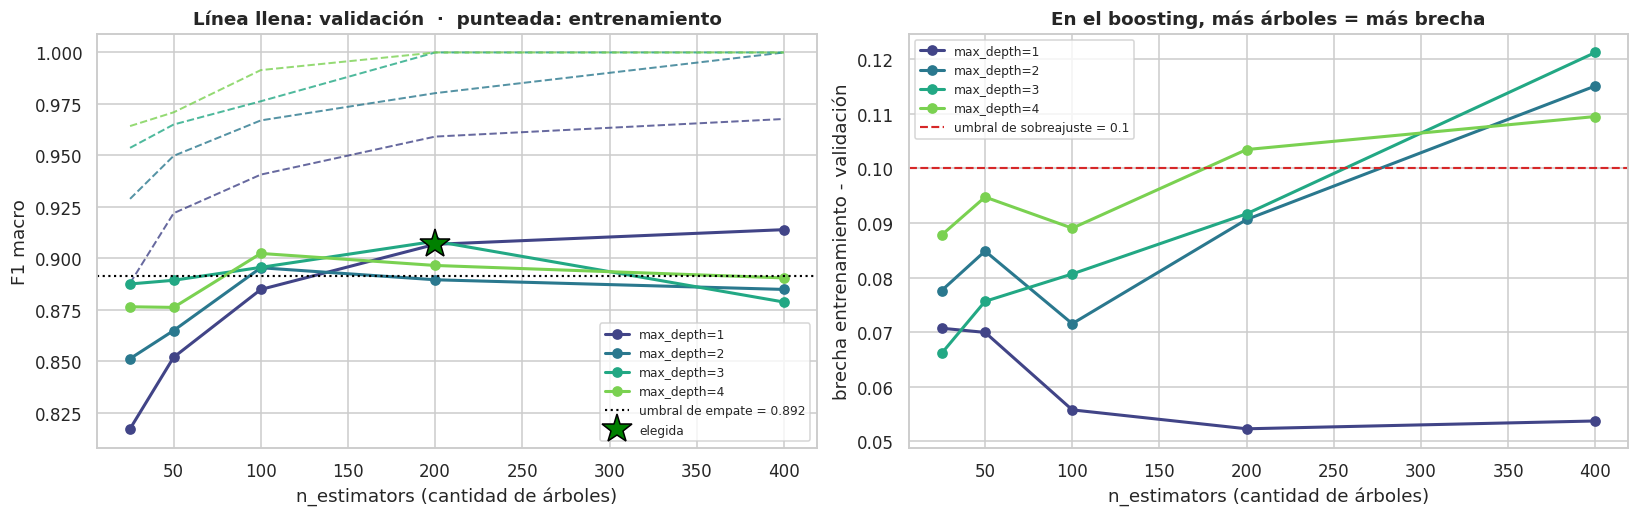

  Con max_depth=1, de 25 a 400 árboles:
    entrenamiento : 0.8880 -> 0.9677
    validación    : 0.8172 -> 0.9139

  El contraste con el Random Forest del punto 11: allá agregar árboles nunca
  empeora el modelo porque los árboles se PROMEDIAN. Acá se SUMAN, y cada uno
  corrige algo más del entrenamiento.


In [26]:
tabla_xgb = busqueda_xgb["tabla"]
profundidades = sorted(tabla_xgb["max_depth"].unique())
paleta_prof = sns.color_palette("viridis", len(profundidades))
prof_elegida = busqueda_xgb["elegidos"]["max_depth"]
arboles_elegidos = busqueda_xgb["elegidos"]["n_estimators"]
f1_elegida = tabla_xgb.loc[busqueda_xgb["i_elegida"], "f1_validacion"]

fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
for prof, color_p in zip(profundidades, paleta_prof):
    curva = tabla_xgb[tabla_xgb["max_depth"] == prof].sort_values("n_estimators")
    ejes[0].plot(curva["n_estimators"], curva["f1_validacion"], "o-", color=color_p,
                 linewidth=2, label=f"max_depth={prof}")
    ejes[0].plot(curva["n_estimators"], curva["f1_entrena"], "--", color=color_p,
                 linewidth=1.3, alpha=0.8)
    ejes[1].plot(curva["n_estimators"], curva["brecha"], "o-", color=color_p,
                 linewidth=2, label=f"max_depth={prof}")

ejes[0].axhline(busqueda_xgb["umbral"], color="black", linestyle=":", linewidth=1.4,
                label=f"umbral de empate = {busqueda_xgb['umbral']:.3f}")
ejes[0].plot(arboles_elegidos, f1_elegida, "*", color="green", markersize=20,
             markeredgecolor="black", label="elegida")
ejes[0].set_xlabel("n_estimators (cantidad de árboles)")
ejes[0].set_ylabel("F1 macro")
ejes[0].set_title("Línea llena: validación  ·  punteada: entrenamiento")
ejes[0].legend(fontsize=8, loc="lower right")

ejes[1].axhline(BRECHA_SOBREAJUSTE, color="#d62728", linestyle="--", linewidth=1.4,
                label=f"umbral de sobreajuste = {BRECHA_SOBREAJUSTE}")
ejes[1].set_xlabel("n_estimators (cantidad de árboles)")
ejes[1].set_ylabel("brecha entrenamiento - validación")
ejes[1].set_title("En el boosting, más árboles = más brecha")
ejes[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

curva_elegida = tabla_xgb[tabla_xgb["max_depth"] == prof_elegida].sort_values("n_estimators")
print(f"  Con max_depth={prof_elegida}, de {curva_elegida['n_estimators'].min()} a "
      f"{curva_elegida['n_estimators'].max()} árboles:")
print(f"    entrenamiento : {curva_elegida['f1_entrena'].iloc[0]:.4f} -> "
      f"{curva_elegida['f1_entrena'].iloc[-1]:.4f}")
print(f"    validación    : {curva_elegida['f1_validacion'].iloc[0]:.4f} -> "
      f"{curva_elegida['f1_validacion'].iloc[-1]:.4f}")
print()
print("  El contraste con el Random Forest del punto 11: allá agregar árboles nunca")
print("  empeora el modelo porque los árboles se PROMEDIAN. Acá se SUMAN, y cada uno")
print("  corrige algo más del entrenamiento.")

<a id="sec-12-6"></a>
## 12.6 Ejecución en el catálogo

Registramos XGBoost con la combinación elegida. Dos detalles antes de evaluarlo:

- **La etiqueta tiene que ser 0/1.** XGBoost no acepta clases en texto. Es otra razón por la que el
  punto 2.2 de la Parte 2A dejó la columna `y` codificada.
- Como el árbol y el bosque, se le aplican igual los tres escalados, para **verificar** que es
  indiferente. XGBoost trabaja internamente en `float32`; con estos datos eso no debería cambiar
  ningún corte, pero si alguna vez aparece una diferencia del orden de 0,0001 o menor, viene de ahí y
  no de la maquinaria.

Su gráfico propio es la **importancia de las variables medida de dos maneras**, porque XGBoost las
reporta separadas y la diferencia enseña algo:

- **Ganancia** (`gain`): cuánto bajó la pérdida, en promedio, cada vez que se cortó por esa
  variable. Es la que se parece a la importancia del árbol y del bosque.
- **Frecuencia** (`weight`): cuántas veces se usó la variable para cortar, sumando todos los árboles.

Una variable con mucha frecuencia y poca ganancia es una que el modelo usa para ajustes finos —y con
pocos datos, los ajustes finos suelen ser ruido—. Una con mucha ganancia y poca frecuencia hace pocos
cortes, pero decisivos.

Registrado: XGBoost
    escalados a probar : ['Sin escalar', 'Min-Max', 'Z-score']
    hiperparámetros    : {'max_depth': 1, 'n_estimators': 200}  (búsqueda del punto 7.6)
    Boosting: árboles chicos en secuencia, cada uno corrige al anterior; no es legible.
  XGBOOST
  Boosting: árboles chicos en secuencia, cada uno corrige al anterior; no es legible.

  EFECTO DEL ESCALADO
  ------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,f1_macro,roc_auc,desvio_pliegues,brecha
escalado,,,,,,
Sin escalar,0.9123,0.9092,0.9108,0.9561,0.0788,0.0523
Min-Max,0.9123,0.9092,0.9108,0.9561,0.0788,0.0523
Z-score,0.9123,0.9092,0.9108,0.9561,0.0788,0.0523


  El escalado NO cambia absolutamente nada en este modelo.
  Es lo esperado en modelos basados en árboles: los cortes se hacen por
  umbrales, y Min-Max y Z-score son transformaciones monótonas que no
  alteran el orden de los valores, así que los cortes caen en el mismo lugar.

  MEJOR VARIANTE: XGBoost + Sin escalar

  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)
  ------------------------------------------------------------------------------------
    Rendimiento general
      Accuracy               0.9123    proporción de aciertos sobre el total
      Balanced accuracy      0.9092    promedio del recall de cada clase
    Clase positiva (AFI)
      Precisión              0.9082    de los predichos positivos, cuántos lo eran
      Recall                 0.9368    de los positivos reales, cuántos detectó
      F1-score               0.9223    media armónica de precisión y recall
    Promediadas entre clases
      Precisión macro        0.9130    promedio simple entre 

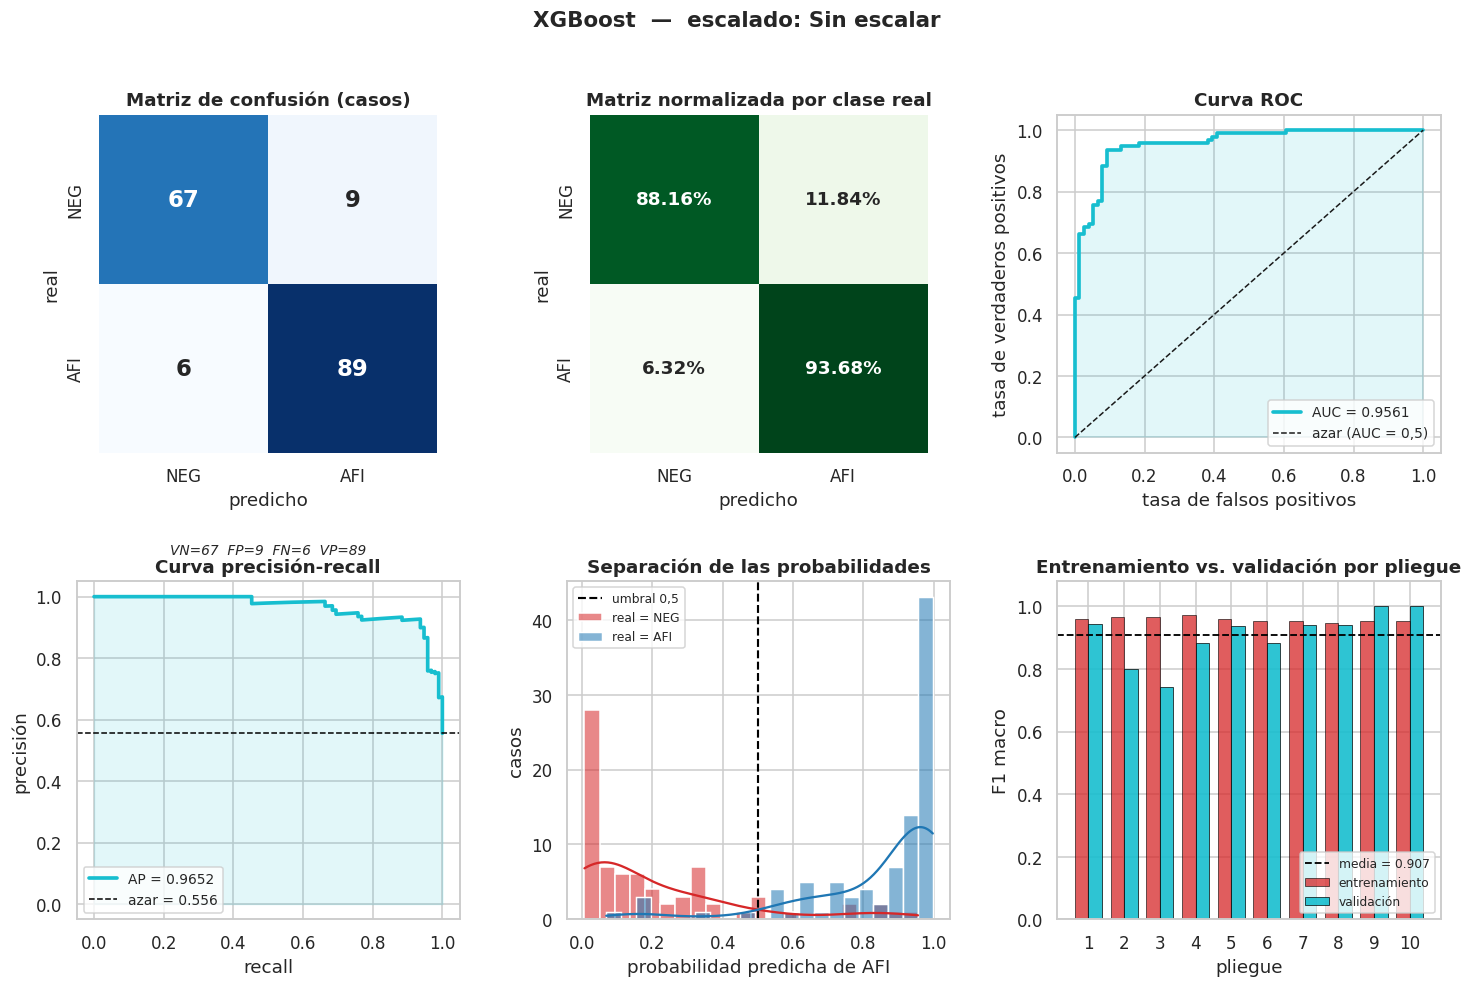


  ANÁLISIS ESPECÍFICO DE ESTE MODELO
  ------------------------------------------------------------------------------------


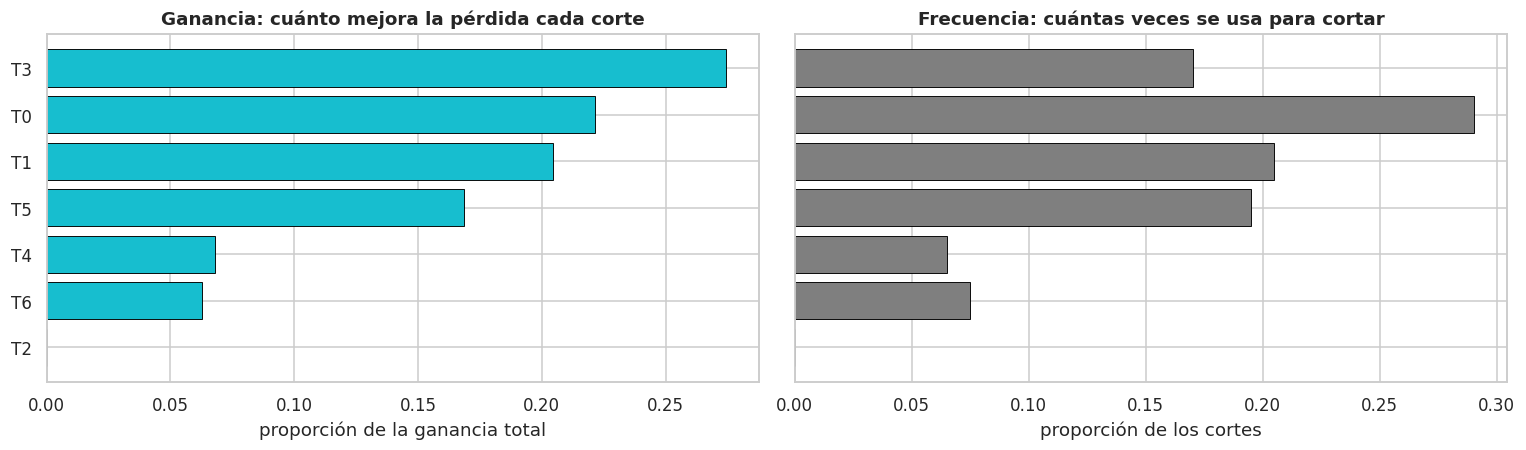

  200 árboles de profundidad máxima 1, tasa de aprendizaje 0.05.

    Variable     Ganancia   Frecuencia   Ganancia/Frec.
    T3             0.2742       0.1700             1.61
    T0             0.2215       0.2900             0.76
    T1             0.2045       0.2050             1.00
    T5             0.1687       0.1950             0.87
    T4             0.0681       0.0650             1.05
    T6             0.0630       0.0750             0.84
    T2             0.0000       0.0000       (no usada)

  Un cociente mayor que 1 indica cortes pocos y decisivos; menor que 1,
  muchos cortes de ajuste fino. Comparalo con la importancia del bosque del
  punto 11: si las dos familias de árboles coinciden en las variables
  principales, esa coincidencia es más confiable que cualquiera de las dos.


In [27]:
def importancias_xgb(modelo, tipo):
    # get_score() devuelve solo las variables que se usaron, con su nombre si el
    # modelo se entrenó con un DataFrame (T0, T1...) o como f0, f1... si el escalador
    # del Pipeline lo convirtió en matriz. Este helper cubre los dos casos.
    puntajes = modelo.get_booster().get_score(importance_type=tipo)
    valores = [puntajes.get(variable, puntajes.get(f"f{i}", 0.0))
               for i, variable in enumerate(predictoras)]
    serie = pd.Series(valores, index=predictoras, dtype=float)
    return serie / serie.sum() if serie.sum() > 0 else serie


def grafico_xgboost(pipeline_ajustado, color):
    modelo = pipeline_ajustado.named_steps["modelo"]
    ganancia = importancias_xgb(modelo, "gain")
    frecuencia = importancias_xgb(modelo, "weight")
    orden = ganancia.sort_values(ascending=True).index

    fig, ejes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
    ejes[0].barh(orden, ganancia[orden], color=color, edgecolor="black", linewidth=0.6)
    ejes[0].set_xlabel("proporción de la ganancia total")
    ejes[0].set_title("Ganancia: cuánto mejora la pérdida cada corte")
    ejes[1].barh(orden, frecuencia[orden], color="#7f7f7f", edgecolor="black", linewidth=0.6)
    ejes[1].set_xlabel("proporción de los cortes")
    ejes[1].set_title("Frecuencia: cuántas veces se usa para cortar")
    plt.tight_layout()
    plt.show()

    print(f"  {modelo.n_estimators} árboles de profundidad máxima {modelo.max_depth}, "
          f"tasa de aprendizaje {modelo.learning_rate}.")
    print()
    print(f"    {'Variable':<10} {'Ganancia':>10} {'Frecuencia':>12} {'Ganancia/Frec.':>16}")
    for variable in ganancia.sort_values(ascending=False).index:
        g, f = ganancia[variable], frecuencia[variable]
        cociente = f"{g / f:>16.2f}" if f > 0 else f"{'(no usada)':>16}"
        print(f"    {variable:<10} {g:>10.4f} {f:>12.4f} {cociente}")
    print()
    print("  Un cociente mayor que 1 indica cortes pocos y decisivos; menor que 1,")
    print("  muchos cortes de ajuste fino. Comparalo con la importancia del bosque del")
    print("  punto 11: si las dos familias de árboles coinciden en las variables")
    print("  principales, esa coincidencia es más confiable que cualquiera de las dos.")


registrar_modelo(
    "XGBoost",
    XGBClassifier(**PARAMS_XGB_FIJOS, **busqueda_xgb["elegidos"]),
    color="#17becf",
    nota="Boosting: árboles chicos en secuencia, cada uno corrige al anterior; no es legible.",
    grafico_extra=grafico_xgboost,
    busqueda=busqueda_xgb,
)

tabla_xgb = evaluar_modelo("XGBoost")

---
<a id="sec-13"></a>
# 13. Modelo 6 — Máquina de Vectores de Soporte (SVM)

<a id="sec-13-1"></a>
## 13.1 Presentación del modelo

**Cómo funciona.** Una SVM busca la frontera que separa las dos clases con el **mayor margen
posible**: la "calle" más ancha que se puede trazar entre ellas. La frontera es la línea del medio de
esa calle.

Lo distintivo es **quién decide dónde va la calle**: solamente los casos que quedan sobre el borde o
adentro de ella. Esos casos se llaman **vectores de soporte**, y le dan el nombre al modelo. El resto
del dataset podría moverse —sin cruzar la calle— y la frontera no cambiaría ni un milímetro. Es lo
opuesto de la regresión logística, donde cada uno de los 171 casos influye en los coeficientes.

### El truco del *kernel*

Una SVM a secas traza una frontera recta (un hiperplano). Para fronteras curvas se podrían fabricar
variables nuevas —cuadrados, productos entre variables— y buscar la recta en ese espacio más grande,
donde lo que era curvo pasa a ser separable por un plano. El *kernel* hace exactamente eso **sin
construir las variables nuevas**: la SVM solo necesita saber cuán **parecidos** son dos casos entre
sí, y el kernel calcula ese parecido directamente.

El más usado, y el que usamos acá, es el **RBF** (*radial basis function*, o gaussiano):

$$K(x, x') = e^{-\gamma \, \lVert x - x' \rVert^2}$$

Vale 1 si dos casos son idénticos y cae hacia 0 a medida que se alejan. Qué tan rápido cae lo decide
`gamma`, y se explica en el punto 13.2.

### Por qué este modelo, en este cuaderno

Completa el mapa de familias. Hasta acá hay un modelo lineal probabilístico (la logística), uno
basado en instancias (KNN) y tres basados en árboles (árbol, bosque y XGBoost). La SVM es la cuarta
familia: **márgenes y kernels**.

Y responde una pregunta que dejó abierta la logística. Si una frontera recta ya funciona tan bien,
¿curvarla mejora algo? La SVM RBF puede curvar la frontera tanto como haga falta, o casi nada si
`gamma` es bajo. **Si la búsqueda elige `gamma` bajo y `C` moderado, los datos están diciendo que no
hace falta curvar.** Si elige valores altos y aun así no le gana a la logística, dicen lo mismo de
otra manera.

### Ventajas y desventajas

| A favor | En contra |
|---|---|
| La frontera de margen máximo es robusta: solo dependen de ella los casos del borde | Escala mal con muchas filas: el costo crece entre el cuadrado y el cubo de *n* |
| Con kernel capta no linealidades sin fabricar variables | No da probabilidades nativas |
| Rinde bien con pocos casos y muchas variables | `C` y `gamma` interactúan: hay que buscarlos juntos |
| Regularizada por diseño | **Imprescindible** escalar |
| Pocos hiperparámetros | Con kernel RBF no es interpretable |

### Dónde se usa en la práctica

Clasificación de texto: antes de los modelos de lenguaje, una SVM lineal sobre TF-IDF era el estándar
para filtrar spam o clasificar documentos —y este proyecto, en el fondo, clasifica textos—.
Bioinformática, donde hay pocas muestras y miles de genes. Reconocimiento de dígitos manuscritos e
imágenes antes del *deep learning*. Y detección de anomalías, con la variante *One-Class SVM*.

<a id="sec-13-2"></a>
## 13.2 Los hiperparámetros

| Parámetro | Qué controla | Efecto de subirlo |
|---|---|---|
| `C` | Cuánto se castiga a los casos dentro de la calle o mal clasificados | Calle más angosta, frontera más ajustada: más riesgo de sobreajuste |
| `kernel` | La forma de la frontera: `"linear"`, `"rbf"`, `"poly"` | — |
| `gamma` | El alcance del parecido entre casos (RBF) | Frontera más sinuosa y local: más riesgo de sobreajuste |
| `class_weight` | Cuánto pesa cada clase | `"balanced"` compensa el desbalance |
| `probability` | Si se calibra una sigmoide para dar probabilidades | Hace falta `True` para entrar al catálogo (punto 7.5) |

### El margen blando y el parámetro `C`

Con datos reales las clases casi nunca se separan limpias, así que la SVM tolera casos que invaden la
calle o que quedan del lado equivocado, pero los castiga. `C` dice cuánto:

- **`C` bajo**: castigo leve. Calle ancha que acepta errores; frontera suave. Más sesgo.
- **`C` alto**: castigo fuerte. Calle angosta que se retuerce para clasificar bien cada caso de
  entrenamiento. Más varianza.

Es el mismo nombre y el mismo sentido que el `C` de la regresión logística del punto 8: el inverso de
la regularización.

### El alcance del kernel: `gamma`

- **`gamma` alto**: el parecido se desvanece enseguida; cada caso solo "ve" a sus vecinos
  inmediatos. Frontera muy sinuosa, que rodea casos sueltos. Es el equivalente a un KNN con *k*
  chico: sobreajuste.
- **`gamma` bajo**: todos los casos se parecen un poco a todos. Frontera casi recta. En el extremo,
  la SVM RBF se comporta como una lineal.

### Cómo se sobreajusta este modelo

Con `C` y `gamma` altos a la vez. Por eso **se buscan juntos**: se compensan. Una frontera sinuosa
(gamma alto) con mucho castigo a los errores (C alto) es el peor caso de memorización, y la misma
sinuosidad con C bajo puede quedar razonable.

<a id="sec-13-3"></a>
## 13.3 Optimización

Este modelo pide búsqueda: `C` y `gamma` deciden si la frontera es casi recta o se retuerce alrededor
de cada caso, y no hay un valor por defecto que sirva para cualquier dataset. Se aplica la regla del
punto 7.6.

**Qué se busca**

| Hiperparámetro | Valores | Por qué esos |
|---|---|---|
| `C` | 0,1 · 1 · 10 · 100 | Escala logarítmica: de una calle muy ancha a una muy angosta |
| `gamma` | 0,001 · 0,01 · 0,1 · 1 | Escala logarítmica: de una frontera casi recta a una muy local |

Son 16 combinaciones. El valor por defecto de `gamma`, `"scale"`, no entra en la grilla porque no es
un número y no se podría ordenar por simplicidad; igual queda cubierto: con Z-score vale
$1/7 \approx 0{,}14$, entre 0,1 y 1.

**Qué queda fijo, y por qué**

- `kernel="rbf"`: es el modelo que estamos presentando. Una SVM lineal sería otra versión de la
  logística.
- `class_weight` sin tocar: las clases están 56/44.
- `probability`: la búsqueda va **sin** `probability=True`. El puntaje es F1 macro, que sale de
  `predict()`, y así cada ajuste es varias veces más rápido. En el catálogo sí se activa (punto 13.6).

**Con qué escalado se busca.** Con Z-score, dentro de un `Pipeline`, como en KNN: el kernel RBF es una
distancia, así que vale todo lo del punto 9. Y hay un detalle más fino: **un valor numérico de `gamma`
solo tiene sentido para una escala dada**. `gamma=0.1` sobre variables con Z-score (desvío 1) es una
cosa; sobre nuestras proporciones sin escalar, cuyas distancias son mucho más chicas, es otra
completamente distinta. En el catálogo, la variante "Sin escalar" va a aplicar el `gamma` elegido
sobre distancias mucho más chicas, lo que equivale a un `gamma` mucho más bajo: una frontera casi
recta. Puede salir claramente peor o, si una frontera recta ya alcanza —como sugiere la logística—,
casi igual. Cualquiera de las dos cosas dice algo, y la tabla de escalados lo muestra.

**Más simple significa `gamma` menor** —frontera menos sinuosa— y, si empatan, **`C` menor** —calle
más ancha—.

<a id="sec-13-4"></a>
## 13.4 Código de la búsqueda

In [28]:
from sklearn.svm import SVC

grilla_svm = {
    "modelo__C": [0.1, 1, 10, 100],
    "modelo__gamma": [0.001, 0.01, 0.1, 1],
}

busqueda_svm = buscar_hiperparametros(
    Pipeline([
        ("escalador", StandardScaler()),
        ("modelo", SVC(kernel="rbf", random_state=SEMILLA)),
    ]),
    grilla_svm,
    orden_simplicidad=[("gamma", "menor"), ("C", "menor")],
    titulo="SVM (kernel RBF, con Z-score)",
)

  BÚSQUEDA DE HIPERPARÁMETROS — SVM (kernel RBF, con Z-score)
  Hiperparámetros buscados   : ['C', 'gamma']
  Combinaciones evaluadas    : 16
  Ajustes realizados         : 160
  Validación                 : el cv del punto 0.4 (10 pliegues), F1 macro

  Máximo                     : {'C': 1.0, 'gamma': 0.01}
      F1 macro               : 0.9080
      error estándar         : 0.0207  (desvío 0.0655 / raíz de 10)
  Umbral de empate técnico   : 0.8873
  Combinaciones en la franja : 5 de 16

  ELEGIDA (la más simple)    : {'C': 10.0, 'gamma': 0.001}
      F1 macro               : 0.9019
      Cede 0.0061 de F1 frente al máximo: menos que un error estándar,
      así que la diferencia no se distingue del ruido.
      Borde de la grilla: gamma = 0.001 es el valor más simple probado.

  La franja de empate técnico, de la más simple a la más compleja:


,C,gamma,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,10.0000,0.0010,0.9047,0.9019,0.0222,0.0027,ELEGIDA
1,100.0000,0.0010,0.9054,0.9024,0.0241,0.0030,
2,1.0000,0.0100,0.9059,0.9080,0.0207,-0.0021,máximo
3,10.0000,0.0100,0.9068,0.8907,0.0211,0.0161,
4,0.1000,0.1000,0.9100,0.8958,0.0184,0.0142,


  Las cinco combinaciones con MÁS sobreajuste (mayor brecha):


,C,gamma,f1_entrena,f1_validacion,error_estandar,brecha,marca
0,100.0000,0.1000,0.9888,0.8521,0.0242,0.1367,
1,10.0000,1.0000,1.0000,0.8733,0.0198,0.1267,
2,100.0000,1.0000,1.0000,0.8733,0.0198,0.1267,
3,1.0000,1.0000,0.9901,0.8790,0.0194,0.1111,
4,10.0000,0.1000,0.9583,0.8565,0.0213,0.1018,


<a id="sec-13-5"></a>
## 13.5 Resultado de la búsqueda

La grilla completa como dos mapas de calor: F1 macro en validación a la izquierda y brecha a la
derecha. El recuadro punteado es el máximo; el lleno, la combinación elegida.

Qué mirar: la esquina de `C` y `gamma` altos es donde se ve la memorización —la brecha más oscura—;
y dónde cae la elegida responde la pregunta del punto 13.1, si hace falta curvar la frontera.

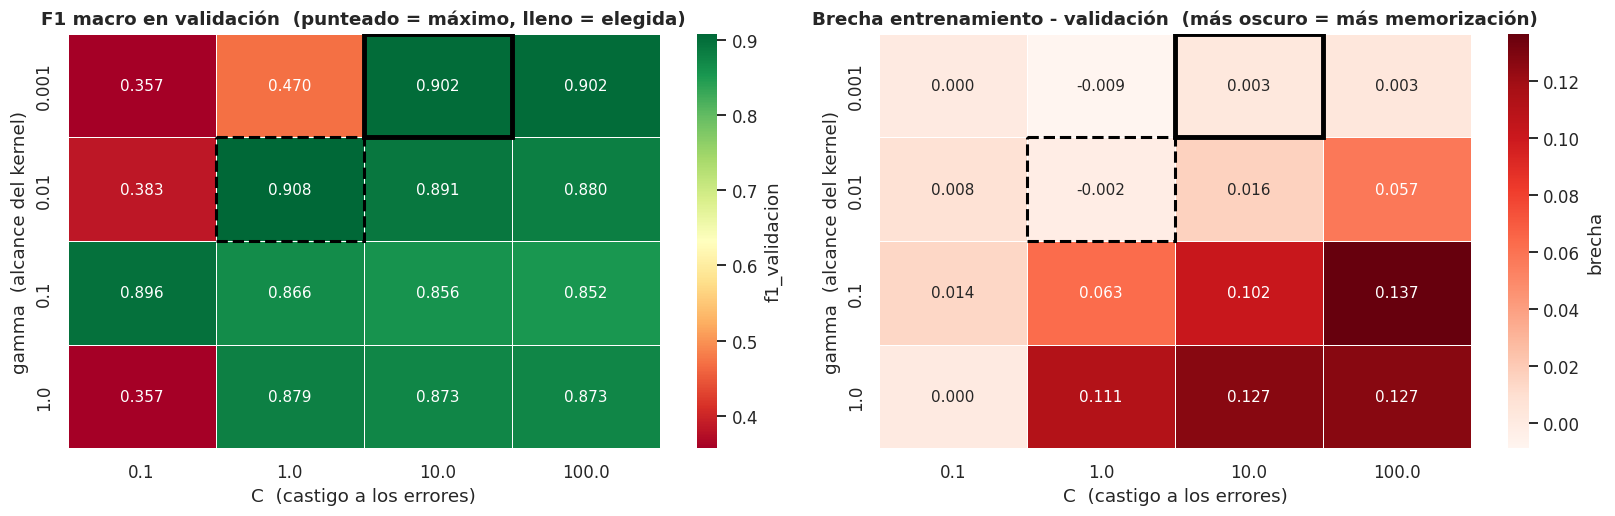

  Elegida: {'C': 10.0, 'gamma': 0.001}.
  Referencia: con Z-score, gamma='scale' equivaldría a 1/7 = 0.1429.
  El gamma elegido es bajo: una frontera casi recta. Los datos dicen que no hace
  falta curvarla, lo mismo que sugería la regresión logística.


In [29]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
dibujar_mapa_busqueda(ejes[0], busqueda_svm, "gamma", "C")
ejes[0].set_title("F1 macro en validación  (punteado = máximo, lleno = elegida)")
dibujar_mapa_busqueda(ejes[1], busqueda_svm, "gamma", "C", valor="brecha", cmap="Reds")
ejes[1].set_title("Brecha entrenamiento - validación  (más oscuro = más memorización)")
for eje in ejes:
    eje.set_xlabel("C  (castigo a los errores)")
    eje.set_ylabel("gamma  (alcance del kernel)")
plt.tight_layout()
plt.show()

gamma_elegido = busqueda_svm["elegidos"]["gamma"]
print(f"  Elegida: {busqueda_svm['elegidos']}.")
print(f"  Referencia: con Z-score, gamma='scale' equivaldría a 1/{X.shape[1]} = "
      f"{1 / X.shape[1]:.4f}.")
if gamma_elegido <= 0.01:
    print("  El gamma elegido es bajo: una frontera casi recta. Los datos dicen que no hace")
    print("  falta curvarla, lo mismo que sugería la regresión logística.")
else:
    print("  El gamma elegido no es de los más bajos: dentro del empate técnico, una frontera")
    print("  con algo de curvatura rinde mejor que una casi recta.")

<a id="sec-13-6"></a>
## 13.6 Ejecución en el catálogo

**Las probabilidades no son nativas.** Una SVM no produce probabilidades: produce una **distancia a la
frontera** (`decision_function`). Para entrar al catálogo hace falta `predict_proba()` (punto 7.5), así
que se la registra con `probability=True`: scikit-learn le ajusta encima una sigmoide —el **escalado
de Platt**— con una validación cruzada interna de 5 pliegues. Tres consecuencias:

1. Entrenar es varias veces más lento. Con 171 filas no se nota.
2. Las probabilidades son una estimación agregada, no salen del modelo. Por eso conviene mirar con
   atención el log loss y el Brier de la SVM.
3. En casos muy cerca de la frontera, `predict()` y `predict_proba() > 0,5` pueden no coincidir:
   `predict()` usa la distancia, no la sigmoide. En nuestras métricas, accuracy, F1 y MCC salen de
   `predict()`; ROC-AUC, log loss y Brier, de las probabilidades.

Su gráfico propio es **la cantidad de vectores de soporte**: qué proporción del dataset termina
decidiendo dónde va la frontera. Es la medida de complejidad propia de este modelo, como la
profundidad en el árbol o *k* en KNN.

Registrado: SVM (RBF)
    escalados a probar : ['Sin escalar', 'Min-Max', 'Z-score']
    hiperparámetros    : {'C': 10.0, 'gamma': 0.001}  (búsqueda del punto 7.6)
    Frontera de margen máximo con kernel; la deciden los casos del borde; necesita escalado.
  SVM (RBF)
  Frontera de margen máximo con kernel; la deciden los casos del borde; necesita escalado.

  EFECTO DEL ESCALADO
  ------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,f1_macro,roc_auc,desvio_pliegues,brecha
escalado,,,,,,
Sin escalar,0.5556,0.5000,0.3571,0.9686,0.0114,0.0002
Min-Max,0.5556,0.5000,0.3571,0.9663,0.0114,0.0002
Z-score,0.9064,0.9026,0.9047,0.9622,0.0703,0.0027


  Diferencia entre el mejor y el peor escalado (ROC-AUC): 0.0064

  MEJOR VARIANTE: SVM (RBF) + Sin escalar

  MÉTRICAS  (predicciones fuera de pliegue sobre los 171 casos)
  ------------------------------------------------------------------------------------
    Rendimiento general
      Accuracy               0.5556    proporción de aciertos sobre el total
      Balanced accuracy      0.5000    promedio del recall de cada clase
    Clase positiva (AFI)
      Precisión              0.5556    de los predichos positivos, cuántos lo eran
      Recall                 1.0000    de los positivos reales, cuántos detectó
      F1-score               0.7143    media armónica de precisión y recall
    Promediadas entre clases
      Precisión macro        0.2778    promedio simple entre clases
      Recall macro           0.5000    promedio simple entre clases
      F1 macro               0.3571    trata a las dos clases por igual
      F1 ponderado           0.3968    pondera por la frecuencia 

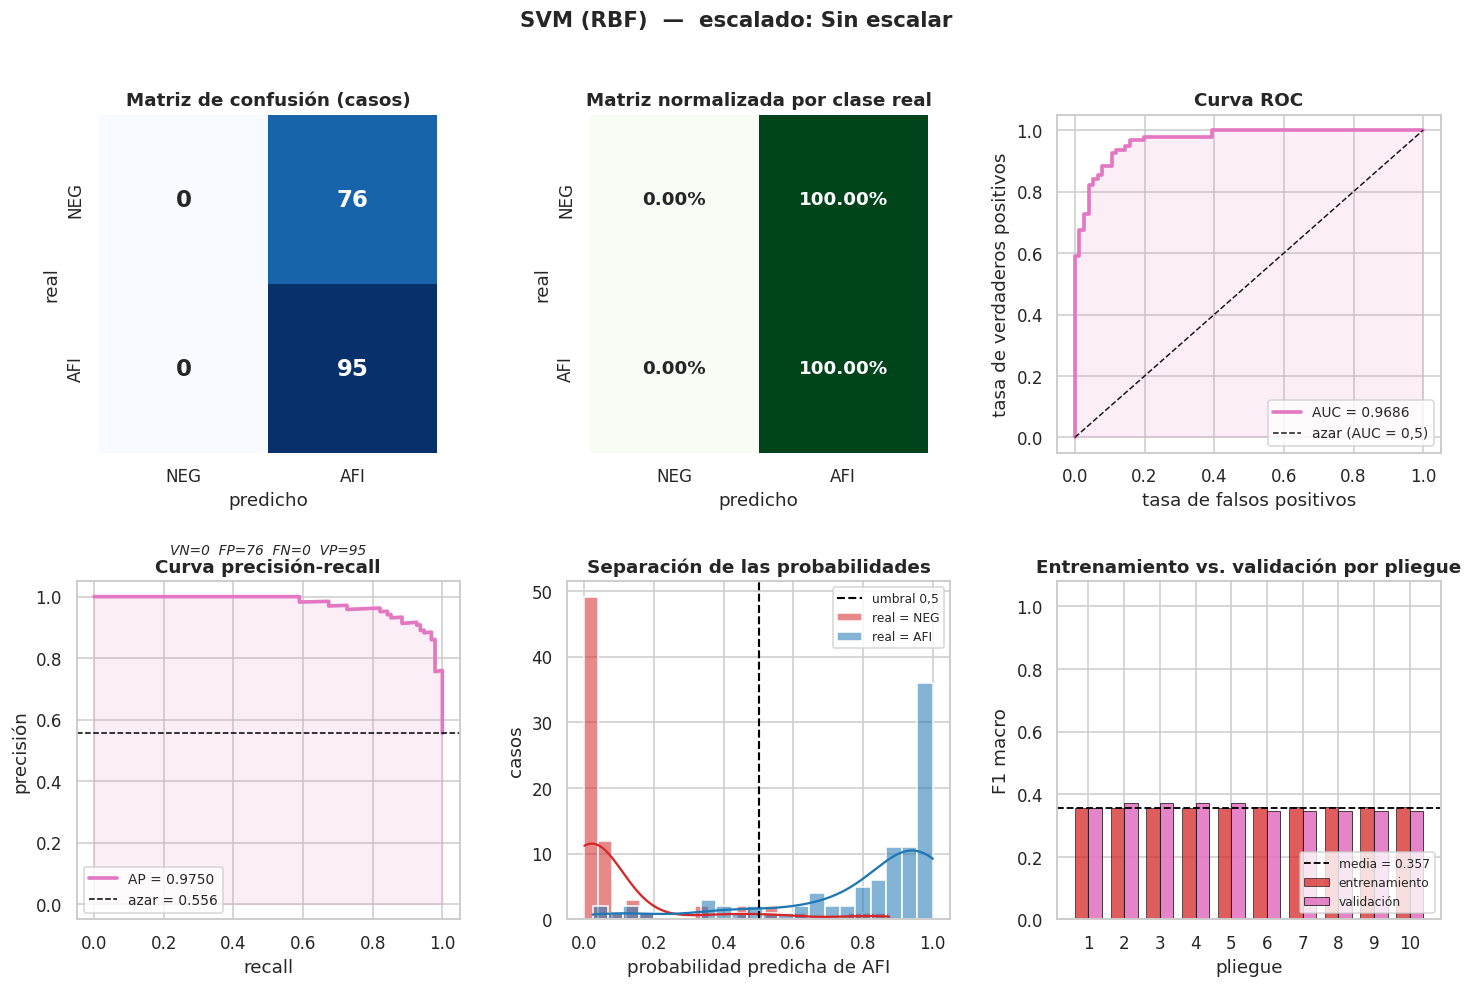


  ANÁLISIS ESPECÍFICO DE ESTE MODELO
  ------------------------------------------------------------------------------------


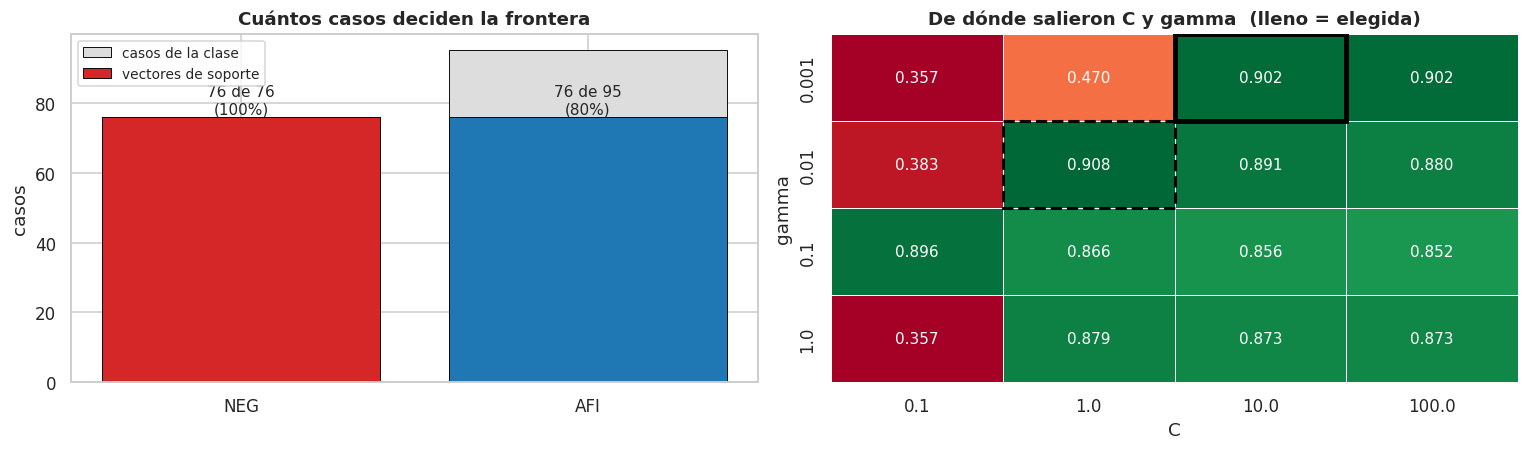

  C = 10.0,  gamma = 0.001
  Vectores de soporte: 152 de 171 casos (89%).

  Cómo leerlo: los vectores de soporte son los casos que quedan sobre el borde
  de la calle o adentro. Si son pocos, las clases se separan con claridad y la
  frontera depende de un puñado de casos dudosos. Si son la mayoría, las clases
  se superponen mucho o el margen es muy ancho (C bajo). Más del 50 % no es
  necesariamente malo, pero dice que la separación no es nítida.


In [30]:
def grafico_svm(pipeline_ajustado, color):
    modelo = pipeline_ajustado.named_steps["modelo"]
    nombres_clase = {0: clase_negativa, 1: CLASE_POSITIVA}
    por_clase = pd.Series(modelo.n_support_,
                          index=[nombres_clase[c] for c in modelo.classes_])
    casos_por_clase = pd.Series([int((y == c).sum()) for c in modelo.classes_],
                                index=por_clase.index)
    total_sv = int(por_clase.sum())

    fig, ejes = plt.subplots(1, 2, figsize=(14, 4.2))

    ejes[0].bar(por_clase.index, casos_por_clase, color="#dddddd", edgecolor="black",
                linewidth=0.6, label="casos de la clase")
    ejes[0].bar(por_clase.index, por_clase,
                color=[COLOR_CLASE.get(c, color) for c in por_clase.index],
                edgecolor="black", linewidth=0.6, label="vectores de soporte")
    for i, (sv, n) in enumerate(zip(por_clase, casos_por_clase)):
        ejes[0].text(i, sv + 1, f"{sv} de {n}\n({sv / n:.0%})", ha="center", fontsize=10)
    ejes[0].set_ylabel("casos")
    ejes[0].set_title("Cuántos casos deciden la frontera")
    ejes[0].legend(fontsize=9)

    dibujar_mapa_busqueda(ejes[1], busqueda_svm, "gamma", "C", barra=False)
    ejes[1].set_xlabel("C"); ejes[1].set_ylabel("gamma")
    ejes[1].set_title("De dónde salieron C y gamma  (lleno = elegida)")

    plt.tight_layout()
    plt.show()

    print(f"  C = {modelo.C},  gamma = {modelo.gamma}")
    print(f"  Vectores de soporte: {total_sv} de {len(y)} casos ({total_sv / len(y):.0%}).")
    print()
    print("  Cómo leerlo: los vectores de soporte son los casos que quedan sobre el borde")
    print("  de la calle o adentro. Si son pocos, las clases se separan con claridad y la")
    print("  frontera depende de un puñado de casos dudosos. Si son la mayoría, las clases")
    print("  se superponen mucho o el margen es muy ancho (C bajo). Más del 50 % no es")
    print("  necesariamente malo, pero dice que la separación no es nítida.")


nombre_svm = "SVM (RBF)"

registrar_modelo(
    nombre_svm,
    SVC(kernel="rbf", probability=True, random_state=SEMILLA, **busqueda_svm["elegidos"]),
    color="#e377c2",
    nota="Frontera de margen máximo con kernel; la deciden los casos del borde; necesita escalado.",
    grafico_extra=grafico_svm,
    busqueda=busqueda_svm,
)

tabla_svm = evaluar_modelo(nombre_svm)

---
<a id="sec-14"></a>
# 14. Comparativa exhaustiva y ranking

Todo lo evaluado hasta acá se fue acumulando en `RESULTADOS`. Esta sección lo analiza entero.

Un detalle de diseño que vale la pena señalar: **en ninguna celda del punto 14 hay una lista de
modelos escrita a mano**. Todo se arma a partir de `RESULTADOS`. Si agregás un modelo nuevo y
volvés a correr esta sección, aparece solo en todas las tablas, en todos los gráficos y en el
ranking.

**La columna `ajustado`.** Las tablas indican qué modelos pasaron por una búsqueda de
hiperparámetros. Sus métricas son algo optimistas frente a las de los demás, por lo explicado en el
punto 7.6; conviene tenerlo presente al leer cualquier diferencia chica entre modelos.

<a id="sec-14-1"></a>
## 14.1 Tabla maestra

Todas las combinaciones de modelo y escalado, con todas las métricas. Es la tabla de la que sale
todo lo demás.

In [31]:
maestra = pd.DataFrame(RESULTADOS)

print("=" * 88)
print("  TABLA MAESTRA")
print("=" * 88)
print(f"  Modelos evaluados     : {maestra['modelo'].nunique()}")
print(f"  Escalados comparados  : {maestra['escalado'].nunique()}")
print(f"  Combinaciones totales : {len(maestra)}")
columnas_metricas = [c for c in maestra.columns
                     if c not in ("modelo", "escalado", "color", "ajustado", "diagnostico")]
print(f"  Métricas por fila     : {len(columnas_metricas)}")
print()

columnas_vista = ["modelo", "escalado", "ajustado", "accuracy", "balanced_accuracy", "precision",
                  "recall", "f1", "f1_macro", "roc_auc", "average_precision",
                  "mcc", "kappa", "log_loss", "brier",
                  "cv_f1_macro_desvio", "brecha_ajuste", "diagnostico"]

vista = maestra[columnas_vista].rename(columns={
    "cv_f1_macro_desvio": "desvio_pliegues", "brecha_ajuste": "brecha",
})
display(vista.sort_values("roc_auc", ascending=False).reset_index(drop=True))

  TABLA MAESTRA
  Modelos evaluados     : 6
  Escalados comparados  : 3
  Combinaciones totales : 18
  Métricas por fila     : 31



,modelo,escalado,ajustado,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,roc_auc,average_precision,mcc,kappa,log_loss,brier,desvio_pliegues,brecha,diagnostico
0,SVM (RBF),Sin escalar,True,0.5556,0.5000,0.5556,1.0000,0.7143,0.3571,0.9686,0.9750,0.0000,0.0000,0.2585,0.0782,0.0114,0.0002,SUBAJUSTE
1,Regresión Logística,Sin escalar,False,0.9006,0.8961,0.8900,0.9368,0.9128,0.8986,0.9673,0.9743,0.7988,0.7974,0.4034,0.1172,0.0692,0.0005,AJUSTE CORRECTO
2,SVM (RBF),Min-Max,True,0.5556,0.5000,0.5556,1.0000,0.7143,0.3571,0.9663,0.9745,0.0000,0.0000,0.2530,0.0764,0.0114,0.0002,SUBAJUSTE
3,Regresión Logística,Min-Max,False,0.9064,0.9026,0.8990,0.9368,0.9175,0.9047,0.9655,0.9738,0.8104,0.8095,0.3219,0.0899,0.0703,0.0053,AJUSTE CORRECTO
4,KNN (k=45),Sin escalar,True,0.8947,0.8908,0.8889,0.9263,0.9072,0.8928,0.9650,0.9688,0.7866,0.7857,0.3154,0.0895,0.0727,0.0064,AJUSTE CORRECTO
5,KNN (k=45),Min-Max,True,0.8889,0.8829,0.8725,0.9368,0.9036,0.8863,0.9647,0.9690,0.7756,0.7729,0.3204,0.0911,0.0656,0.0096,AJUSTE CORRECTO
6,Regresión Logística,Z-score,False,0.9006,0.8987,0.9062,0.9158,0.9110,0.8992,0.9626,0.9712,0.7985,0.7984,0.2482,0.0756,0.0637,0.0150,AJUSTE CORRECTO
7,SVM (RBF),Z-score,True,0.9064,0.9026,0.8990,0.9368,0.9175,0.9047,0.9622,0.9701,0.8104,0.8095,0.2445,0.0712,0.0703,0.0027,AJUSTE CORRECTO
8,KNN (k=45),Z-score,True,0.8889,0.8829,0.8725,0.9368,0.9036,0.8863,0.9599,0.9640,0.7756,0.7729,0.3331,0.0954,0.0656,0.0103,AJUSTE CORRECTO
9,Random Forest,Sin escalar,False,0.9006,0.8974,0.8980,0.9263,0.9119,0.8989,0.9596,0.9656,0.7984,0.7979,0.2734,0.0811,0.0580,0.1038,SOBREAJUSTE


<a id="sec-14-2"></a>
## 14.2 La mejor variante de cada modelo

De las tres variantes de escalado de cada modelo nos quedamos con la mejor por ROC-AUC. Esa es la
que representa al modelo en el ranking final.

Usamos ROC-AUC como criterio de selección porque **no depende del umbral de corte**: mide la
capacidad del modelo de ordenar los casos, con independencia de dónde se ponga la línea entre una
clase y la otra. Eso lo vuelve la métrica más estable para comparar familias de modelos distintas.

In [32]:
mejores_por_modelo = (maestra.sort_values("roc_auc", ascending=False)
                             .groupby("modelo", as_index=False)
                             .first())
mejores_por_modelo = (mejores_por_modelo.sort_values("roc_auc", ascending=False)
                                        .reset_index(drop=True))

print("=" * 88)
print("  LA MEJOR VARIANTE DE CADA MODELO")
print("=" * 88)
display(mejores_por_modelo[[
    "modelo", "escalado", "ajustado", "accuracy", "balanced_accuracy", "f1_macro",
    "roc_auc", "mcc", "cv_f1_macro_media", "cv_f1_macro_desvio", "brecha_ajuste",
]].rename(columns={"cv_f1_macro_media": "f1_cv_media",
                   "cv_f1_macro_desvio": "f1_cv_desvio",
                   "brecha_ajuste": "brecha"}))

print("  Línea de base (responder siempre la clase mayoritaria):")
print(f"    accuracy = {linea_base:.4f},  ROC-AUC = 0.5000")
print()
for _, fila in mejores_por_modelo.iterrows():
    mejora = fila["accuracy"] - linea_base
    print(f"    {fila['modelo']:<24} accuracy {fila['accuracy']:.4f}  "
          f"({mejora:+.4f} sobre la línea de base)")

  LA MEJOR VARIANTE DE CADA MODELO


,modelo,escalado,ajustado,accuracy,balanced_accuracy,f1_macro,roc_auc,mcc,f1_cv_media,f1_cv_desvio,brecha
0,SVM (RBF),Sin escalar,True,0.5556,0.5000,0.3571,0.9686,0.0000,0.3569,0.0114,0.0002
1,Regresión Logística,Sin escalar,False,0.9006,0.8961,0.8986,0.9673,0.7988,0.8960,0.0692,0.0005
2,KNN (k=45),Sin escalar,True,0.8947,0.8908,0.8928,0.9650,0.7866,0.8903,0.0727,0.0064
3,Random Forest,Sin escalar,False,0.9006,0.8974,0.8989,0.9596,0.7984,0.8962,0.0580,0.1038
4,XGBoost,Min-Max,True,0.9123,0.9092,0.9108,0.9561,0.8222,0.9068,0.0788,0.0523
5,Árbol de Decisión,Z-score,True,0.8538,0.8447,0.8492,0.8855,0.7058,0.8458,0.0589,0.0393


  Línea de base (responder siempre la clase mayoritaria):
    accuracy = 0.5556,  ROC-AUC = 0.5000

    SVM (RBF)                accuracy 0.5556  (+0.0000 sobre la línea de base)
    Regresión Logística      accuracy 0.9006  (+0.3450 sobre la línea de base)
    KNN (k=45)               accuracy 0.8947  (+0.3392 sobre la línea de base)
    Random Forest            accuracy 0.9006  (+0.3450 sobre la línea de base)
    XGBoost                  accuracy 0.9123  (+0.3567 sobre la línea de base)
    Árbol de Decisión        accuracy 0.8538  (+0.2982 sobre la línea de base)


<a id="sec-14-3"></a>
## 14.3 Curvas ROC superpuestas

La **curva ROC** se construye barriendo todos los umbrales de corte posibles. Para cada uno se
calcula la tasa de verdaderos positivos —qué proporción de los positivos reales detecta— contra la
tasa de falsos positivos —qué proporción de los negativos clasifica mal—. El **área bajo la curva**
(AUC) resume todo ese barrido en un número.

Su interpretación más intuitiva: el AUC es la probabilidad de que, tomando al azar un caso positivo
y uno negativo, el modelo le asigne mayor puntaje al positivo. 0,5 es azar puro; 1 es perfecto.

Superponerlas permite ver **dónde** un modelo es mejor que otro. Dos modelos pueden tener un AUC
casi idéntico y curvas de forma muy distinta: uno mejor en la zona de umbrales exigentes y otro en
la de umbrales permisivos.

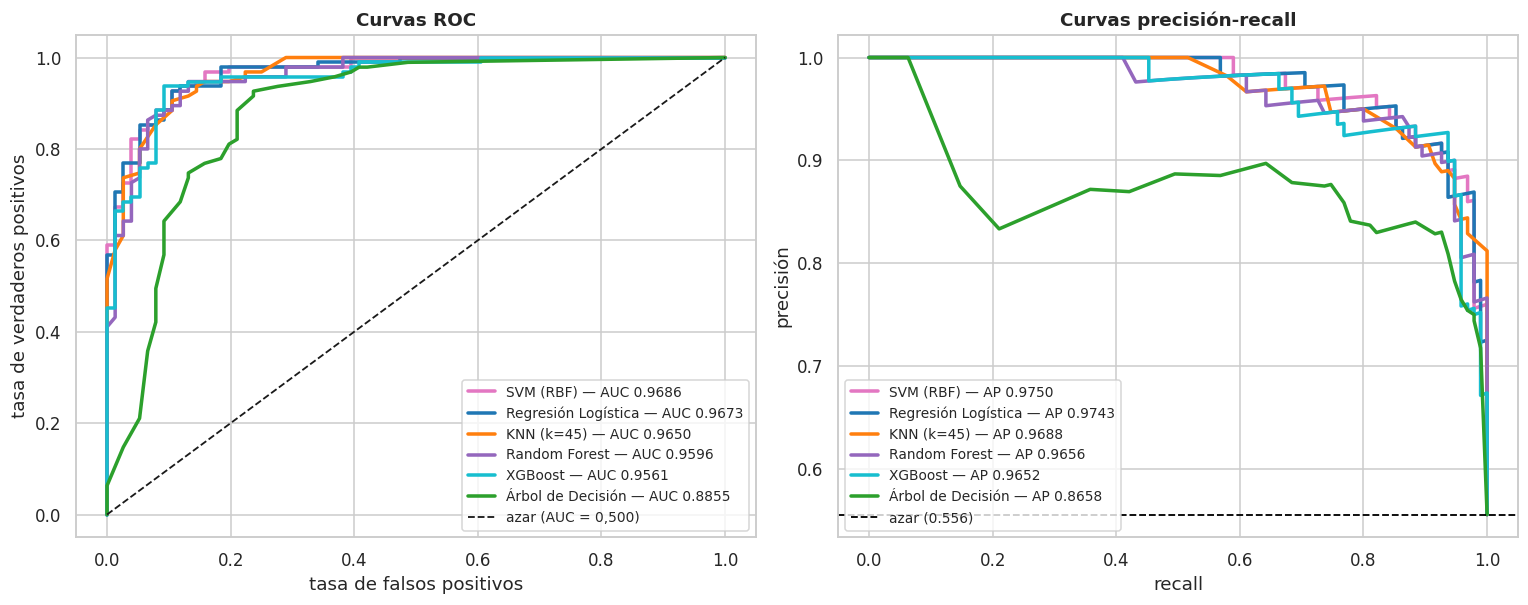

In [33]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.6))

for _, fila in mejores_por_modelo.iterrows():
    clave = (fila["modelo"], fila["escalado"])
    proba = PREDICCIONES[clave]["y_proba"]

    fpr, tpr, _ = roc_curve(y, proba)
    ejes[0].plot(fpr, tpr, linewidth=2.3, color=fila["color"],
                 label=f"{fila['modelo']} — AUC {fila['roc_auc']:.4f}")

    prec, rec, _ = precision_recall_curve(y, proba)
    ejes[1].plot(rec, prec, linewidth=2.3, color=fila["color"],
                 label=f"{fila['modelo']} — AP {fila['average_precision']:.4f}")

ejes[0].plot([0, 1], [0, 1], "k--", linewidth=1.2, label="azar (AUC = 0,500)")
ejes[0].set_xlabel("tasa de falsos positivos")
ejes[0].set_ylabel("tasa de verdaderos positivos")
ejes[0].set_title("Curvas ROC")
ejes[0].legend(loc="lower right", fontsize=9)

ejes[1].axhline(y.mean(), color="black", linestyle="--", linewidth=1.2,
                label=f"azar ({y.mean():.3f})")
ejes[1].set_xlabel("recall")
ejes[1].set_ylabel("precisión")
ejes[1].set_title("Curvas precisión-recall")
ejes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

<a id="sec-14-4"></a>
## 14.4 El efecto de la normalización

La pregunta que respondemos acá: **¿cuál de los dos escalados conviene, y a qué modelos les
importa?**

Lo esperable, según lo explicado en 2.3:

- La **regresión logística**, **KNN** y la **SVM** deberían mostrar alguna diferencia entre
  escalados. La SVM puede ser la más sensible de todas si la búsqueda del punto 13 eligió un `gamma`
  numérico: ese valor solo tiene sentido en la escala en que se lo buscó.
- El **árbol**, el **bosque** y **XGBoost** deberían ser exactamente indiferentes. Si alguno
  mostrara diferencia, habría un error en la maquinaria.

  ROC-AUC POR MODELO Y ESCALADO


escalado,Sin escalar,Min-Max,Z-score
modelo,,,
KNN (k=45),0.9650,0.9647,0.9599
Random Forest,0.9596,0.9596,0.9596
Regresión Logística,0.9673,0.9655,0.9626
SVM (RBF),0.9686,0.9663,0.9622
XGBoost,0.9561,0.9561,0.9561
Árbol de Decisión,0.8855,0.8855,0.8855


  F1 MACRO POR MODELO Y ESCALADO


escalado,Sin escalar,Min-Max,Z-score
modelo,,,
KNN (k=45),0.8928,0.8863,0.8863
Random Forest,0.8989,0.8989,0.8989
Regresión Logística,0.8986,0.9047,0.8992
SVM (RBF),0.3571,0.3571,0.9047
XGBoost,0.9108,0.9108,0.9108
Árbol de Decisión,0.8492,0.8492,0.8492


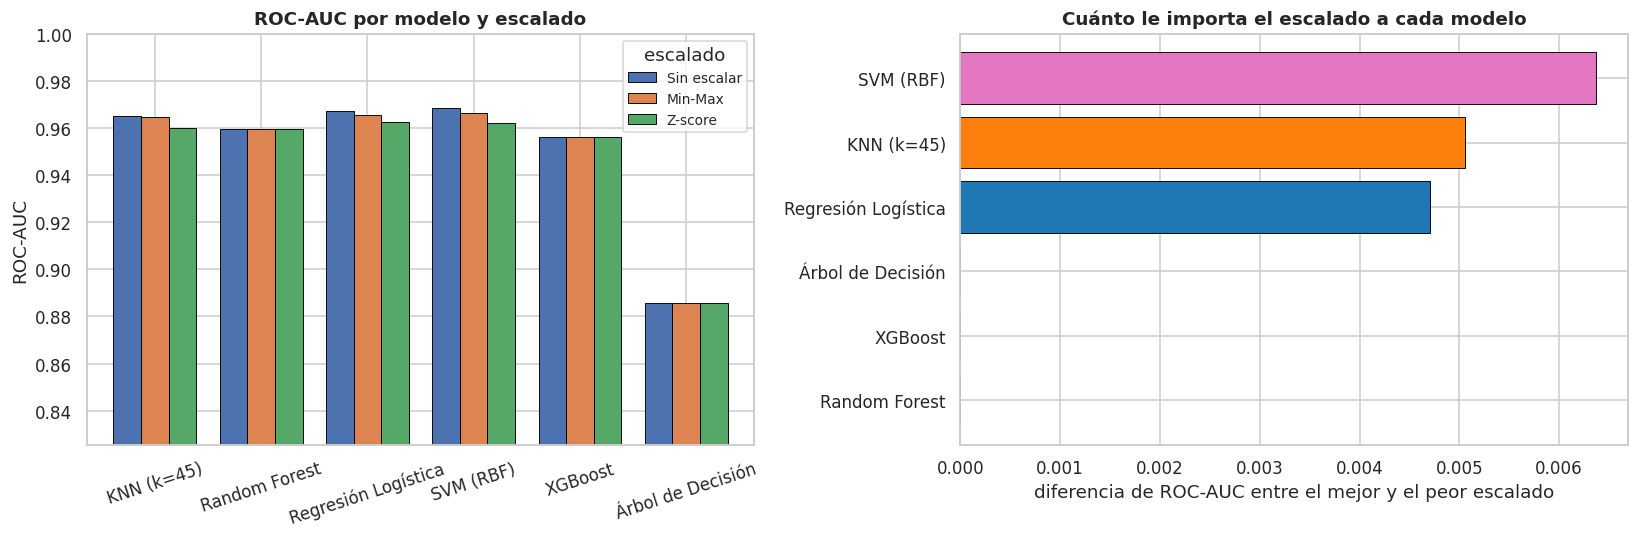

  LECTURA
    SVM (RBF)                diferencia de 0.0064; el mejor es Sin escalar.
    KNN (k=45)               diferencia de 0.0051; el mejor es Sin escalar.
    Regresión Logística      diferencia de 0.0047; el mejor es Sin escalar.
    Random Forest            INDIFERENTE al escalado (diferencia exacta de 0).
    XGBoost                  INDIFERENTE al escalado (diferencia exacta de 0).
    Árbol de Decisión        INDIFERENTE al escalado (diferencia exacta de 0).

  Escalado preferido, contando solo los modelos a los que les importa:
    Sin escalar    3 de 3 modelos sensibles

  (Las siete variables ya están en el mismo rango: todas son proporciones
   entre 0 y 1. Por eso el escalado tiene poco margen en los modelos que solo
   necesitan comparar distancias o pesos, y 'Sin escalar' puede empatar o
   ganar. Donde un hiperparámetro se buscó en una escala concreta —el gamma
   de la SVM, buscado con Z-score—, usarlo en otra escala cambia lo que
   significa, y la tabla de arriba

In [34]:
pivote_auc = maestra.pivot_table(index="modelo", columns="escalado", values="roc_auc")
pivote_f1 = maestra.pivot_table(index="modelo", columns="escalado", values="f1_macro")
orden_escalados = [e for e in ESCALADORES if e in pivote_auc.columns]
pivote_auc = pivote_auc[orden_escalados]
pivote_f1 = pivote_f1[orden_escalados]

print("=" * 88)
print("  ROC-AUC POR MODELO Y ESCALADO")
print("=" * 88)
display(pivote_auc)

print("=" * 88)
print("  F1 MACRO POR MODELO Y ESCALADO")
print("=" * 88)
display(pivote_f1)

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

pivote_auc.plot(kind="bar", ax=ejes[0], edgecolor="black", linewidth=0.6, width=0.78)
ejes[0].set_ylabel("ROC-AUC")
ejes[0].set_title("ROC-AUC por modelo y escalado")
ejes[0].set_ylim(max(0, pivote_auc.to_numpy().min() - 0.06), 1.0)
ejes[0].legend(title="escalado", fontsize=9)
ejes[0].tick_params(axis="x", rotation=18)
ejes[0].set_xlabel("")

sensibilidad = (pivote_auc.max(axis=1) - pivote_auc.min(axis=1)).sort_values(ascending=True)
colores_sens = [maestra.loc[maestra["modelo"] == m, "color"].iloc[0] for m in sensibilidad.index]
ejes[1].barh(sensibilidad.index, sensibilidad.values, color=colores_sens,
             edgecolor="black", linewidth=0.6)
ejes[1].set_xlabel("diferencia de ROC-AUC entre el mejor y el peor escalado")
ejes[1].set_title("Cuánto le importa el escalado a cada modelo")

plt.tight_layout()
plt.show()

print("=" * 88)
print("  LECTURA")
print("=" * 88)
for modelo in sensibilidad.sort_values(ascending=False).index:
    rango = sensibilidad[modelo]
    mejor_esc = pivote_auc.loc[modelo].idxmax()
    if rango < 1e-9:
        print(f"    {modelo:<24} INDIFERENTE al escalado (diferencia exacta de 0).")
    else:
        print(f"    {modelo:<24} diferencia de {rango:.4f}; el mejor es {mejor_esc}.")

print()
modelos_sensibles = sensibilidad[sensibilidad > 1e-9].index.tolist()
if modelos_sensibles:
    solo_sensibles = maestra[maestra["modelo"].isin(modelos_sensibles)]
    ganadores = solo_sensibles.loc[solo_sensibles.groupby("modelo")["roc_auc"].idxmax(),
                                   "escalado"]
    print("  Escalado preferido, contando solo los modelos a los que les importa:")
    for escalado, cuenta in ganadores.value_counts().items():
        print(f"    {escalado:<14} {cuenta} de {len(modelos_sensibles)} modelos sensibles")
    print()
    print("  (Las siete variables ya están en el mismo rango: todas son proporciones")
    print("   entre 0 y 1. Por eso el escalado tiene poco margen en los modelos que solo")
    print("   necesitan comparar distancias o pesos, y 'Sin escalar' puede empatar o")
    print("   ganar. Donde un hiperparámetro se buscó en una escala concreta —el gamma")
    print("   de la SVM, buscado con Z-score—, usarlo en otra escala cambia lo que")
    print("   significa, y la tabla de arriba muestra cuánto pesa eso.)")
else:
    print("  Ningún modelo resultó sensible al escalado.")

print()
print("  Conviene no sobreinterpretar: en los modelos donde la diferencia es")
print("  menor que el desvío entre pliegues, la elección del escalado no está")
print("  demostrada por los datos. Lo que sí está demostrado es cuándo NO importa.")

<a id="sec-14-5"></a>
## 14.5 Estabilidad entre pliegues

Una media sola no alcanza para elegir un modelo. Dos modelos pueden tener el mismo F1 promedio y
comportarse de manera muy distinta: uno consistente en todos los pliegues, otro oscilando entre
resultados muy buenos y muy malos.

El **desvío entre pliegues** mide esa consistencia. Es la forma 3 de detección del punto 5.4
de la Parte 2A, y es
la información que permite decir si la diferencia entre dos modelos es real o cabe dentro del ruido
de la medición. Si dos modelos difieren en 0,01 de F1 y el desvío de cada uno es 0,05, esa
diferencia no significa nada.

  ESTABILIDAD ENTRE PLIEGUES


,modelo,escalado,f1_media,f1_desvio,f1_min,f1_max,auc_media,auc_desvio,amplitud
0,XGBoost,Min-Max,0.9068,0.0788,0.7424,1.0000,0.9555,0.0389,0.2576
1,Random Forest,Sin escalar,0.8962,0.0580,0.7984,1.0000,0.9624,0.0327,0.2016
2,Regresión Logística,Sin escalar,0.8960,0.0692,0.7984,1.0000,0.9650,0.0279,0.2016
3,KNN (k=45),Sin escalar,0.8903,0.0727,0.7984,1.0000,0.9641,0.0315,0.2016
4,Árbol de Decisión,Z-score,0.8458,0.0589,0.7424,0.9404,0.8813,0.0706,0.1979
5,SVM (RBF),Sin escalar,0.3569,0.0114,0.3462,0.3704,0.9635,0.0327,0.0242


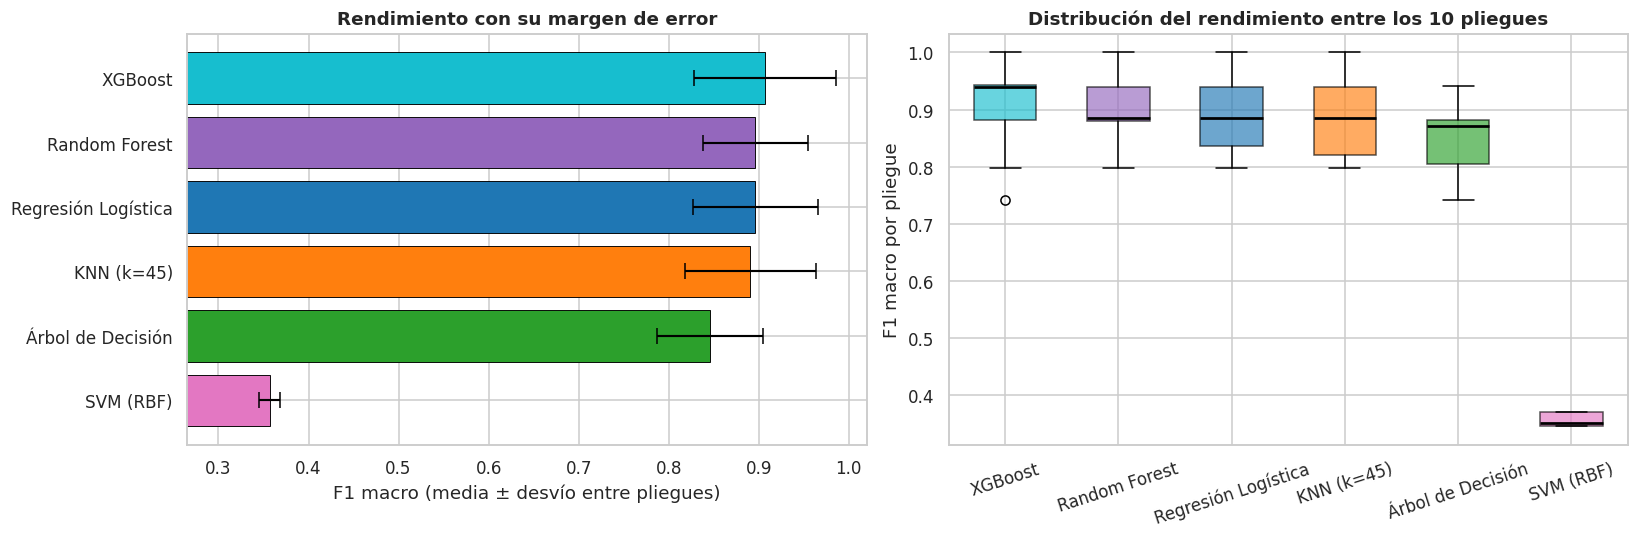

  Más estable  : SVM (RBF) (desvío 0.0114)
  Menos estable: XGBoost (desvío 0.0788)

  Desvío típico entre pliegues: 0.0641
  REGLA PRÁCTICA: dos modelos que difieran en menos de 0.0641 de F1
  macro no se pueden distinguir con estos datos. La diferencia entra dentro
  del ruido de la medición.


In [35]:
estabilidad = mejores_por_modelo[[
    "modelo", "escalado", "color",
    "cv_f1_macro_media", "cv_f1_macro_desvio", "cv_f1_macro_min", "cv_f1_macro_max",
    "cv_roc_auc_media", "cv_roc_auc_desvio",
]].copy()
estabilidad["amplitud"] = estabilidad["cv_f1_macro_max"] - estabilidad["cv_f1_macro_min"]
estabilidad = estabilidad.sort_values("cv_f1_macro_media", ascending=False)

print("=" * 88)
print("  ESTABILIDAD ENTRE PLIEGUES")
print("=" * 88)
display(estabilidad.drop(columns="color").rename(columns={
    "cv_f1_macro_media": "f1_media", "cv_f1_macro_desvio": "f1_desvio",
    "cv_f1_macro_min": "f1_min", "cv_f1_macro_max": "f1_max",
    "cv_roc_auc_media": "auc_media", "cv_roc_auc_desvio": "auc_desvio",
}).reset_index(drop=True))

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

posiciones = np.arange(len(estabilidad))
ejes[0].barh(posiciones, estabilidad["cv_f1_macro_media"],
             xerr=estabilidad["cv_f1_macro_desvio"],
             color=estabilidad["color"], edgecolor="black", linewidth=0.6,
             capsize=5, error_kw={"linewidth": 1.4, "ecolor": "black"})
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels(estabilidad["modelo"])
ejes[0].set_xlabel("F1 macro (media ± desvío entre pliegues)")
ejes[0].set_title("Rendimiento con su margen de error")
ejes[0].set_xlim(max(0, (estabilidad["cv_f1_macro_media"] -
                         estabilidad["cv_f1_macro_desvio"]).min() - 0.08), 1.02)
ejes[0].invert_yaxis()

datos_caja, etiquetas, colores_caja = [], [], []
for _, fila in estabilidad.iterrows():
    clave = (fila["modelo"], fila["escalado"])
    datos_caja.append(PREDICCIONES[clave]["por_pliegue"]["test_f1_macro"])
    etiquetas.append(fila["modelo"])
    colores_caja.append(fila["color"])

caja = ejes[1].boxplot(datos_caja, tick_labels=etiquetas, patch_artist=True, widths=0.55)
for parche, color in zip(caja["boxes"], colores_caja):
    parche.set_facecolor(color)
    parche.set_alpha(0.65)
for mediana in caja["medians"]:
    mediana.set_color("black")
    mediana.set_linewidth(1.8)
ejes[1].set_ylabel("F1 macro por pliegue")
ejes[1].set_title(f"Distribución del rendimiento entre los {N_PLIEGUES} pliegues")
ejes[1].tick_params(axis="x", rotation=18)

plt.tight_layout()
plt.show()

mas_estable = estabilidad.loc[estabilidad["cv_f1_macro_desvio"].idxmin()]
menos_estable = estabilidad.loc[estabilidad["cv_f1_macro_desvio"].idxmax()]
print(f"  Más estable  : {mas_estable['modelo']} "
      f"(desvío {mas_estable['cv_f1_macro_desvio']:.4f})")
print(f"  Menos estable: {menos_estable['modelo']} "
      f"(desvío {menos_estable['cv_f1_macro_desvio']:.4f})")
print()
desvio_tipico = estabilidad["cv_f1_macro_desvio"].median()
print(f"  Desvío típico entre pliegues: {desvio_tipico:.4f}")
print(f"  REGLA PRÁCTICA: dos modelos que difieran en menos de {desvio_tipico:.4f} de F1")
print("  macro no se pueden distinguir con estos datos. La diferencia entra dentro")
print("  del ruido de la medición.")

<a id="sec-14-6"></a>
## 14.6 Diagnóstico de ajuste comparado

La **brecha** entre el rendimiento en entrenamiento y el de validación, para todos los modelos a
la vez. Es el resumen de todo lo que se discutió en el punto 5 de la Parte 2A, aplicado a los
modelos reales.

Un modelo con brecha grande puede tener buen rendimiento en validación y ser igualmente una mala
elección: significa que está memorizando y que con datos nuevos, distintos de estos, va a caer más
que uno con brecha chica.

  DIAGNÓSTICO DE AJUSTE


,modelo,escalado,f1_entrenamiento,f1_validacion,brecha,desvio,diagnostico
0,SVM (RBF),Sin escalar,0.3571,0.3569,0.0002,0.0114,SUBAJUSTE
1,Regresión Logística,Sin escalar,0.8965,0.8960,0.0005,0.0692,AJUSTE CORRECTO
2,KNN (k=45),Sin escalar,0.8966,0.8903,0.0064,0.0727,AJUSTE CORRECTO
3,Árbol de Decisión,Z-score,0.8851,0.8458,0.0393,0.0589,AJUSTE CORRECTO
4,XGBoost,Min-Max,0.9592,0.9068,0.0523,0.0788,Sobreajuste leve
5,Random Forest,Sin escalar,1.0000,0.8962,0.1038,0.0580,SOBREAJUSTE


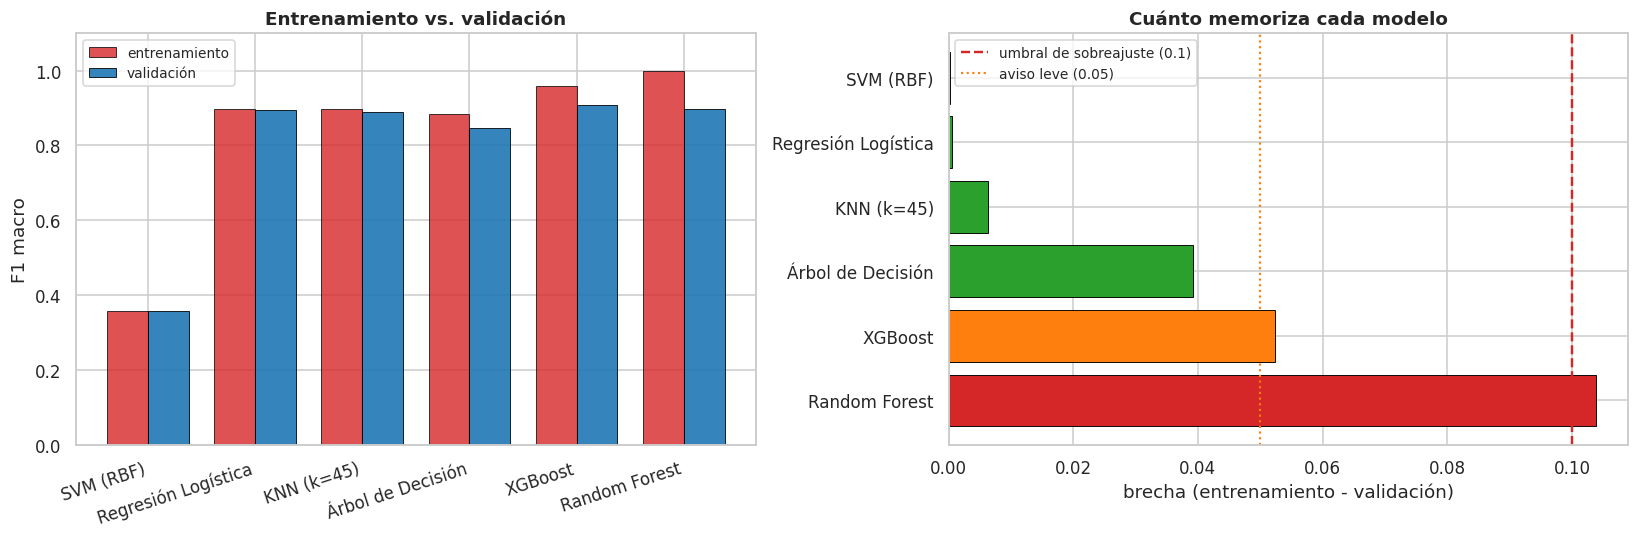

  VEREDICTO POR MODELO
  SVM (RBF)  (Sin escalar)
      SUBAJUSTE: el rendimiento en validación (0.3569) está por debajo de 0.70. El modelo puede ser demasiado simple para el problema.

  Regresión Logística  (Sin escalar)
      AJUSTE CORRECTO: brecha de 0.0005 y desvío entre pliegues de 0.0692, los dos dentro de lo aceptable. El modelo generaliza bien.

  KNN (k=45)  (Sin escalar)
      AJUSTE CORRECTO: brecha de 0.0064 y desvío entre pliegues de 0.0727, los dos dentro de lo aceptable. El modelo generaliza bien.

  Árbol de Decisión  (Z-score)
      AJUSTE CORRECTO: brecha de 0.0393 y desvío entre pliegues de 0.0589, los dos dentro de lo aceptable. El modelo generaliza bien.

  XGBoost  (Min-Max)
      Sobreajuste leve: brecha de 0.0523. Todavía tolerable, pero conviene no aumentar la complejidad del modelo.

  Random Forest  (Sin escalar)
      SOBREAJUSTE: la brecha entre entrenamiento (1.0000) y validación (0.8962) es de 0.1038, por encima del umbral de 0.10. El modelo memoriza má

In [36]:
ajuste = mejores_por_modelo[[
    "modelo", "escalado", "color",
    "cv_f1_macro_entrena", "cv_f1_macro_media", "brecha_ajuste", "cv_f1_macro_desvio",
    "diagnostico",
]].copy().sort_values("brecha_ajuste", ascending=True)

print("=" * 88)
print("  DIAGNÓSTICO DE AJUSTE")
print("=" * 88)
display(ajuste.drop(columns="color").rename(columns={
    "cv_f1_macro_entrena": "f1_entrenamiento",
    "cv_f1_macro_media": "f1_validacion",
    "brecha_ajuste": "brecha",
    "cv_f1_macro_desvio": "desvio",
}).reset_index(drop=True))

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

posiciones = np.arange(len(ajuste))
ancho = 0.38
ejes[0].bar(posiciones - ancho/2, ajuste["cv_f1_macro_entrena"], ancho,
            label="entrenamiento", color="#d62728", alpha=0.8,
            edgecolor="black", linewidth=0.6)
ejes[0].bar(posiciones + ancho/2, ajuste["cv_f1_macro_media"], ancho,
            label="validación", color="#1f77b4", alpha=0.9,
            edgecolor="black", linewidth=0.6)
ejes[0].set_xticks(posiciones)
ejes[0].set_xticklabels(ajuste["modelo"], rotation=18, ha="right")
ejes[0].set_ylabel("F1 macro")
ejes[0].set_title("Entrenamiento vs. validación")
ejes[0].set_ylim(0, 1.1)
ejes[0].legend(fontsize=9)

colores_brecha = ["#2ca02c" if b <= BRECHA_SOBREAJUSTE / 2
                  else "#ff7f0e" if b <= BRECHA_SOBREAJUSTE
                  else "#d62728" for b in ajuste["brecha_ajuste"]]
ejes[1].barh(ajuste["modelo"], ajuste["brecha_ajuste"], color=colores_brecha,
             edgecolor="black", linewidth=0.6)
ejes[1].axvline(BRECHA_SOBREAJUSTE, color="#d62728", linestyle="--", linewidth=1.6,
                label=f"umbral de sobreajuste ({BRECHA_SOBREAJUSTE})")
ejes[1].axvline(BRECHA_SOBREAJUSTE / 2, color="#ff7f0e", linestyle=":", linewidth=1.4,
                label=f"aviso leve ({BRECHA_SOBREAJUSTE/2})")
ejes[1].set_xlabel("brecha (entrenamiento - validación)")
ejes[1].set_title("Cuánto memoriza cada modelo")
ejes[1].legend(fontsize=9)
ejes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("=" * 88)
print("  VEREDICTO POR MODELO")
print("=" * 88)
for _, fila in ajuste.iterrows():
    clave = (fila["modelo"], fila["escalado"])
    print(f"  {fila['modelo']}  ({fila['escalado']})")
    for aviso in PREDICCIONES[clave]["avisos"]:
        print(f"      {aviso}")
    print()

<a id="sec-14-7"></a>
## 14.7 Ranking final

Para ordenar los modelos hace falta un criterio, y el criterio hay que declararlo **antes** de
mirar los resultados —si no, es muy fácil elegir el que favorece al modelo que uno ya prefería—.

**El criterio: un puntaje compuesto de cuatro métricas, con pesos.**

| Componente | Peso | Por qué |
|---|---|---|
| **ROC-AUC** | 35% | Mide la capacidad de ordenar los casos sin depender del umbral. Es la métrica más estable para comparar familias distintas de modelos |
| **F1 macro** | 30% | Captura el desempeño efectivo con el umbral de 0,5, tratando a las dos clases por igual |
| **MCC** | 20% | Usa las cuatro celdas de la matriz de confusión y es la más honesta cuando las clases están desbalanceadas |
| **Estabilidad** | 15% | `1 - desvío entre pliegues`. Penaliza los modelos cuyo rendimiento depende de qué datos les toquen |

Los tres primeros componentes miden **cuán bien predice**; el cuarto, **cuánto se puede confiar en
esa medición**. Un modelo apenas mejor pero mucho más inestable no es una mejor elección.

Los pesos son una decisión de diseño, no una verdad. Están escritos en la celda siguiente y se
pueden cambiar: el ranking se recalcula solo.

In [37]:
PESOS_RANKING = {
    "roc_auc": 0.35,
    "f1_macro": 0.30,
    "mcc": 0.20,
    "estabilidad": 0.15,
}

ranking = mejores_por_modelo.copy()
ranking["estabilidad"] = 1 - ranking["cv_f1_macro_desvio"]
# El MCC va de -1 a +1: lo llevamos a 0-1 para que sea comparable con las demás
ranking["mcc_normalizado"] = (ranking["mcc"] + 1) / 2

ranking["puntaje"] = (
    PESOS_RANKING["roc_auc"] * ranking["roc_auc"] +
    PESOS_RANKING["f1_macro"] * ranking["f1_macro"] +
    PESOS_RANKING["mcc"] * ranking["mcc_normalizado"] +
    PESOS_RANKING["estabilidad"] * ranking["estabilidad"]
)

ranking = ranking.sort_values("puntaje", ascending=False).reset_index(drop=True)
ranking.insert(0, "puesto", range(1, len(ranking) + 1))

print("=" * 96)
print("  RANKING FINAL DE MODELOS")
print("=" * 96)
display(ranking[[
    "puesto", "modelo", "escalado", "ajustado", "puntaje",
    "roc_auc", "f1_macro", "mcc", "cv_f1_macro_desvio",
    "accuracy", "balanced_accuracy", "brecha_ajuste",
]].rename(columns={"cv_f1_macro_desvio": "desvio", "brecha_ajuste": "brecha"}))

print()
for _, fila in ranking.iterrows():
    medalla = {1: "1ro", 2: "2do", 3: "3ro"}.get(fila["puesto"], f"{fila['puesto']}to")
    print(f"  {medalla:>4}  {fila['modelo']:<24} puntaje {fila['puntaje']:.4f}   "
          f"(AUC {fila['roc_auc']:.4f} | F1 {fila['f1_macro']:.4f} | "
          f"MCC {fila['mcc']:.4f} | desvío {fila['cv_f1_macro_desvio']:.4f})")

print()
lider = ranking.iloc[0]
print("  Diferencia del primero contra los demás:")
for _, fila in ranking.iloc[1:].iterrows():
    dif_auc = lider["roc_auc"] - fila["roc_auc"]
    dif_f1 = lider["f1_macro"] - fila["f1_macro"]
    ruido = max(lider["cv_f1_macro_desvio"], fila["cv_f1_macro_desvio"])
    veredicto = "diferencia DEMOSTRADA" if dif_f1 > ruido else "diferencia dentro del ruido"
    print(f"    vs. {fila['modelo']:<24} AUC {dif_auc:+.4f}  F1 {dif_f1:+.4f}   -> {veredicto}")

  RANKING FINAL DE MODELOS


,puesto,modelo,escalado,ajustado,puntaje,roc_auc,f1_macro,mcc,desvio,accuracy,balanced_accuracy,brecha
0,1,XGBoost,Min-Max,True,0.9283,0.9561,0.9108,0.8222,0.0788,0.9123,0.9092,0.0523
1,2,Regresión Logística,Sin escalar,False,0.9276,0.9673,0.8986,0.7988,0.0692,0.9006,0.8961,0.0005
2,3,Random Forest,Sin escalar,False,0.9267,0.9596,0.8989,0.7984,0.0580,0.9006,0.8974,0.1038
3,4,KNN (k=45),Sin escalar,True,0.9233,0.9650,0.8928,0.7866,0.0727,0.8947,0.8908,0.0064
4,5,Árbol de Decisión,Z-score,True,0.8764,0.8855,0.8492,0.7058,0.0589,0.8538,0.8447,0.0393
5,6,SVM (RBF),Sin escalar,True,0.6944,0.9686,0.3571,0.0000,0.0114,0.5556,0.5000,0.0002



   1ro  XGBoost                  puntaje 0.9283   (AUC 0.9561 | F1 0.9108 | MCC 0.8222 | desvío 0.0788)
   2do  Regresión Logística      puntaje 0.9276   (AUC 0.9673 | F1 0.8986 | MCC 0.7988 | desvío 0.0692)
   3ro  Random Forest            puntaje 0.9267   (AUC 0.9596 | F1 0.8989 | MCC 0.7984 | desvío 0.0580)
   4to  KNN (k=45)               puntaje 0.9233   (AUC 0.9650 | F1 0.8928 | MCC 0.7866 | desvío 0.0727)
   5to  Árbol de Decisión        puntaje 0.8764   (AUC 0.8855 | F1 0.8492 | MCC 0.7058 | desvío 0.0589)
   6to  SVM (RBF)                puntaje 0.6944   (AUC 0.9686 | F1 0.3571 | MCC 0.0000 | desvío 0.0114)

  Diferencia del primero contra los demás:
    vs. Regresión Logística      AUC -0.0112  F1 +0.0122   -> diferencia dentro del ruido
    vs. Random Forest            AUC -0.0035  F1 +0.0119   -> diferencia dentro del ruido
    vs. KNN (k=45)               AUC -0.0089  F1 +0.0180   -> diferencia dentro del ruido
    vs. Árbol de Decisión        AUC +0.0706  F1 +0.0616   ->

Y el ranking visto de una sola mirada: el puntaje compuesto, el desglose de sus componentes, y un
mapa de calor con todas las métricas de todos los modelos.

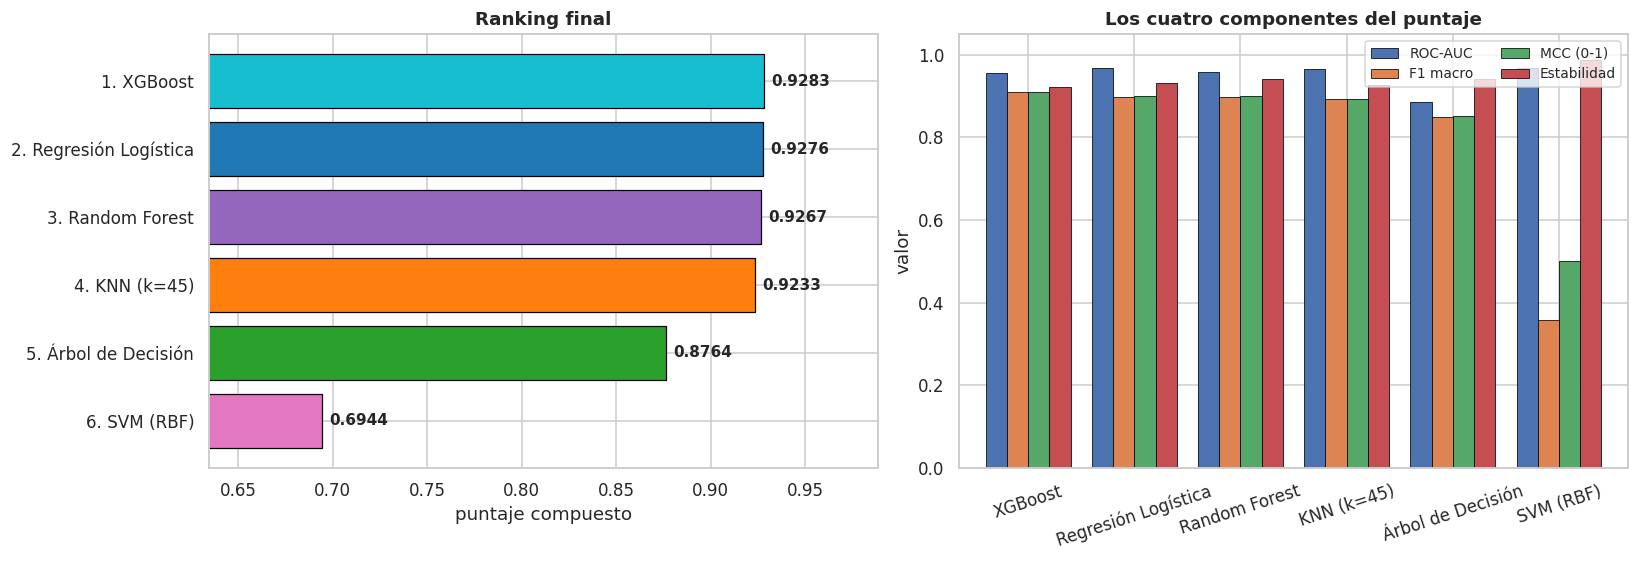

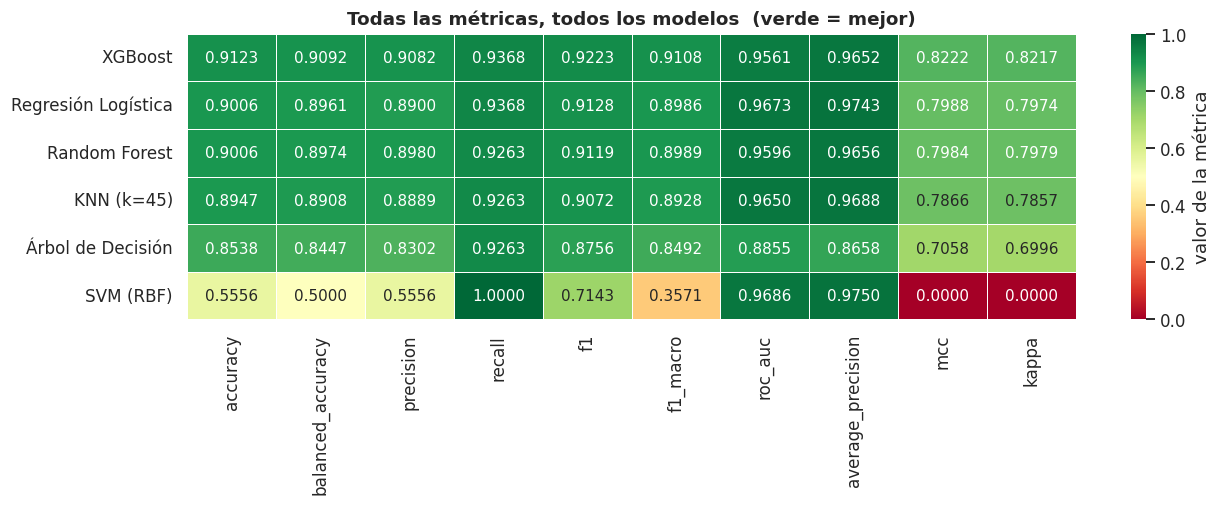

In [38]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5.2))

posiciones = np.arange(len(ranking))
ejes[0].barh(posiciones, ranking["puntaje"], color=ranking["color"],
             edgecolor="black", linewidth=0.8)
for i, puntaje in enumerate(ranking["puntaje"]):
    ejes[0].text(puntaje + 0.004, i, f"{puntaje:.4f}", va="center", fontsize=10,
                 fontweight="bold")
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels([f"{p}. {m}" for p, m in zip(ranking["puesto"], ranking["modelo"])])
ejes[0].set_xlabel("puntaje compuesto")
ejes[0].set_title("Ranking final")
ejes[0].set_xlim(max(0, ranking["puntaje"].min() - 0.06),
                 min(1.02, ranking["puntaje"].max() + 0.06))
ejes[0].invert_yaxis()

componentes = ranking.set_index("modelo")[["roc_auc", "f1_macro", "mcc_normalizado",
                                           "estabilidad"]]
componentes.columns = ["ROC-AUC", "F1 macro", "MCC (0-1)", "Estabilidad"]
componentes.plot(kind="bar", ax=ejes[1], edgecolor="black", linewidth=0.5, width=0.8)
ejes[1].set_ylabel("valor")
ejes[1].set_title("Los cuatro componentes del puntaje")
ejes[1].set_ylim(0, 1.05)
ejes[1].legend(fontsize=9, ncol=2)
ejes[1].tick_params(axis="x", rotation=18)
ejes[1].set_xlabel("")

plt.tight_layout()
plt.show()

metricas_mapa = ["accuracy", "balanced_accuracy", "precision", "recall", "f1",
                 "f1_macro", "roc_auc", "average_precision", "mcc", "kappa"]
mapa = ranking.set_index("modelo")[metricas_mapa]

fig, eje = plt.subplots(figsize=(12, 1.4 + 0.55 * len(mapa)))
sns.heatmap(mapa, annot=True, fmt=".4f", cmap="RdYlGn", linewidths=0.6,
            cbar_kws={"label": "valor de la métrica"}, ax=eje)
eje.set_title("Todas las métricas, todos los modelos  (verde = mejor)")
eje.set_ylabel("")
plt.tight_layout()
plt.show()

<a id="sec-14-8"></a>
## 14.8 Veredicto y limitaciones

La celda siguiente redacta la conclusión leyendo el ranking, de manera que siga siendo válida si
agregás modelos y volvés a correr todo.

In [39]:
lider = ranking.iloc[0]
segundo = ranking.iloc[1] if len(ranking) > 1 else None
mas_simple = (ranking.loc[ranking["modelo"].str.contains("Logística")].iloc[0]
              if ranking["modelo"].str.contains("Logística").any() else None)

print("=" * 88)
print("  VEREDICTO")
print("=" * 88)
print()
print(f"  1. GANADOR: {lider['modelo']}  (escalado: {lider['escalado']})")
print(f"     ROC-AUC {lider['roc_auc']:.4f} | F1 macro {lider['f1_macro']:.4f} | "
      f"accuracy {lider['accuracy']:.4f} | MCC {lider['mcc']:.4f}")
print(f"     Estimación con su margen: F1 macro = {lider['cv_f1_macro_media']:.4f} "
      f"± {lider['cv_f1_macro_desvio']:.4f}")
print()

if segundo is not None:
    dif = lider["f1_macro"] - segundo["f1_macro"]
    ruido = max(lider["cv_f1_macro_desvio"], segundo["cv_f1_macro_desvio"])
    print("  2. ¿LA VENTAJA ES REAL?")
    print(f"     Diferencia con {segundo['modelo']}: {dif:.4f} de F1 macro.")
    print(f"     Desvío entre pliegues del par: {ruido:.4f}.")
    if dif > ruido:
        print("     La diferencia SUPERA el ruido de la medición: la ventaja está demostrada.")
    else:
        print("     La diferencia NO supera el ruido de la medición. Con estos datos los")
        print("     dos modelos son indistinguibles, y conviene elegir por otro criterio:")
        print("     simplicidad, velocidad o interpretabilidad.")
    print()

if mas_simple is not None and mas_simple["modelo"] != lider["modelo"]:
    dif_simple = lider["f1_macro"] - mas_simple["f1_macro"]
    ruido_simple = max(lider["cv_f1_macro_desvio"], mas_simple["cv_f1_macro_desvio"])
    print("  3. ¿VALE LA PENA LA COMPLEJIDAD?")
    print(f"     El modelo más simple e interpretable es la regresión logística")
    print(f"     (puesto {int(mas_simple['puesto'])}, F1 macro {mas_simple['f1_macro']:.4f}).")
    print(f"     El ganador la supera por {dif_simple:.4f}, con un ruido de {ruido_simple:.4f}.")
    if dif_simple > ruido_simple:
        print("     La complejidad extra se justifica.")
    else:
        print("     La complejidad extra NO se justifica con estos datos: para producción")
        print("     conviene la logística, que además se puede explicar coeficiente por")
        print("     coeficiente.")
    print()
elif mas_simple is not None:
    print("  3. El modelo más simple es también el mejor. No hay complejidad que justificar.")
    print()

print("  4. TODOS SUPERAN LA LÍNEA DE BASE")
print(f"     Responder siempre la clase mayoritaria da {linea_base:.4f} de accuracy.")
peores = ranking.loc[ranking["accuracy"] <= linea_base, "modelo"].tolist()
if peores:
    print(f"     ATENCIÓN: estos modelos NO la superan: {peores}")
else:
    print(f"     Los {len(ranking)} modelos la superan. El mínimo es "
          f"{ranking['accuracy'].min():.4f}, el máximo {ranking['accuracy'].max():.4f}.")
print()

print("  5. EL ESCALADO")
sensibles = sensibilidad[sensibilidad > 1e-9]
indiferentes = sensibilidad[sensibilidad <= 1e-9]
if len(indiferentes):
    print(f"     Indiferentes al escalado: {list(indiferentes.index)}")
    print("     Es lo esperado: son modelos basados en árboles.")
if len(sensibles):
    print(f"     Sensibles al escalado: {list(sensibles.index)}")
    print(f"     La mayor diferencia observada fue {sensibles.max():.4f} de ROC-AUC.")
print()

print("=" * 88)
print("  LIMITACIONES")
print("=" * 88)
print()
print(f"  a. EL DATASET ES CHICO. Con {len(X)} filas, cada pliegue de validación tiene")
print(f"     unos {len(X)//N_PLIEGUES} casos. Las diferencias de menos de "
      f"{estabilidad['cv_f1_macro_desvio'].median():.3f} entre modelos")
print("     no se pueden demostrar con estos datos.")
print()
ajustados = [n for n, c in CATALOGO_MODELOS.items() if c["ajustado"]]
sin_busqueda = [n for n, c in CATALOGO_MODELOS.items() if not c["ajustado"]]
print("  b. LOS HIPERPARÁMETROS SE ELIGIERON SOBRE LOS MISMOS DATOS.")
print(f"     Con búsqueda : {', '.join(ajustados) if ajustados else 'ninguno'}")
print(f"     Sin búsqueda : {', '.join(sin_busqueda) if sin_busqueda else 'ninguno'}")
print("     Los primeros se eligieron con la misma validación cruzada con la que")
print("     después se los evaluó (punto 7.6). Es la forma 4 de fuga del punto 4.3")
print("     de la Parte 2A, y hace que sus métricas sean algo optimistas frente a")
print("     las de los modelos sin búsqueda. Las grillas chicas y el criterio de la")
print("     más simple dentro de un error estándar lo achican, pero no lo eliminan.")
print("     La solución rigurosa es la validación cruzada anidada: un bucle")
print("     interno para elegir hiperparámetros y uno externo para evaluar.")
print()
print("  c. LAS VARIABLES SON DEPENDIENTES ENTRE SÍ. Las siete columnas suman 1 en")
print("     cada fila, así que no son independientes. Eso no afecta la capacidad")
print("     predictiva, pero sí vuelve delicada la lectura de los coeficientes de la")
print("     regresión logística: hay que leerlos como pesos relativos, no absolutos.")
print()
print("  d. NO HAY CONJUNTO DE PRUEBA VIRGEN. Todas las decisiones de este cuaderno")
print("     se tomaron mirando las mismas 171 filas. Para una estimación realmente")
print("     independiente habría que apartar datos al principio y no tocarlos hasta")
print("     el final, o conseguir datos nuevos.")
print()
print("=" * 88)
detalle_escalado = ("sin escalado previo" if lider["escalado"] == "Sin escalar"
                    else f"con escalado {lider['escalado']}")
print(f"  RECOMENDACIÓN: {lider['modelo']}, {detalle_escalado}")
if mas_simple is not None and mas_simple["modelo"] != lider["modelo"]:
    dif_simple = lider["f1_macro"] - mas_simple["f1_macro"]
    ruido_simple = max(lider["cv_f1_macro_desvio"], mas_simple["cv_f1_macro_desvio"])
    if dif_simple <= ruido_simple:
        print(f"                  o bien {mas_simple['modelo']}, si se prioriza poder")
        print("                  explicar las decisiones del modelo.")
print("=" * 88)

  VEREDICTO

  1. GANADOR: XGBoost  (escalado: Min-Max)
     ROC-AUC 0.9561 | F1 macro 0.9108 | accuracy 0.9123 | MCC 0.8222
     Estimación con su margen: F1 macro = 0.9068 ± 0.0788

  2. ¿LA VENTAJA ES REAL?
     Diferencia con Regresión Logística: 0.0122 de F1 macro.
     Desvío entre pliegues del par: 0.0788.
     La diferencia NO supera el ruido de la medición. Con estos datos los
     dos modelos son indistinguibles, y conviene elegir por otro criterio:
     simplicidad, velocidad o interpretabilidad.

  3. ¿VALE LA PENA LA COMPLEJIDAD?
     El modelo más simple e interpretable es la regresión logística
     (puesto 2, F1 macro 0.8986).
     El ganador la supera por 0.0122, con un ruido de 0.0788.
     La complejidad extra NO se justifica con estos datos: para producción
     conviene la logística, que además se puede explicar coeficiente por
     coeficiente.

  4. TODOS SUPERAN LA LÍNEA DE BASE
     Responder siempre la clase mayoritaria da 0.5556 de accuracy.
     ATENCIÓN: es

---
<a id="sec-cierre"></a>
# Cierre — Resumen de lo hecho

**El recorrido de los tres cuadernos**

| Etapa | Qué se hizo | Dónde |
|---|---|---|
| Carga | Formas de llevar el archivo a Colab, con GitHub por defecto | P1, P2A y P2B, 0.2 |
| EDA | Objetivo, distribuciones, densidad por clase, correlaciones, interactivo | P1, 2 |
| Limpieza | Cinco controles y exportación del dataset limpio | P1, 3 |
| Verificación | Revalidación de la entrada | P2A, 0.3 |
| Marco | Supervisado vs. no supervisado; regresión vs. clasificación | P2A, 1 |
| Transformación | Feature engineering evaluado y descartado, codificación, escaladores | P2A, 2 |
| División | 80/20 estratificada y demostración de su fragilidad | P2A, 3 |
| Fuga de información | Siete formas, dos demostraciones y el pipeline como antídoto | P2A, 4 |
| Overfitting | Sesgo y varianza, cuatro formas de detectarlo, cómo se mide, qué hacer | P2A, 5 |
| Validación cruzada | K-Fold estratificado y la comparación con una sola división | P2A, 6 |
| Traspaso | `datos_modelado.csv` y la reconstrucción del estado | P2A cierre, P2B 0 |
| Arquitectura | Catálogo de modelos, bloque de métricas único y regla de hiperparámetros | P2B, 7 |
| Modelos | Regresión Logística, KNN, Árbol de Decisión, Random Forest, XGBoost, SVM | P2B, 8 a 13 |
| Comparativa | Tabla maestra, ROC, escalado, estabilidad, ajuste, ranking | P2B, 14 |

**Las decisiones que se tomaron, y por qué**

1. **No se eliminó ningún dato.** Ni outliers ni casos raros: la auditoría mostró que todos los
   valores son válidos, y con 171 filas cada caso pesa demasiado como para descartarlo sin una
   razón fuerte.
2. **No se agregaron variables derivadas.** Se construyeron, se midieron y se descartaron: no
   traían información que no estuviera ya en las siete originales.
3. **Todo se evaluó con validación cruzada.** Una sola división 80/20 sobre este dataset da
   resultados que varían varios puntos según el azar de la partición.
4. **Se reporta media y desvío, nunca la media sola.** Sin el desvío no se puede saber si una
   diferencia entre modelos es real.
5. **Todo pasó por un `Pipeline`.** No por elegancia: porque es la única forma de garantizar que no
   haya fuga de información.
6. **Se comparó cada modelo con y sin escalado.** Confirma la teoría donde corresponde y cuantifica
   el efecto donde importa.
7. **Los hiperparámetros se eligieron con una sola regla para todos.** La misma validación cruzada
   que la evaluación, grillas chicas y la combinación más simple dentro de un error estándar del
   máximo. Y quedó a la vista qué modelos pasaron por búsqueda.

**Cómo seguir**

- **Agregar modelos**: punto 7.5. Tres líneas, y vuelven a correrse los puntos 8 a 14 de este
  cuaderno. La Parte 2A queda igual.
- **Cambiar el criterio del ranking**: los pesos están en la primera celda de 14.7.
- **Probar otros escaladores**: agregar una entrada al diccionario `ESCALADORES` en 7.1; todos los
  modelos lo toman automáticamente.
- **Cambiar la cantidad de pliegues**: `N_PLIEGUES` en el punto 0.3, y el mismo valor en el 0.4 de
  la Parte 2A si querés que las dos mitades sigan siendo comparables.
- **Ajustar hiperparámetros con rigor**: reemplazar las búsquedas por una validación cruzada
  anidada, que evita el optimismo señalado en la limitación (b) del punto 14.8. Una búsqueda de
  scikit-learn también es un estimador: registrada en el catálogo en lugar del modelo ya ajustado,
  `evaluar_modelo()` haría la anidada sin cambios.
- **Usar otro dataset**: correr la Parte 1 sobre el archivo nuevo, después la Parte 2A, y este
  cuaderno lee el `datos_modelado.csv` que salga. Mientras la primera columna sea la variable
  objetivo con dos clases y el resto sean numéricas, los tres cuadernos funcionan sin más cambios.

**Las variables derivadas, si algún día las querés**

Están en las dos líneas comentadas del final del punto 2.1 de la Parte 2A. Al descomentarlas, el
`datos_modelado.csv` sale con diez columnas predictoras en lugar de siete, y este cuaderno las toma
solo: el punto 0.4 deriva la lista de predictoras de las columnas del archivo, sin tenerla escrita
en ninguna parte.

In [40]:
print("=" * 88)
print("  PARTE 2B COMPLETADA")
print("=" * 88)
print(f"  Casos analizados        : {len(X)}")
print(f"  Línea de base a superar : {linea_base:.2%}")
print(f"  Variables predictoras   : {len(predictoras)}")
print(f"  Modelos evaluados       : {maestra['modelo'].nunique()}")
print(f"  Escalados comparados    : {maestra['escalado'].nunique()}")
print(f"  Combinaciones evaluadas : {len(maestra)}")
print(f"  Ajustes de modelo       : aproximadamente {len(maestra) * N_PLIEGUES * 2}")
print()
print(f"  Mejor modelo            : {ranking.iloc[0]['modelo']} "
      f"({ranking.iloc[0]['escalado']})")
print(f"  ROC-AUC                 : {ranking.iloc[0]['roc_auc']:.4f}")
print(f"  F1 macro                : {ranking.iloc[0]['cv_f1_macro_media']:.4f} "
      f"± {ranking.iloc[0]['cv_f1_macro_desvio']:.4f}")
print("=" * 88)

  PARTE 2B COMPLETADA
  Casos analizados        : 171
  Línea de base a superar : 55.56%
  Variables predictoras   : 7
  Modelos evaluados       : 6
  Escalados comparados    : 3
  Combinaciones evaluadas : 18
  Ajustes de modelo       : aproximadamente 360

  Mejor modelo            : XGBoost (Min-Max)
  ROC-AUC                 : 0.9561
  F1 macro                : 0.9068 ± 0.0788
